# WORKING

## INSTALLATIONS

In [2]:
!pip install datasets
!pip install transformers datasets accelerate torch
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import sys
import re

In [5]:
import sys
import os
import json
import ast

In [6]:
import importlib
import inspect
import builtins

In [7]:
import traceback
import signal
import threading
import copy
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple

In [8]:
import types

In [9]:

import re
import glob
from difflib import get_close_matches

In [10]:
from datasets import load_dataset

## DATA LOADING

### Humaneval

In [ ]:
from datasets import load_dataset
ds = load_dataset("openai/openai_humaneval")

README.md: 0.00B [00:00, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

In [ ]:
df_humaneval = pd.DataFrame(ds['test'])

In [ ]:
print(df_humaneval.columns)

Index(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point'], dtype='object')


### MBPP



In [ ]:
dataset = load_dataset("google-research-datasets/mbpp")
sanitized_dataset = load_dataset("google-research-datasets/mbpp", "sanitized")

README.md: 0.00B [00:00, ?B/s]

full/train-00000-of-00001.parquet:   0%|          | 0.00/87.2k [00:00<?, ?B/s]

full/test-00000-of-00001.parquet:   0%|          | 0.00/116k [00:00<?, ?B/s]

full/validation-00000-of-00001.parquet:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

full/prompt-00000-of-00001.parquet:   0%|          | 0.00/7.88k [00:00<?, ?B/s]

...

sanitized/prompt-00000-of-00001.parquet:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/257 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/43 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/7 [00:00<?, ? examples/s]

In [ ]:
mbpp_df = sanitized_dataset['train'].to_pandas()

In [ ]:
def extract_signature(code: str):
    for line in code.splitlines():
        line = line.strip()
        if line.startswith("def "):
            return line
    return None
mbpp_df['function_signature'] = mbpp_df['code'].apply(extract_signature)

In [ ]:
print(mbpp_df.columns)

Index(['source_file', 'task_id', 'prompt', 'code', 'test_imports', 'test_list',
       'function_signature'],
      dtype='object')


### DS1000

In [ ]:
ds1k = load_dataset("xlangai/DS-1000")
df_ds1k = ds1k['test'].to_pandas()
df_ds1k['prompt_2'] = df_ds1k['prompt'].str.split('A:', n=1).str[0].str.strip()

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
df_ds1k["task_id"] = [f"DS{str(i).zfill(3)}" for i in range(len(df_ds1k))]

In [ ]:
cols = ["task_id"] + [col for col in df_ds1k.columns if col != "task_id"]
df_ds1k = df_ds1k[cols]

In [ ]:
print(df_ds1k.columns)

Index(['task_id', 'prompt', 'reference_code', 'metadata', 'code_context',
       'prompt_2'],
      dtype='object')


In [ ]:
df_ds1k.to_csv("ds1k_NEW.csv", index=False)

In [ ]:
print('DS1000: ',df_ds1k.columns)
print('MBPP: ',mbpp_df.columns)
print('HumanEval: ',df_humaneval.columns)

DS1000:  Index(['task_id', 'prompt', 'reference_code', 'metadata', 'code_context',
       'prompt_2'],
      dtype='object')
MBPP:  Index(['source_file', 'task_id', 'prompt', 'code', 'test_imports', 'test_list',
       'function_signature'],
      dtype='object')
HumanEval:  Index(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point'], dtype='object')


### SAMPLE DATA TO BE TESTED
- now we should select the `task_id` for which the testing should be done.
  - MBPP 619,643,771,84
  - DS1000 0002,0003,0004,0010,0011,0012,0020,0042,0045
  - HumanEval/115 , 120

- *Humaneval* just needs `prompt`
- *MBPP* needs `prompt`,`function_signature`
- DS1000 needs `prompt_2` and `code_context`
  - extract_only_exec_context_wi(row['code_context'])

#### MBPP TEST

In [ ]:
mbpp_ids = ["619", "643", "771", "84"]
mbpp_df["task_id"] = mbpp_df["task_id"].astype(str)

mbpp_test = mbpp_df[
    mbpp_df["task_id"].isin(mbpp_ids)
]

mbpp_test.to_csv("test_mbpp.csv", index=False)

#### Humaneval

In [ ]:
humaneval_test = df_humaneval[
    df_humaneval["task_id"].isin(["HumanEval/115", "HumanEval/120"])
]

humaneval_test.to_csv("test_humaneval.csv", index=False)


#### DS1000

In [ ]:
#print(df_ds1k['task_id'].unique())

In [ ]:
ds_ids = [
    "DS002","DS003","DS004",
    "DS010","DS011","DS012",
    "DS020","DS042","DS045"
]
df_ds1k["task_id"] = (
    df_ds1k["task_id"]
    .astype(str)
    .str.strip()
)

ds_test = df_ds1k[
    df_ds1k["task_id"].isin(ds_ids)
]
ds_test.to_csv("test_ds1000.csv", index=False)


In [ ]:
print(mbpp_test.columns)
print(humaneval_test.columns)
print(ds_test.columns)

## AST MODULE

- INPUT :
```
AST_ANALYSIS_INPUT_SCHEMA = {
    "code": str  # Raw Python source code as a single string
}
```
- OUTPUT : ERROR INFORMATION
```
AST_ANALYSIS_OUTPUT_SCHEMA = {
    "ast_parsed": bool,
    "ast_errors": list[{
        "type": str,
        "start_line": int,
        "end_line": int,
        "col_offset": int | None,
        "message": str
    }]
}
```

- main function to be called `analyze_ast_for_patch`

In [11]:
import ast
from typing import Dict, Any


class StructuralViolationVisitor(ast.NodeVisitor):
    def __init__(self):
        self.errors = []
        self.in_function = 0
        self.in_loop = 0

    def _record(self, error_type: str, node: ast.AST):
        start = getattr(node, "lineno", None)
        end = getattr(node, "end_lineno", start)
        col = getattr(node, "col_offset", None)

        if start:
            self.errors.append({
                "type": error_type,
                "start_line": start,
                "end_line": end if end else start,
                "col_offset": col,
                "message": f"{error_type} detected"
            })

    def visit_FunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1

    def visit_AsyncFunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1

    def visit_For(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1

    def visit_While(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1

    def visit_Return(self, node):
        if self.in_function == 0:
            self._record("return_outside_function", node)
        self.generic_visit(node)

    def visit_Break(self, node):
        if self.in_loop == 0:
            self._record("break_outside_loop", node)

    def visit_Continue(self, node):
        if self.in_loop == 0:
            self._record("continue_outside_loop", node)


def analyze_ast_for_patch(code: str) -> Dict[str, Any]:
    """
    Clean AST analyzer for patch generation.
    """

    result = {
        "ast_parsed": False,
        "ast_errors": []
    }

    try:
        tree = ast.parse(code)
        result["ast_parsed"] = True

        visitor = StructuralViolationVisitor()
        visitor.visit(tree)

        result["ast_errors"].extend(visitor.errors)

    except IndentationError as e:
        result["ast_errors"].append({
            "type": "IndentationError",
            "start_line": e.lineno,
            "end_line": e.lineno,
            "col_offset": e.offset,
            "message": e.msg
        })

    except SyntaxError as e:
        result["ast_errors"].append({
            "type": "SyntaxError",
            "start_line": e.lineno,
            "end_line": e.lineno,
            "col_offset": e.offset,
            "message": e.msg
        })

    return result

##### SMALL TEST

In [12]:
code = """import numpy as np
import pandas as pd
import torch
x_array = test_input
def Convert(a):
import torch

x_tensor = torch.tensor(x_array, dtype=torch.float16)
x_tensor = Convert(x_array)
result = x_tensor"""
result = analyze_ast_for_patch(code)
print(result)

{'ast_parsed': False, 'ast_errors': [{'type': 'IndentationError', 'start_line': 6, 'end_line': 6, 'col_offset': 1, 'message': 'expected an indented block after function definition on line 5'}]}


## DYNAMIC MODULE

- Input : row , dataset type , id , code.
```
def run_dynamic_driver_dynamic_analysis(
    row: pd.DataFrame,
    dataset_type: str,
    task_id: str,
    generated_code: str = "generated_code"
)
```
- Output : Error information
```
DYNAMIC_OUTPUT_SCHEMA = {
    "status": str,               # "passed" | "failed"
    "error_type": str,           # Runtime error type
    "error_message": str,        # Python exception message
    "line_number": int | str,    # Line where failure occurred
    "test_case": str,
    "testcase_output": str,
    "generated_code": str
}```

### LOGIC

In [13]:
# OUTPUT_CSV = "dynamic_execution_results.csv"
TIMEOUT_SECONDS = 10


class TimeoutException(Exception):
    pass


def timeout_handler(signum, frame):
    raise TimeoutException("Execution exceeded timeout")


def extract_syntax_error_line(error_message: str) -> str:

    match = re.search(r'\(<string>,\s*line\s+(\d+)\)', error_message)
    if match:
        return match.group(1)
    return ""

#objects are stores as hasesh which can't be used thus we serialize this!
def serialize_value(value: Any, max_length: int = 500) -> str:
    try:
        if isinstance(value, pd.DataFrame):
            try:
                serialized = value.to_dict('list')
                result = f"DataFrame({serialized})"
            except:
                result = f"DataFrame:\n{value.to_string()}"
        elif isinstance(value, pd.Series):
            try:
                serialized = value.to_dict()
                result = f"Series({serialized})"
            except:
                result = f"Series:\n{value.to_string()}"
        elif isinstance(value, np.ndarray):
            try:
                result = f"array({value.tolist()})"
            except:
                result = f"array({repr(value)})"
        elif isinstance(value, (dict, list, tuple)):
            result = str(value)
        elif value is None:
            return "None"
        else:
            try:
                if pd.isna(value):
                    return "NaN"
            except (TypeError, ValueError):
                pass
            result = str(value)

        if len(result) > max_length:
            result = result[:max_length] + "...[truncated]"

        return result
    except Exception as e:
        return f"<Serialization Error: {str(e)}>"


def extract_ds1000_test_cases(generated_code: str, code_context: str) -> List[List[str]]:

    test_cases_data = []

    try:
        # testing environment
        test_env = {}
        exec(code_context, test_env)

        if 'generate_test_case' not in test_env:
            return []

        for test_id in range(1, 10):
            try:
                test_input, expected_result = test_env['generate_test_case'](test_id)

                exec_env = {}
                exec_env['test_input'] = test_input

                try:
                    exec(generated_code, exec_env)
                    actual_result = exec_env.get('result', '<No result variable>')
                except Exception as exec_error:
                    actual_result = f"<Execution Error: {str(exec_error)}>"

                # Serialize the values from objects
                input_str = serialize_value(test_input)
                expected_str = serialize_value(expected_result)
                actual_str = serialize_value(actual_result)

                test_cases_data.append([input_str, expected_str, actual_str])

            except Exception:
                break
    except Exception as e:
        pass
    return test_cases_data


def extract_humaneval_test_cases(generated_code: str, test_code: str, entry_point: str) -> List[List[str]]:
    test_cases_data = []
    try:
        tree = ast.parse(test_code)

        test_env = {}
        exec(generated_code, test_env)

        if entry_point not in test_env:
            return []

        func = test_env[entry_point]

        #using as to find all the assert statements!
        for node in ast.walk(tree):
            if isinstance(node, ast.Assert): #ast.Assert
                try:
                    test_node = node.test

                    # Handle assert func(input) == expected
                    if isinstance(test_node, ast.Compare): #ast.Compare
                        left = test_node.left
                        comparators = test_node.comparators
                        if isinstance(left, ast.Call):
                            args = []
                            for arg in left.args:
                                try:
                                    arg_value = ast.literal_eval(arg)
                                    args.append(arg_value)
                                except:
                                    args.append("<complex_arg>")

                            if comparators:
                                try:
                                    expected_value = ast.literal_eval(comparators[0])
                                except:
                                    expected_value = "<complex_expected>"
                            else:
                                expected_value = "<unknown>"

                            # Execute function with args to get actual
                            try:
                                actual_value = func(*args)
                            except Exception as exec_error:
                                actual_value = f"<Error: {str(exec_error)}>"

                            # Serialize
                            input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                            expected_str = serialize_value(expected_value)
                            actual_str = serialize_value(actual_value)

                            test_cases_data.append([input_str, expected_str, actual_str])
                except Exception:
                    continue

    except Exception as e:
        pass

    return test_cases_data


def extract_mbpp_test_cases(generated_code: str, test_list: List[str], test_imports: List[str]) -> List[List[str]]:

    test_cases_data = []

    try:
        test_env = {}
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)
        exec(generated_code, test_env)

        for test_assertion in test_list:
            if not test_assertion.strip():
                continue

            try:
                tree = ast.parse(test_assertion)

                for node in ast.walk(tree):
                    if isinstance(node, ast.Assert):
                        test_node = node.test

                        if isinstance(test_node, ast.Compare):
                            left = test_node.left
                            comparators = test_node.comparators

                            if isinstance(left, ast.Call):

                                func_name = None
                                if isinstance(left.func, ast.Name):
                                    func_name = left.func.id

                                if func_name and func_name in test_env:
                                    func = test_env[func_name]

                                    args = []
                                    for arg in left.args:
                                        try:
                                            arg_value = eval(compile(ast.Expression(arg), '<string>', 'eval'), test_env)
                                            args.append(arg_value)
                                        except:
                                            args.append("<complex_arg>")

                                    if comparators:
                                        try:
                                            expected_value = eval(compile(ast.Expression(comparators[0]), '<string>', 'eval'), test_env)
                                        except:
                                            expected_value = "<complex_expected>"
                                    else:
                                        expected_value = "<unknown>"

                                    try:
                                        actual_value = func(*args)
                                    except Exception as exec_error:
                                        actual_value = f"<Error: {str(exec_error)}>"

                                    # Serialize
                                    input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                                    expected_str = serialize_value(expected_value)
                                    actual_str = serialize_value(actual_value)

                                    test_cases_data.append([input_str, expected_str, actual_str])
            except Exception:
                continue

    except Exception as e:
        pass

    return test_cases_data


def execute_with_timeout(func, args, timeout=TIMEOUT_SECONDS):

    result_container = {"result": None, "exception": None, "traceback": None}

    def wrapper():
        try:
            result_container["result"] = func(*args)
        except Exception as e:
            result_container["exception"] = e
            result_container["traceback"] = traceback.format_exc()

    thread = threading.Thread(target=wrapper)
    thread.daemon = True
    thread.start()
    thread.join(timeout=timeout)

    if thread.is_alive():
        # Thread still running - timeout occurred
        # Extract generated_code from args if available
        gen_code = args[0] if args else ""
        return {
            "status": "failed",
            "error_type": "TimeoutError",
            "error_message": "Execution exceeded timeout (likely infinite loop or recursion)",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": gen_code
        }

    if result_container["exception"] is not None:
        e = result_container["exception"]
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = result_container["traceback"] or ""


        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        gen_code = args[0] if args else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": "",
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": gen_code
        }

    if result_container["result"] is not None:
        return result_container["result"]

    gen_code = args[0] if args else ""
    return {
        "status": "failed",
        "error_type": "UnknownError",
        "error_message": "Execution completed but no result returned",
        "line_number": "",
        "test_case": "",
        "testcase_output": "",
        "generated_code": gen_code
    }


def execute_ds1000_test_inner(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Inner function to execute DS1000 test (runs inside timeout wrapper).

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}
    line_offset = 0

    try:

        exec(code_context, test_env)

        # Compute line offset from exec_context template
        # DS1000's test_execution() wraps generated_code inside exec_context,
        # prepending setup lines before [insert]. Traceback line numbers refer
        # to the combined code, so we must subtract the offset to map back to
        # the original generated_code.
        exec_ctx = test_env.get('exec_context', '')
        if exec_ctx and '[insert]' in exec_ctx:
            line_offset = exec_ctx.split('[insert]')[0].count('\n')

        # Execute the test
        test_env['test_execution'](generated_code)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
            # Adjust for exec_context offset
            if line_num and line_offset:
                line_num = str(max(1, int(line_num) - line_offset))
        else:
            # For runtime errors, use the last <string> frame (innermost exec
            # context = actual error location), then adjust for the offset
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            if string_frames:
                raw_line = string_frames[-1].lineno
                line_num = str(max(1, raw_line - line_offset)) if raw_line else ""
            else:
                line_num = ""

        # Extract test case data for all failed tests
        test_case_data = extract_ds1000_test_cases(generated_code, code_context)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_ds1000_test(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Execute DS1000 test with timeout protection.

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_ds1000_test_inner, (generated_code, code_context))


def execute_humaneval_test_inner(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Inner function to execute HumanEval test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    try:

        exec(generated_code, test_env)

        exec(test_code, test_env)

        if entry_point in test_env and 'check' in test_env:
            test_env['check'](test_env[entry_point])
        else:
            raise NameError(f"Entry point '{entry_point}' or 'check' function not found")

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:

            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_humaneval_test_cases(generated_code, test_code, entry_point)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_humaneval_test(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Execute HumanEval test with timeout protection.

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_humaneval_test_inner, (generated_code, test_code, entry_point))


def execute_mbpp_test_inner(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Inner function to execute MBPP test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    test_case_parts = []
    if test_imports:
        test_case_parts.extend([imp for imp in test_imports if imp.strip()])
    if test_list:
        test_case_parts.extend([test for test in test_list if test.strip()])
    formatted_test_case = "\n".join(test_case_parts)

    try:
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)


        exec(generated_code, test_env)

        # Run each test assertion
        for test_assertion in test_list:
            if test_assertion.strip():  # Skip empty assertions
                exec(test_assertion, test_env)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
        else:
            # For runtime errors, get minimum line from <string> frames (user's code)
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_mbpp_test_cases(generated_code, test_list, test_imports)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_mbpp_test(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Execute MBPP test with timeout protection.

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_mbpp_test_inner, (generated_code, test_list, test_imports))


def process_ds1000(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process DS1000 dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing DS1000: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('full_code', ''))

        # Get code_context from the same row
        if 'code_context' not in row or pd.isna(row['code_context']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "ds1000",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        code_context = str(row['code_context'])

        # Execute test
        result = execute_ds1000_test(generated_code, code_context)
        result["dataset"] = "ds1000"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 100 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_humaneval(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process HumanEval dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing HumanEval: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test' not in row or pd.isna(row['test']) or 'entry_point' not in row or pd.isna(row['entry_point']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "humaneval",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        test_code = str(row['test'])
        entry_point = str(row['entry_point'])

        # Execute test
        result = execute_humaneval_test(generated_code, test_code, entry_point)
        result["dataset"] = "humaneval"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_mbpp(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process MBPP dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing MBPP: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test_list' not in row or pd.isna(row['test_list']) or 'test_imports' not in row or pd.isna(row['test_imports']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Parse test_list and test_imports from string representation
        test_list_str = str(row['test_list'])
        test_imports_str = str(row['test_imports'])

        try:
            # Fix for MBPP CSV format: Replace actual newlines between strings with commas
            # The CSV stores lists like: ['test1'\n 'test2'\n 'test3'] (actual newlines)
            # Python's literal_eval treats adjacent strings as concatenation, so we need commas
            test_list_str_fixed = test_list_str.replace("'\n '", "', '").replace('"\n "', '", "')
            test_list = ast.literal_eval(test_list_str_fixed)
            test_imports = ast.literal_eval(test_imports_str)
        except Exception as e:
            print(f"  Error parsing test data for task_id {task_id}: {e}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": f"Failed to parse test data: {str(e)}",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Execute test
        result = execute_mbpp_test(generated_code, test_list, test_imports)
        result["dataset"] = "mbpp"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def update_syntax_error_line_numbers(csv_path: Path) -> int:
    """
    Post-process existing CSV to extract line numbers from SyntaxError messages.
    This ensures any SyntaxErrors that slipped through without line numbers get updated.

    Args:
        csv_path: Path to the results CSV file

    Returns:
        Number of rows updated
    """
    print("\nPost-processing: Updating SyntaxError line numbers...")

    try:
        df = pd.read_csv(csv_path)
        updates = 0

        # Find SyntaxErrors with empty line_number
        for idx, row in df.iterrows():
            if row['error_type'] == 'SyntaxError' and pd.notna(row['error_message']):
                # Check if line_number is empty or NaN
                if pd.isna(row['line_number']) or str(row['line_number']).strip() == '':
                    # Extract line number from error message
                    line_num = extract_syntax_error_line(str(row['error_message']))
                    if line_num:
                        df.at[idx, 'line_number'] = line_num
                        updates += 1

        if updates > 0:
            df.to_csv(csv_path, index=False)
            print(f"✓ Updated {updates} SyntaxError entries with line numbers")
        else:
            print("✓ All SyntaxError entries already have line numbers")

        return updates

    except Exception as e:
        print(f"✗ Failed to update SyntaxError line numbers: {e}")
        traceback.print_exc()
        return 0


### dynamic driver

In [14]:
def run_dynamic_driver_dynamic_analysis(
    row: pd.DataFrame,
    dataset_type: str,
    task_id: str,
    generated_code: str = "generated_code"
) -> pd.DataFrame:
    """
    Dynamic execution driver.

    Args:
        df: DataFrame containing generated code + test columns
        dataset_type: "DS1000", "HumanEval", or "MBPP"
        code_column: column containing code to evaluate

    Returns:
        DataFrame with structured dynamic execution results
    """

    results = []


    if dataset_type == "ds1000":
        code_context = str(row.get("code_context", ""))
        result = execute_ds1000_test(generated_code, code_context)

    elif dataset_type == "humaneval":
        test_code = str(row.get("test", ""))
        entry_point = str(row.get("entry_point", ""))
        result = execute_humaneval_test(generated_code, test_code, entry_point)

    elif dataset_type == "mbpp":
        try:
            test_list = row.get("test_list", [])
            test_imports = row.get("test_imports", [])
            result = execute_mbpp_test(generated_code, test_list, test_imports)
        except Exception as e:
            result = {
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": str(e),
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            }

    else:
        result = {
            "status": "failed",
            "error_type": "UnknownDataset",
            "error_message": f"Unsupported dataset: {dataset_type}",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

        result["dataset"] = dataset_type
        result["task_id"] = task_id



    return result

## PATCH GENERATION

### HELPER FUNCTIONS

#### extract_ast_errors

In [15]:
from typing import List, Tuple, Dict


def extract_ast_errors(ast_info: Dict) -> List[Tuple[int, int, str, str]]:
    """
    Returns:
        (start_line, end_line, error_type, message)
    """

    if not ast_info or "ast_errors" not in ast_info:
        return []

    errors = []

    for item in ast_info["ast_errors"]:
        start = item.get("start_line")
        end = item.get("end_line", start)
        etype = item.get("type", "AST_Error")
        message = item.get("message", "")

        if start:
            errors.append((int(start), int(end), etype, message))

    return errors

#### extract_dynamic_errors

In [16]:
from typing import List, Tuple, Dict


def extract_dynamic_errors(dynamic_info: Dict) -> List[Tuple[int, int, str, str]]:
    """
    Extract runtime-based dynamic errors for patching.

    Only patches errors that:
        - status == failed
        - have valid line_number
        - are NOT logical assertion failures

    Returns:
        List of (start_line, end_line, error_type, message)
    """

    if not dynamic_info:
        return []

    if dynamic_info.get("status") != "failed":
        return []

    error_type = dynamic_info.get("error_type", "")
    error_message = dynamic_info.get("error_message", "")
    line_number = dynamic_info.get("line_number")

    # ❌ Do NOT patch logical test failures
    if error_type in ["AssertionError", "WrongAnswer", "Timeout"]:
        return []

    if not line_number:
        return []

    try:
        line_num = int(float(str(line_number).strip()))
        if line_num <= 0:
            return []
    except (ValueError, TypeError):
        return []

    return [(line_num, line_num, error_type, error_message)]

#### generate_full_patch

In [17]:
from typing import List, Tuple, Optional


def generate_full_patch(
    code: str,
    errors: List[Tuple[int, int, str, str]],
    source_name: str = "ast"
) -> Optional[str]:
    """
    Generic full patch generator.

    Args:
        code: Original code
        errors: List of (start_line, end_line, error_type, message)
        source_name: error source label (ast, lib, dynamic, etc.)

    Returns:
        Patched full code
    """

    if not code:
        return None

    lines = code.split("\n")
    total_lines = len(lines)

    start_markers = {}
    end_markers = {}

    for start, end, etype, message in errors:

        # Validate line numbers
        if not start or start < 1 or start > total_lines:
            continue

        if not end or end < start:
            end = start

        if end > total_lines:
            end = total_lines

        # Construct label
        if message:
            label = f"{source_name}: {etype}" # | {message}"
        else:
            label = f"{source_name}: {etype}"

        start_markers.setdefault(start - 1, []).append(label)
        end_markers.setdefault(end - 1, []).append(label)

    # No valid errors
    if not start_markers:
        return code

    patched_lines = []

    for i, line in enumerate(lines):

        # Insert START markers
        if i in start_markers:
            for label in start_markers[i]:
                patched_lines.append(
                    f"<<<< [ERROR START] ({label})"
                )

        patched_lines.append(line)

        # Insert END markers
        if i in end_markers:
            for label in end_markers[i]:
                patched_lines.append(
                    f"[ERROR END] ({label}) >>>>"
                )

    return "\n".join(patched_lines)

### DRIVER

In [18]:
from typing import Dict, Optional, List, Tuple


def generate_patch_driver(
    fault_information: Dict,
    generated_code: str
) -> Optional[Dict]:
    """
    Unified patch generation driver.
    Supports AST + Dynamic (runtime only).
    """

    if not generated_code:
        return None

    all_errors: List[Tuple[int, int, str, str]] = []
    error_sources = []

    # --------------------------------------------------
    # 1️⃣ AST Errors (Highest Priority)
    # --------------------------------------------------
    ast_info = fault_information.get("ast_info")

    if ast_info:
        ast_errors = extract_ast_errors(ast_info)

        if ast_errors:
            all_errors.extend(ast_errors)
            error_sources.append("ast")

            # 🔥 If AST errors exist → DO NOT consider dynamic
            patched_code = generate_full_patch(
                code=generated_code,
                errors=all_errors,
                source_name="ast"
            )

            return {
                "dataset": fault_information.get("dataset"),
                "status": fault_information.get("status"),
                "task_id": fault_information.get("task_id"),
                "generated_code": generated_code,
                "patched_code": patched_code,
                "error_sources": "ast",
                "error_types": ",".join(e[2] for e in all_errors),
                "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)
            }

    # --------------------------------------------------
    # 2️⃣ Dynamic Errors (Only if AST clean)
    # --------------------------------------------------
    dynamic_info = fault_information.get("dynamic_info")

    if dynamic_info:
        dynamic_errors = extract_dynamic_errors(dynamic_info)

        if dynamic_errors:
            all_errors.extend(dynamic_errors)
            error_sources.append("dynamic")

    # --------------------------------------------------
    # No Patchable Errors
    # --------------------------------------------------
    if not all_errors:
        return {
            "dataset": fault_information.get("dataset"),
            "status": fault_information.get("status"),
            "task_id": fault_information.get("task_id"),
            "generated_code": generated_code,
            "patched_code": generated_code,
            "error_sources": "",
            "error_types": "",
            "error_lines": ""
        }

    # --------------------------------------------------
    # Generate Patch
    # --------------------------------------------------
    patched_code = generate_full_patch(
        code=generated_code,
        errors=all_errors,
        source_name=",".join(error_sources)
    )

    return {
        "dataset": fault_information.get("dataset"),
        "status": fault_information.get("status"),
        "task_id": fault_information.get("task_id"),
        "generated_code": generated_code,
        "patched_code": patched_code,
        "error_sources": ",".join(error_sources),
        "error_types": ",".join(e[2] for e in all_errors),
        "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)
    }

## FAULT INFOMRATION

In [19]:
from typing import Dict, Any


def build_fault_information(
    dataset: str,
    task_id: str,
    ast_result: Dict[str, Any],
    lib_result: Dict[str, Any] = None,
    dynamic_result: Dict[str, Any] = None
) -> Dict[str, Any]:
    """
    Build structured fault_information dictionary
    compatible with generate_patch_driver.
    """

    # -----------------------------
    # AST Error Check
    # -----------------------------
    ast_has_error = bool(ast_result.get("ast_errors"))

    # -----------------------------
    # LIB Error Check (future use)
    # -----------------------------
    lib_has_error = False
    if lib_result:
        lib_has_error = lib_result.get("value", 0) > 0

    # -----------------------------
    # Dynamic Error Check (future use)
    # -----------------------------
    dynamic_has_error = False
    if dynamic_result:
        dynamic_has_error = dynamic_result.get("status") == "failed"

    # -----------------------------
    # Determine Status
    # -----------------------------
    if ast_has_error or lib_has_error or dynamic_has_error:
        status = "hallucinated"
    else:
        status = "passed"

    # -----------------------------
    # Construct fault_information
    # -----------------------------
    fault_information = {
        "dataset": dataset,
        "status": status,
        "task_id": task_id,

        # Store raw dicts (NOT JSON strings)
        "ast_info": ast_result if ast_has_error else None,
        "lib_info": lib_result if lib_has_error else None,
        "dynamic_info": dynamic_result if dynamic_has_error else None
    }

    return fault_information

## HALLUICNATION DRIVER

#### AST TESTING

In [20]:
def run_ast_patch_pipeline(
    code: str,
    dataset: str = "LOCAL",
    task_id: str = "TEST"
):
    """
    Runs full AST-only pipeline:
    AST Analysis → Fault Info → Patch Generation
    """

    # --------------------------------------------------
    # 1️⃣ Run AST Analysis
    # --------------------------------------------------
    ast_result = analyze_ast_for_patch(code)

    # --------------------------------------------------
    # 2️⃣ Build Fault Information
    # --------------------------------------------------
    fault_information = build_fault_information(
        dataset=dataset,
        task_id=task_id,
        ast_result=ast_result,
        lib_result=None,
        dynamic_result=None
    )

    # --------------------------------------------------
    # 3️⃣ Generate Patch
    # --------------------------------------------------
    patch_result = generate_patch_driver(
        fault_information=fault_information,
        generated_code=code
    )

    # --------------------------------------------------
    # 4️⃣ Output
    # --------------------------------------------------
    print("\n" + "=" * 60)
    print("PATCH GENERATION RESULT")
    print("=" * 60)

    print(f"Dataset     : {patch_result['dataset']}")
    print(f"Task ID     : {patch_result['task_id']}")
    print(f"Status      : {patch_result['status']}")
    print(f"Sources     : {patch_result['error_sources']}")
    print(f"Types       : {patch_result['error_types']}")
    print(f"Lines       : {patch_result['error_lines']}")

    print("\n--- PATCHED CODE ---\n")
    print(patch_result["patched_code"])

    return patch_result

In [21]:
code = """import numpy as np
import pandas as pd
import torch
x_array = test_input
def Convert(a):
import torch

x_tensor = torch.tensor(x_array, dtype=torch.float16)
x_tensor = Convert(x_array)
result = x_tensor"""
result = run_ast_patch_pipeline(code)
print(result)


PATCH GENERATION RESULT
Dataset     : LOCAL
Task ID     : TEST
Status      : hallucinated
Sources     : ast
Types       : IndentationError
Lines       : 6-6

--- PATCHED CODE ---

import numpy as np
import pandas as pd
import torch
x_array = test_input
def Convert(a):
<<<< [ERROR START] (ast: IndentationError | expected an indented block after function definition on line 5)
import torch
[ERROR END] (ast: IndentationError | expected an indented block after function definition on line 5) >>>>

x_tensor = torch.tensor(x_array, dtype=torch.float16)
x_tensor = Convert(x_array)
result = x_tensor
{'dataset': 'LOCAL', 'status': 'hallucinated', 'task_id': 'TEST', 'generated_code': 'import numpy as np\nimport pandas as pd\nimport torch\nx_array = test_input\ndef Convert(a):\nimport torch\n\nx_tensor = torch.tensor(x_array, dtype=torch.float16)\nx_tensor = Convert(x_array)\nresult = x_tensor', 'patched_code': 'import numpy as np\nimport pandas as pd\nimport torch\nx_array = test_input\ndef Conve

In [22]:
code="""def compare_one(a, b):
    def convert_to_float(value):
        if isinstance(value, str):
            value = value.replace(',', '.')
            return float(value)
        return float(value)

    num_a = convert_to_float(a)
    num_b = convert_to_float(b)

    if num_a == num_b:
        return None
    elif num_a > num_b:
        return a
    else:
        return b

# Test cases
print(compare_one(1, 2.5)) â 2.5
print(compare_one(1, "2,3")) â "2,3"
print(compare_one("5,1", "6")) â "6"
print(compare_one("1", 1)) â None"""
result = run_ast_patch_pipeline(code)
print(result)


PATCH GENERATION RESULT
Dataset     : LOCAL
Task ID     : TEST
Status      : hallucinated
Sources     : ast
Types       : SyntaxError
Lines       : 19-19

--- PATCHED CODE ---

def compare_one(a, b):
    def convert_to_float(value):
        if isinstance(value, str):
            value = value.replace(',', '.')
            return float(value)
        return float(value)

    num_a = convert_to_float(a)
    num_b = convert_to_float(b)

    if num_a == num_b:
        return None
    elif num_a > num_b:
        return a
    else:
        return b

# Test cases
<<<< [ERROR START] (ast: SyntaxError | invalid non-printable character U+009E)
print(compare_one(1, 2.5)) â 2.5
[ERROR END] (ast: SyntaxError | invalid non-printable character U+009E) >>>>
print(compare_one(1, "2,3")) â "2,3"
print(compare_one("5,1", "6")) â "6"
print(compare_one("1", 1)) â None
{'dataset': 'LOCAL', 'status': 'hallucinated', 'task_id': 'TEST', 'generated_code': 'def compare_one(a, b):\n    def convert_to_flo

#### PIPELINE FOR OVERALL

In [23]:
def run_full_hallucination_pipeline(
    row,
    dataset_type: str,
    task_id: str,
    code: str
):
    """
    Full staged hallucination detection pipeline.

    Order:
        1. AST
        2. Dynamic
        3. LIB_API (only if dynamic fails)
        4. Patch generation
    """

    # ==================================================
    # 1️⃣ AST STAGE
    # ==================================================
    ast_result = analyze_ast_for_patch(code)

    if ast_result["ast_errors"]:
        fault_information = build_fault_information(
            dataset=dataset_type,
            task_id=task_id,
            ast_result=ast_result,
            lib_result=None,
            dynamic_result=None
        )

        return generate_patch_driver(
            fault_information=fault_information,
            generated_code=code
        )

    # ==================================================
    # 2️⃣ DYNAMIC STAGE
    # ==================================================
    dynamic_result = run_dynamic_driver_dynamic_analysis(
        row=row,
        dataset_type=dataset_type,
        task_id=task_id,
        generated_code=code
    )

    """run this once lib_api is done"""
    # if dynamic_result.get("status") == "failed":

    #     # ==================================================
    #     # 3️⃣ LIB API STAGE (optional augmentation)
    #     # ==================================================
    #     lib_result = run_lib_api_analysis(code)  # your lib module

    #     fault_information = build_fault_information(
    #         dataset=dataset_type,
    #         task_id=task_id,
    #         ast_result=ast_result,
    #         lib_result=lib_result,
    #         dynamic_result=dynamic_result
    #     )

    #     return generate_patch_driver(
    #         fault_information=fault_information,
    #         generated_code=code
    #     )

    # ==================================================
    # 4️⃣ PASSED
    # ==================================================
    fault_information = build_fault_information(
        dataset=dataset_type,
        task_id=task_id,
        ast_result=ast_result,
        lib_result=None,
        dynamic_result=None
    )

    return generate_patch_driver(
        fault_information=fault_information,
        generated_code=code
    )

### DATA LOADING

In [ ]:
df_ds1k_code = pd.read_csv('ds1k_gen.csv')
df_humaneval_code = pd.read_csv('humaneval_gen.csv')
df_mbpp_code = pd.read_csv('mbpp_gen.csv')
print('DS1000 :',df_ds1k_code.columns)
print('HUMANEVAL :',df_humaneval_code.columns)
print('MBPP :',df_mbpp_code.columns)

### CSV FOR PATCH GENERATION

In [24]:
def run_full_hallucination_pipeline(
    row,
    dataset_type: str,
    task_id: str,
    code: str
):
    """
    Full staged hallucination detection pipeline.
    """

    # 1️⃣ AST
    ast_result = analyze_ast_for_patch(code)

    if ast_result["ast_errors"]:
        dynamic_result = None

    else:
        # 2️⃣ Dynamic
        dynamic_result = run_dynamic_driver_dynamic_analysis(
            row=row,
            dataset_type=dataset_type,
            task_id=task_id,
            generated_code=code
        )

    # 3️⃣ Build Fault Information
    fault_information = build_fault_information(
        dataset=dataset_type,
        task_id=task_id,
        ast_result=ast_result,
        lib_result=None,
        dynamic_result=dynamic_result
    )

    # 4️⃣ Patch
    patch_result = generate_patch_driver(
        fault_information=fault_information,
        generated_code=code
    )

    # 5️⃣ Return everything
    return {
        "dataset": dataset_type,
        "task_id": task_id,
        "status": fault_information["status"],
        "ast_info": ast_result,
        "dynamic_info": dynamic_result,
        "generated_code": code,
        "patched_code": patch_result["patched_code"],
        "error_sources": patch_result["error_sources"],
        "error_types": patch_result["error_types"],
        "error_lines": patch_result["error_lines"]
    }

In [27]:
import pandas as pd


def run_dataset_pipeline(df: pd.DataFrame, dataset_type: str):
    """
    Runs full hallucination pipeline over entire dataset.
    """

    results = []

    for idx, row in df.iterrows():

        task_id = str(row.get("task_id", idx))

        # Select correct code column
        if dataset_type == "ds1000":
            code = str(row.get("full_code", ""))

        elif dataset_type == "humaneval":
            code = str(row.get("GENERATED_CODE", ""))

        elif dataset_type == "mbpp":
            code = str(row.get("GENERATED_CODE", ""))

        else:
            continue

        pipeline_output = run_full_hallucination_pipeline(
            row=row,
            dataset_type=dataset_type,
            task_id=task_id,
            code=code
        )

        results.append(pipeline_output)

        if idx % 100 == 0:
            print(f"[{dataset_type}] Processed {idx}/{len(df)}")

    return pd.DataFrame(results)

#### main


Loading DS1000...
DS1000 Columns: Index(['prompt', 'reference_code', 'metadata', 'code_context', 'prompt_2',
       'generated_code_snippet', 'full_code', 'Status', 'task_id'],
      dtype='object')
Running pipeline for DS1000...
[ds1000] Processed 0/1000


<string>:11: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:10: SyntaxWarning: invalid escape sequence '\['
<string>:10: SyntaxWarning: invalid escape sequence '\]'
<string>:10: SyntaxWarning: invalid escape sequence '\['
<string>:10: SyntaxWarning: invalid escape sequence '\]'
<string>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:9: FutureWarning: Series.fillna with 

[ds1000] Processed 100/1000


<string>:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:9: FutureWarning: The provided callable <built-in function ma

[ds1000] Processed 200/1000


<string>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:10: FutureWarning: The default of observed=False is depreca

[ds1000] Processed 300/1000
[ds1000] Processed 400/1000
[ds1000] Processed 500/1000


<string>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artist

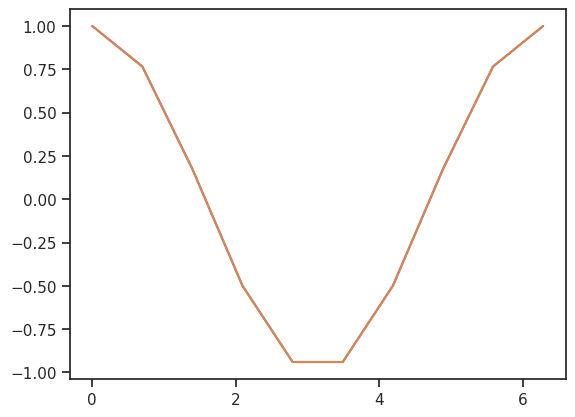

<string>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `hi

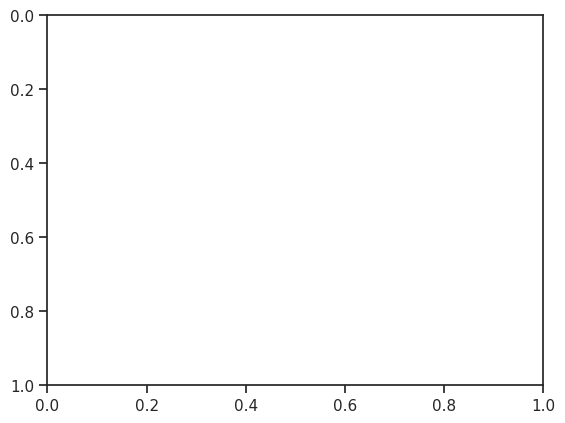

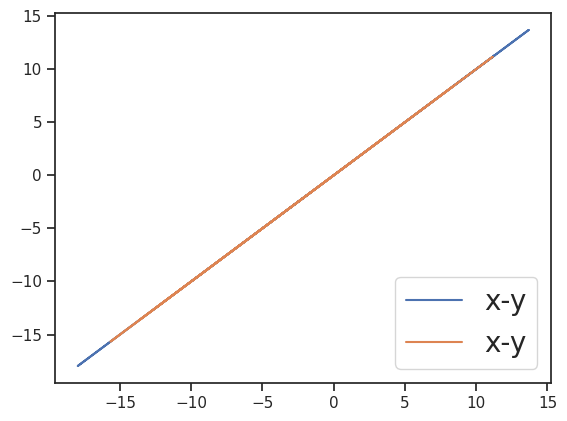

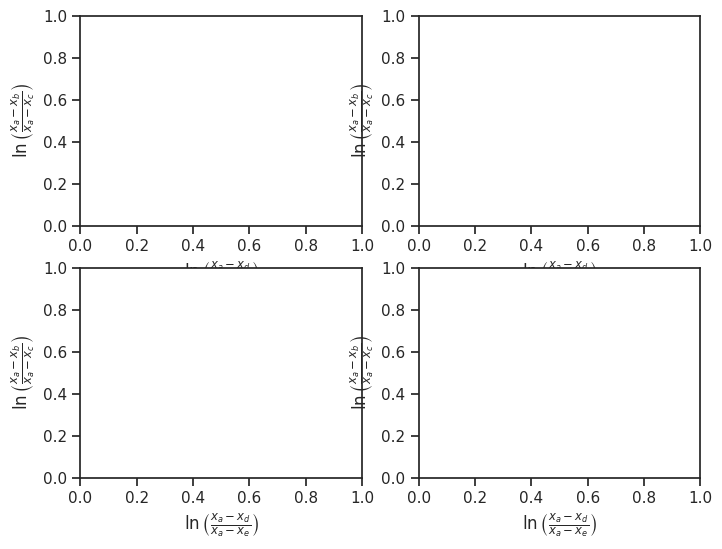

<Figure size 640x480 with 0 Axes>

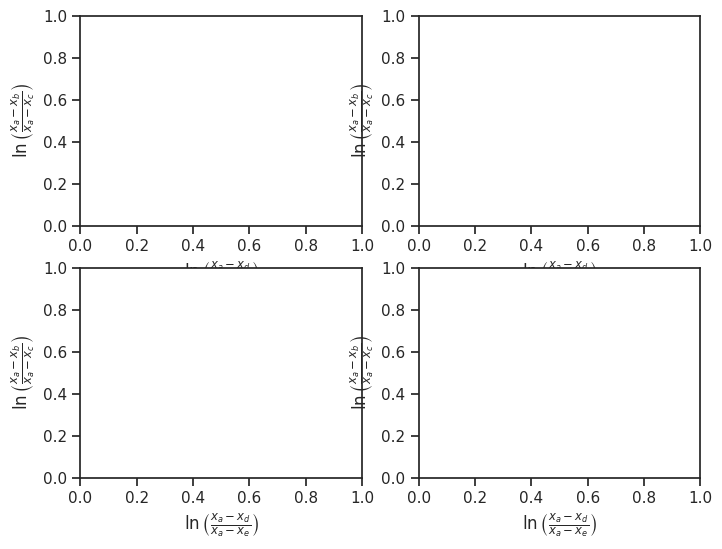

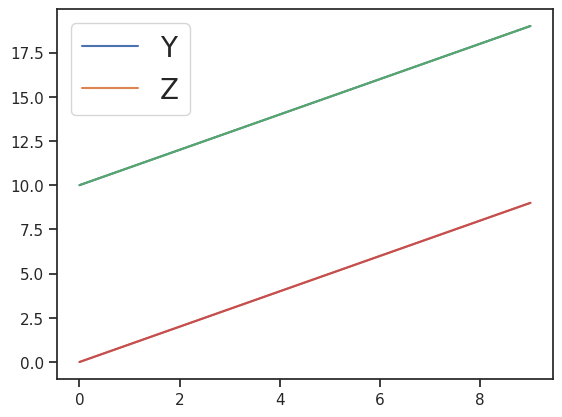

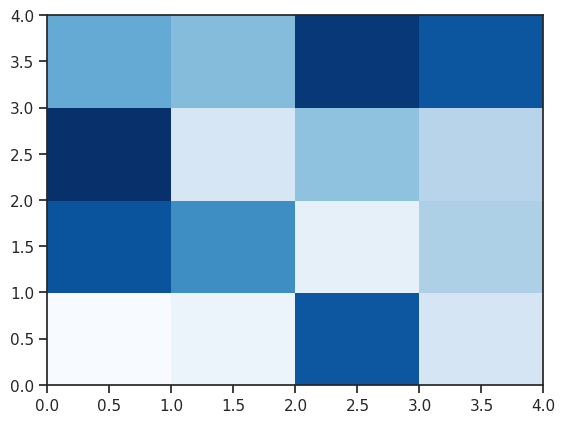

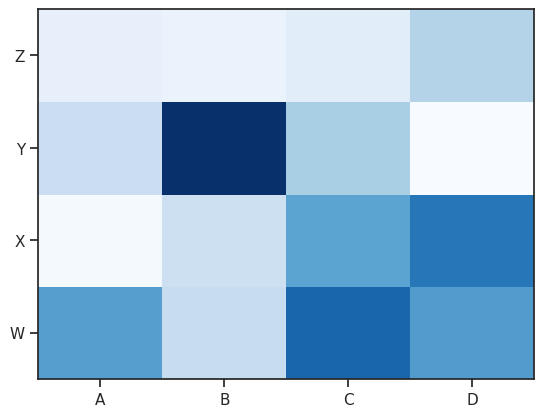

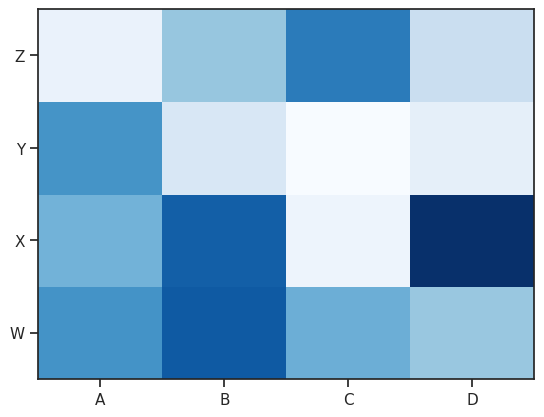

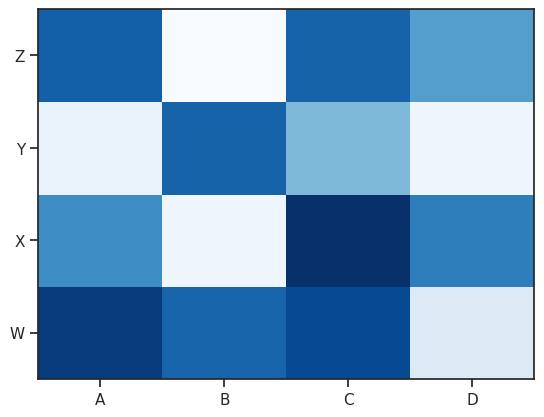

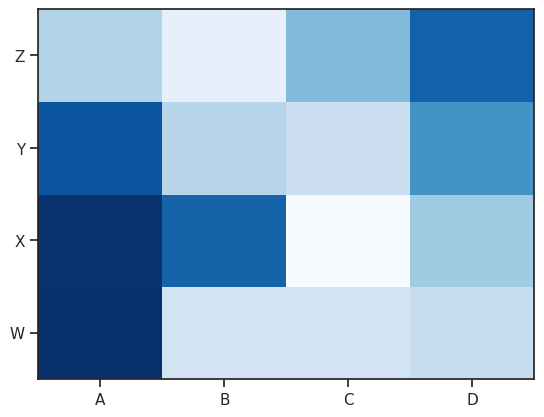

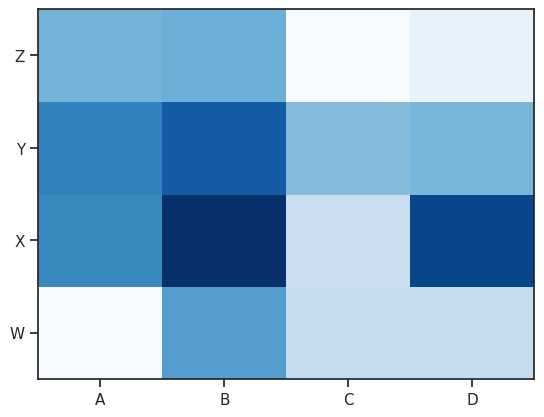

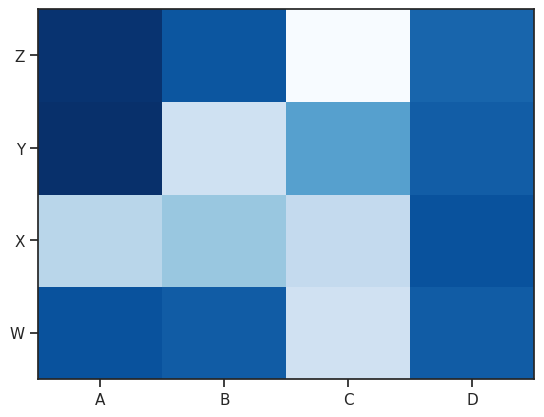

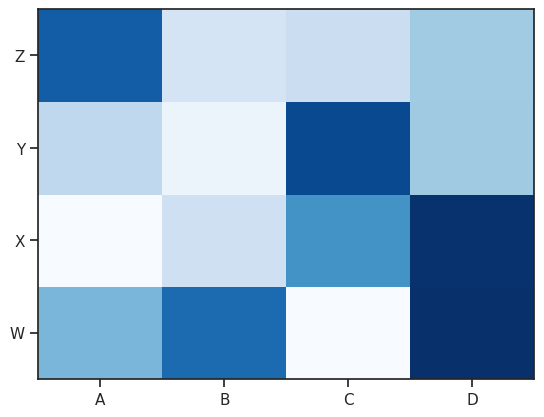

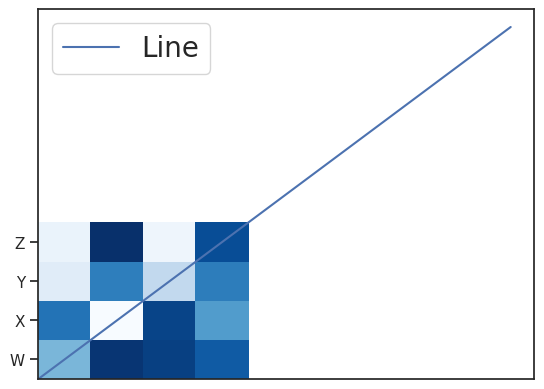

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1696: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(figsize=(height, height))
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1696: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(figsize=(height, height))


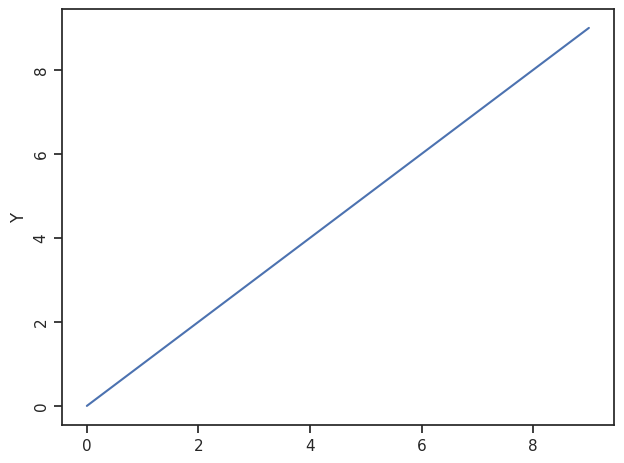

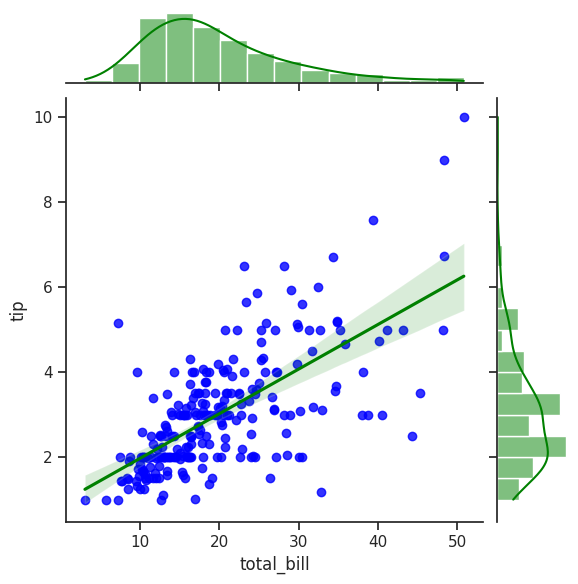

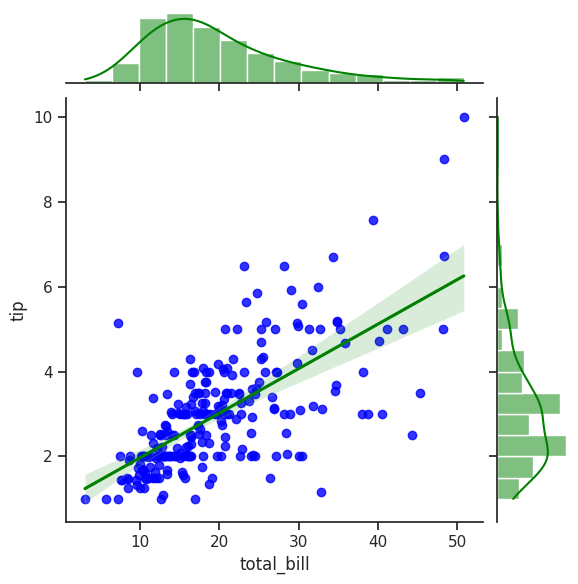

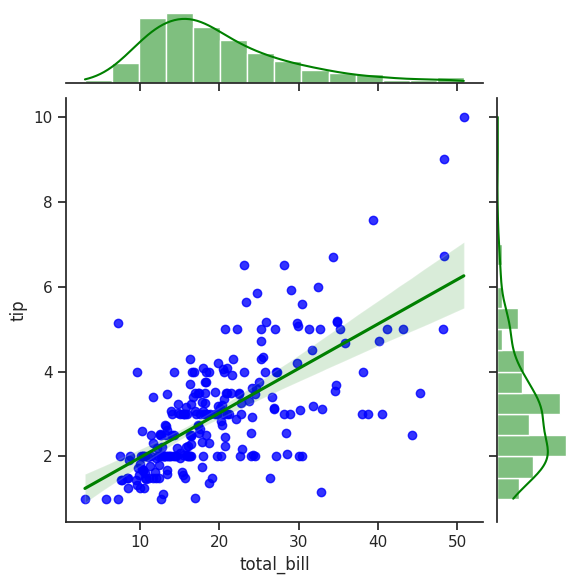

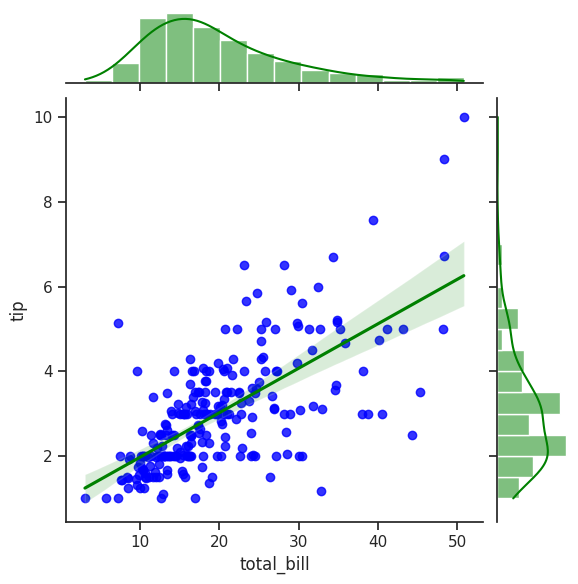

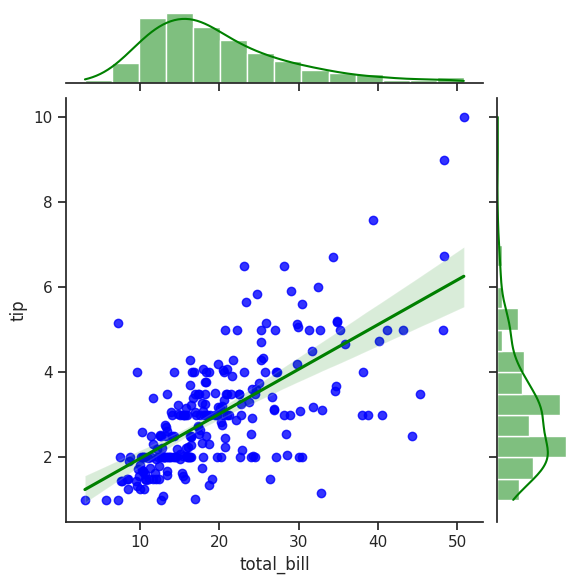

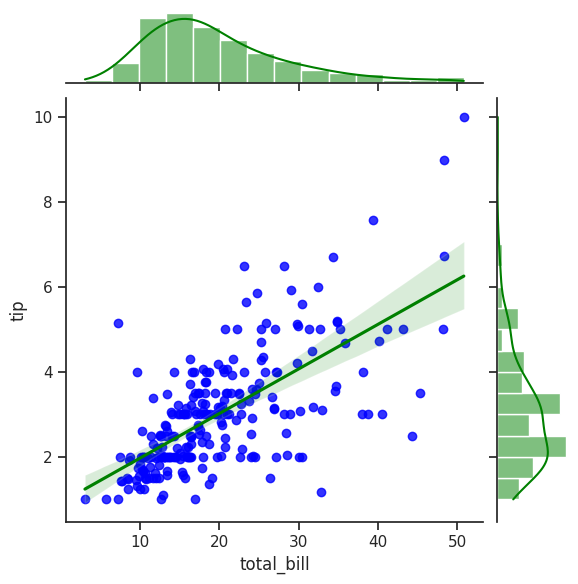

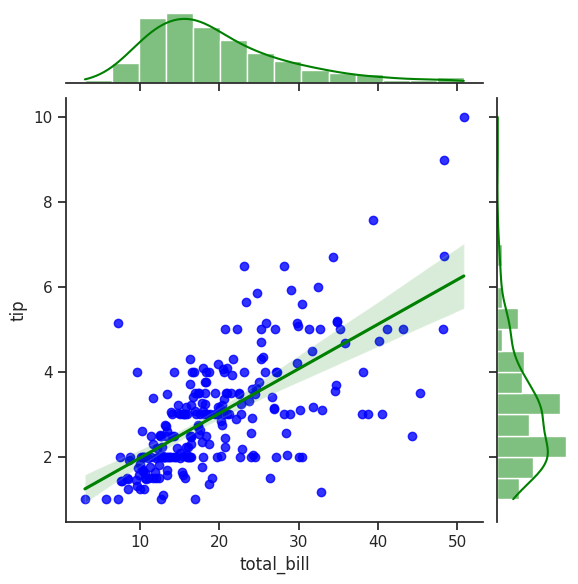

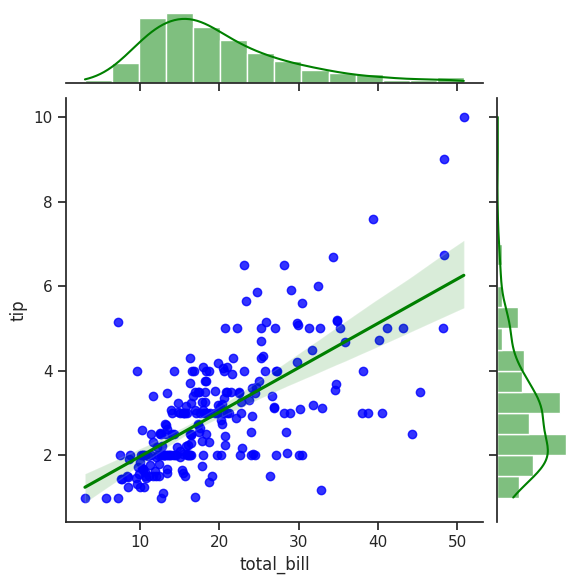

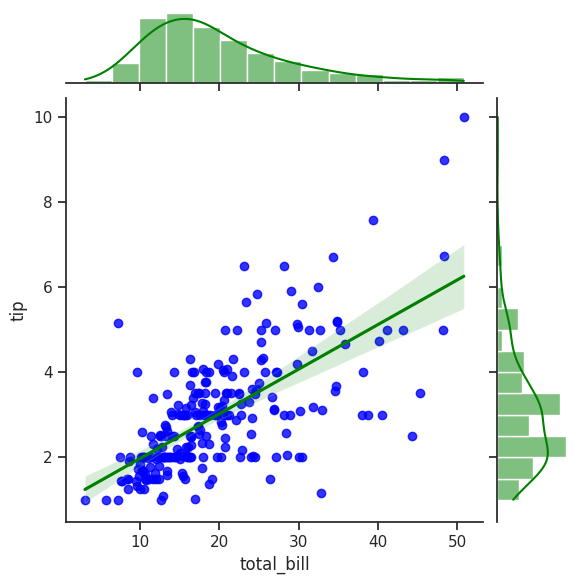

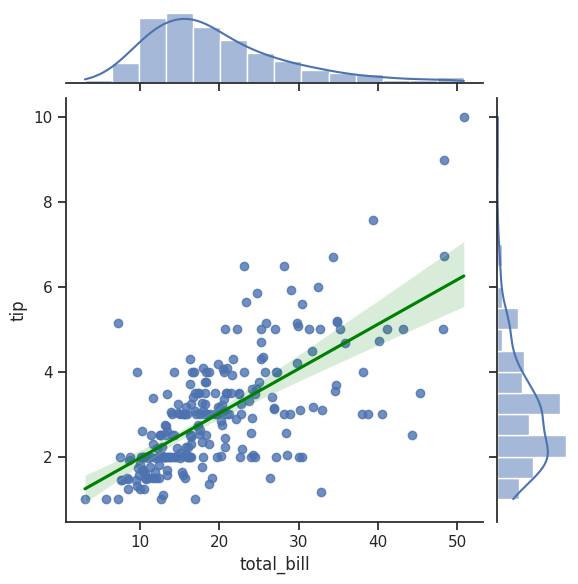

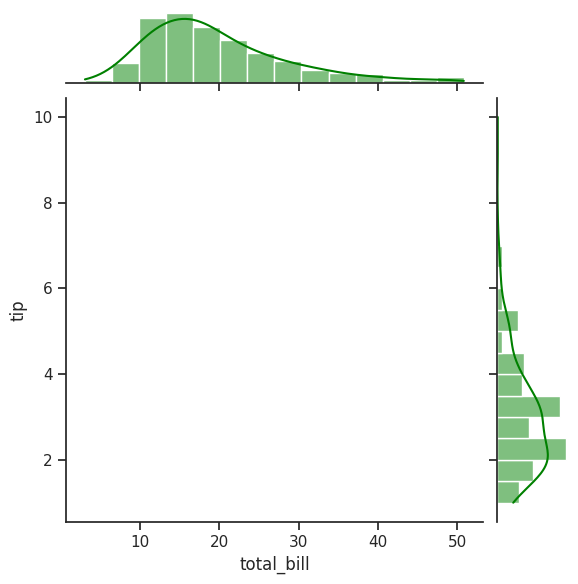

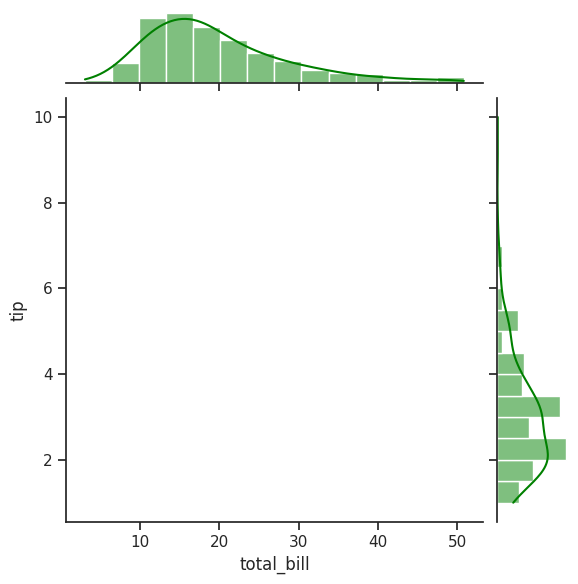

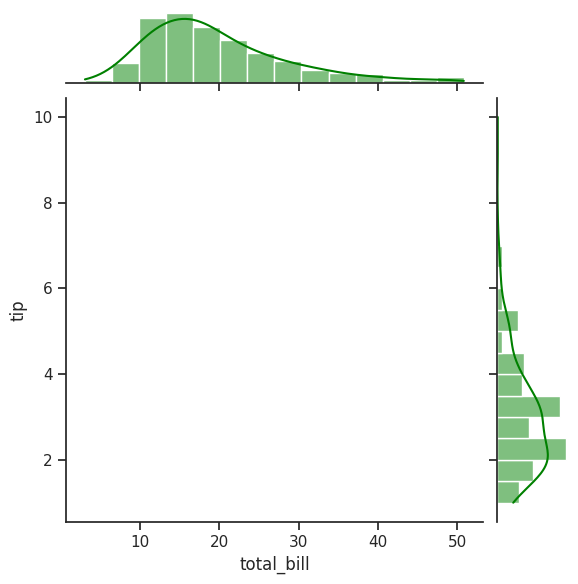

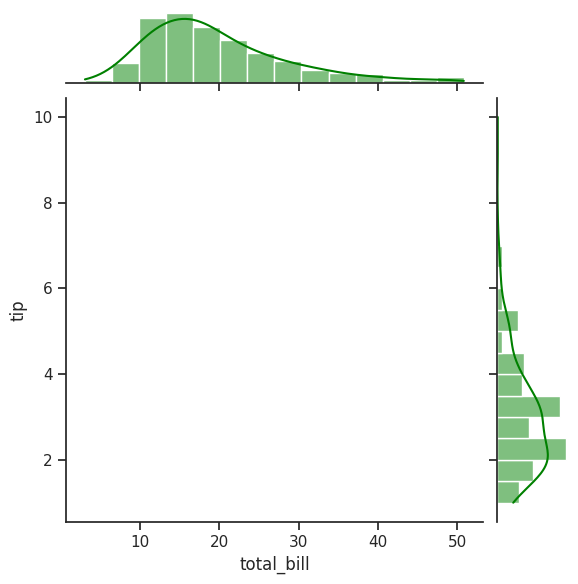

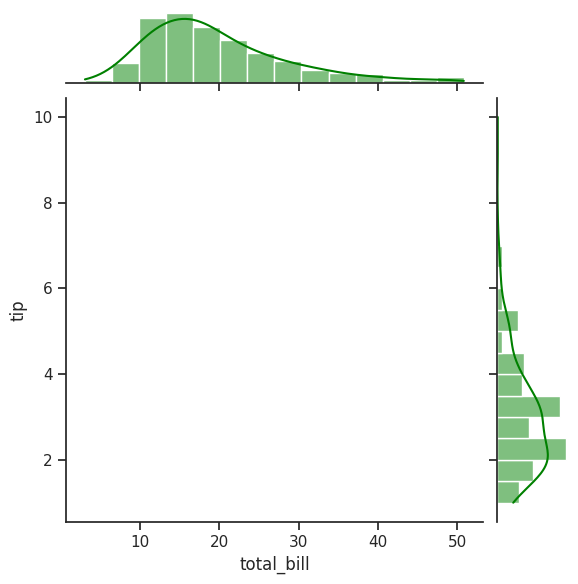

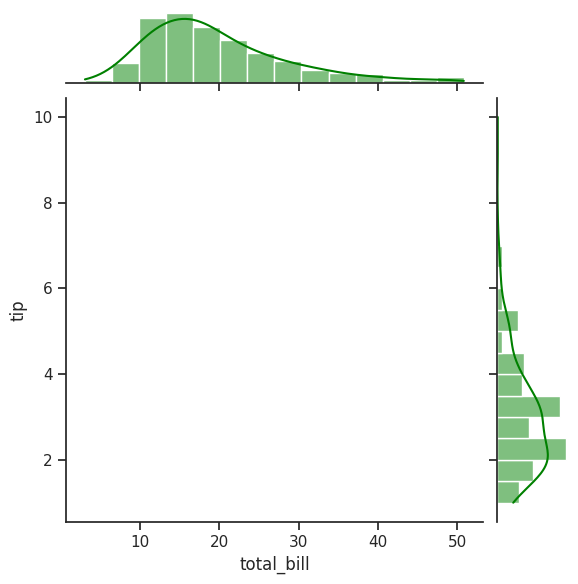

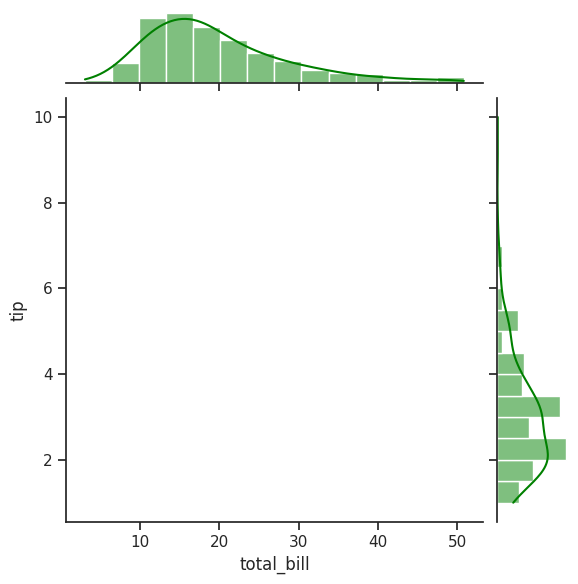

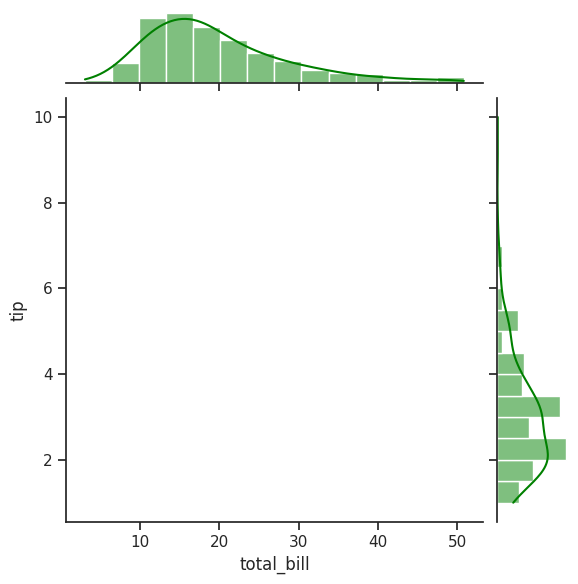

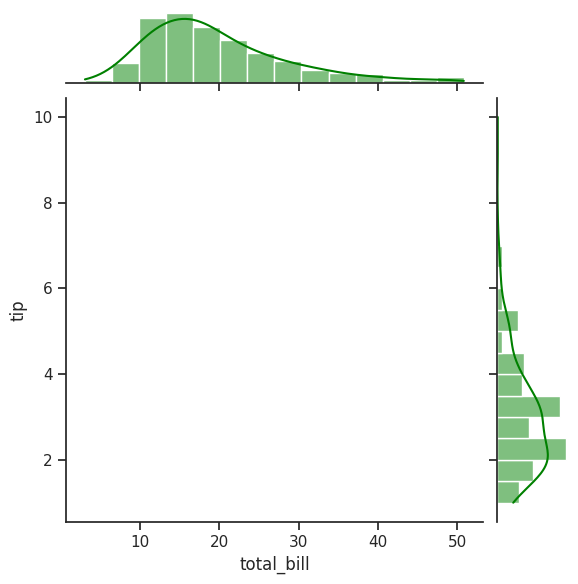

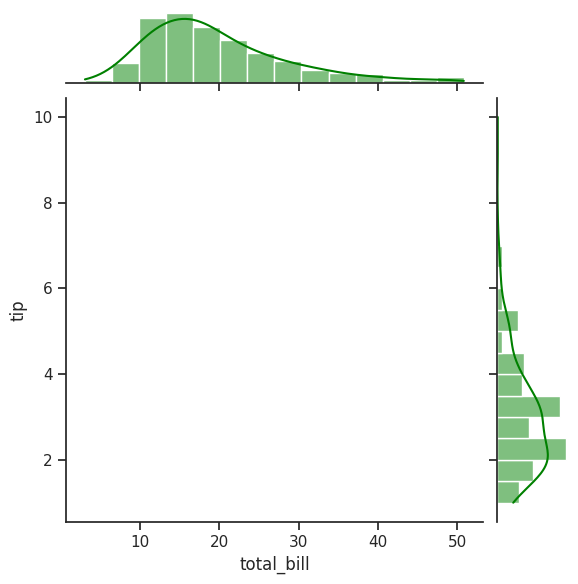

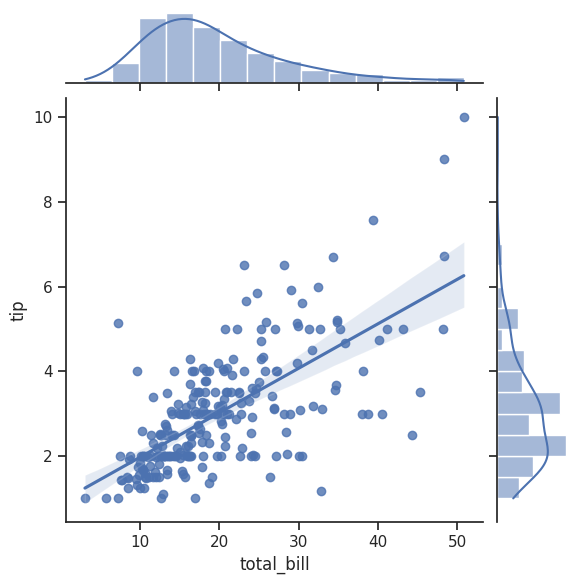

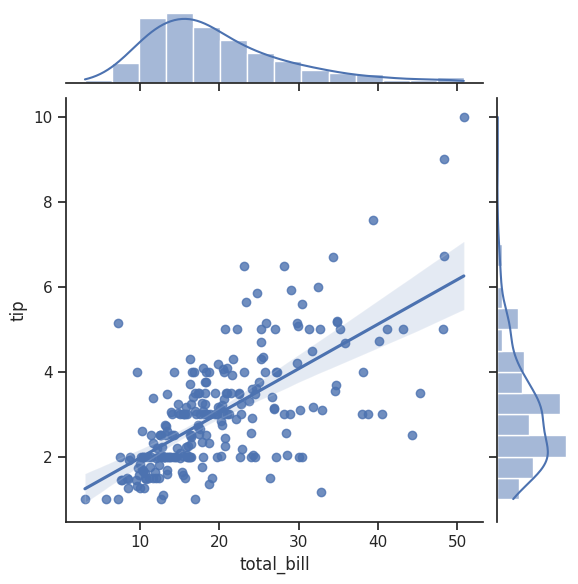

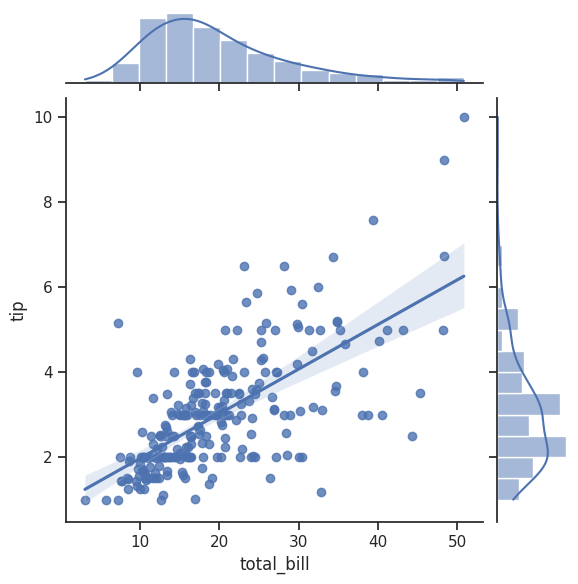

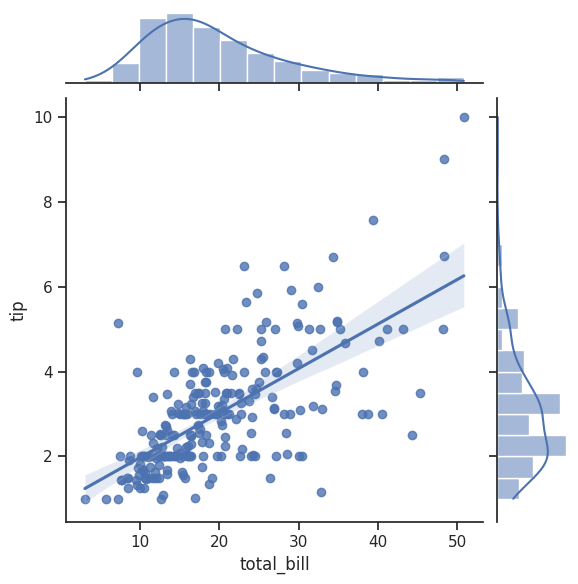

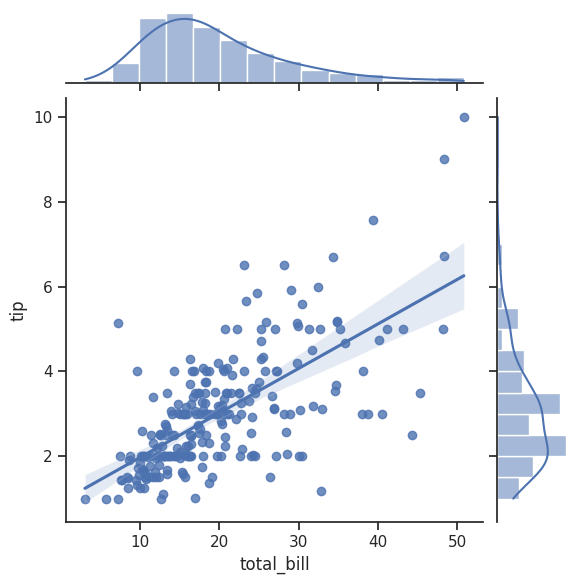

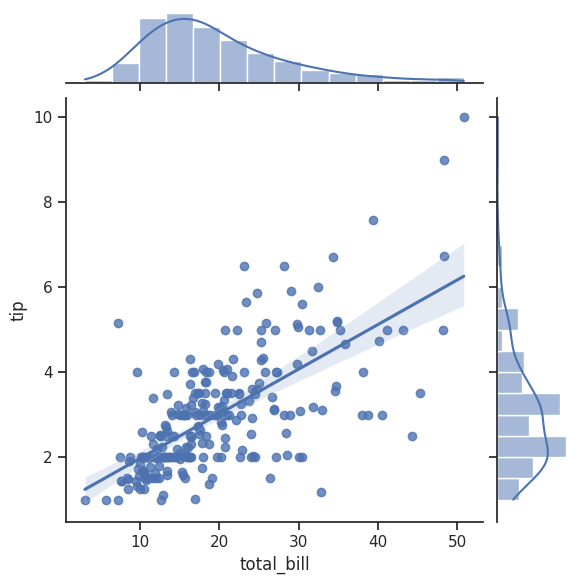

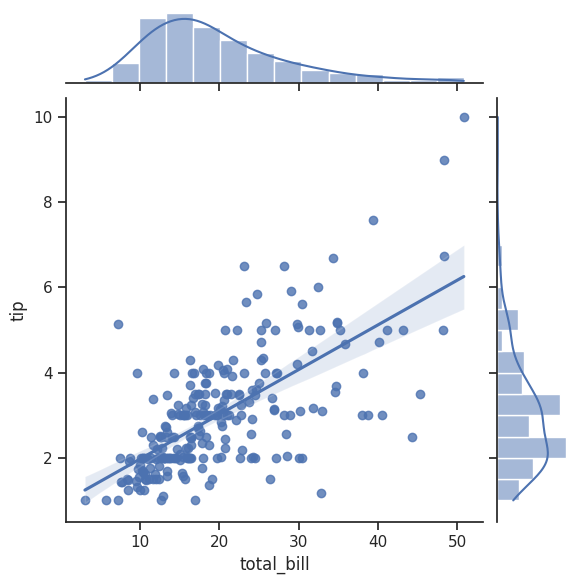

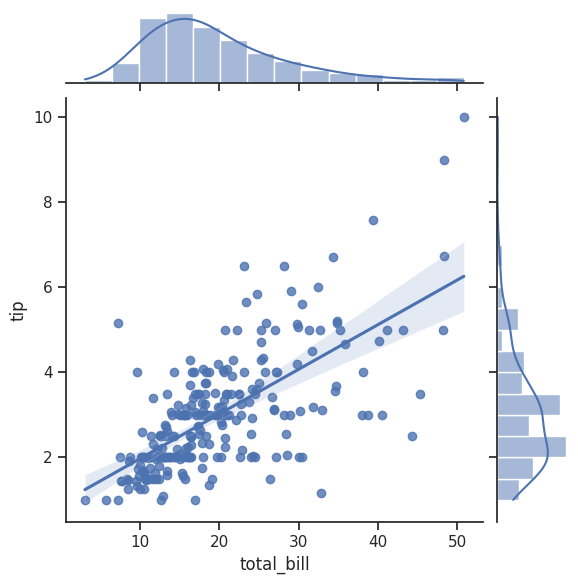

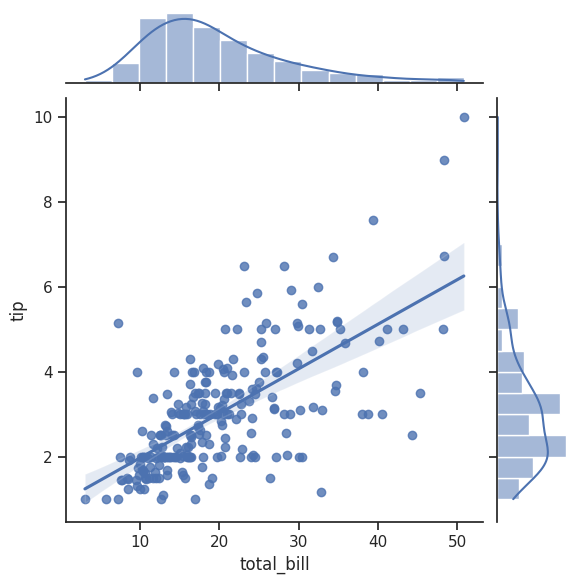

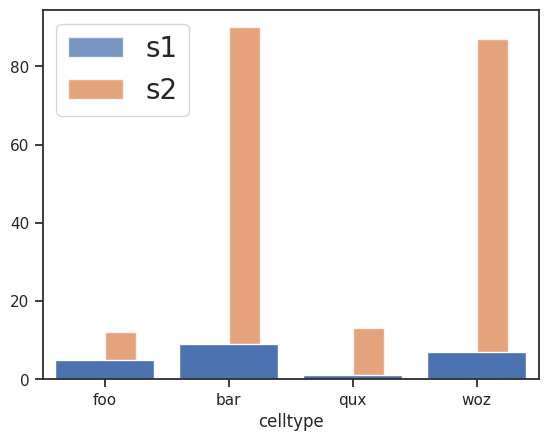

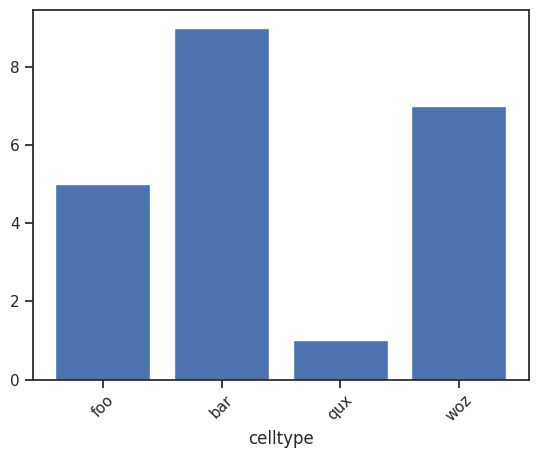

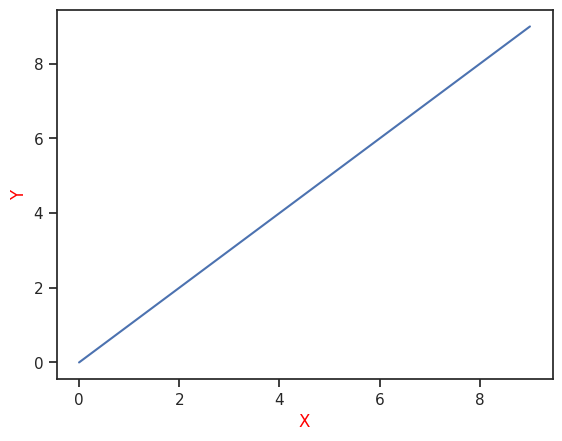

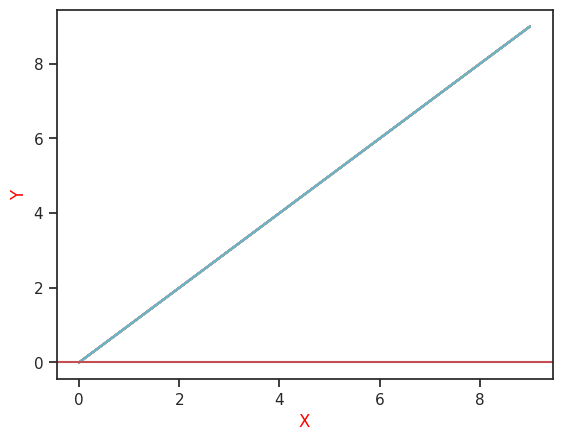

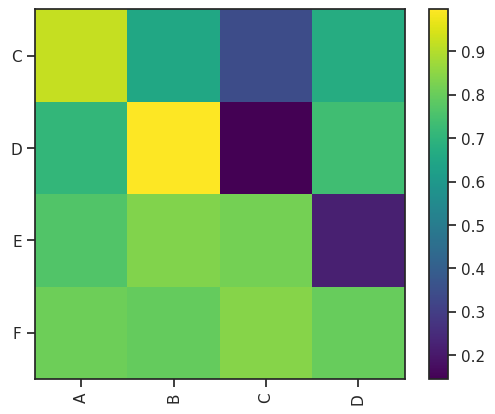

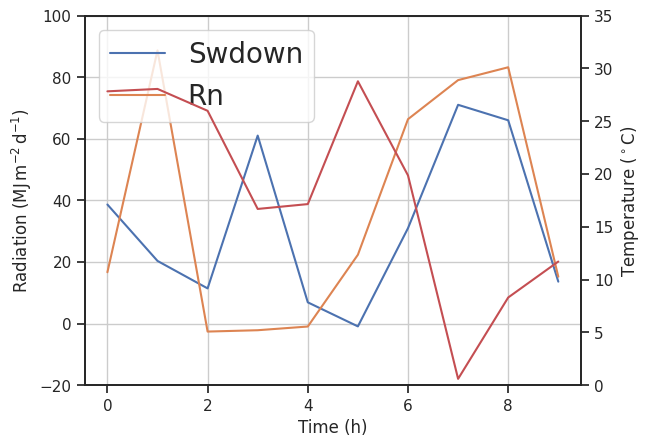

<Figure size 640x480 with 0 Axes>

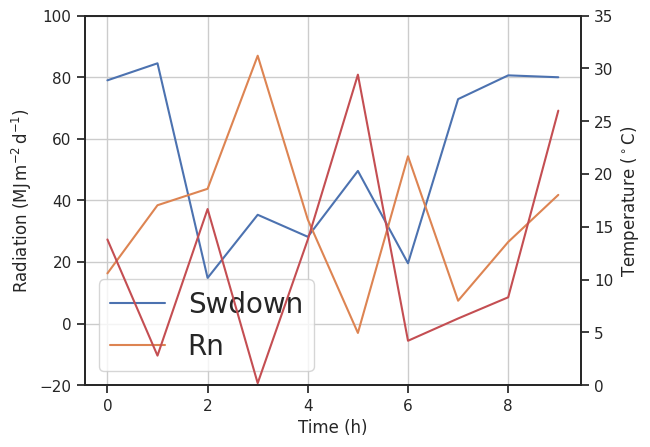

<Figure size 640x480 with 0 Axes>

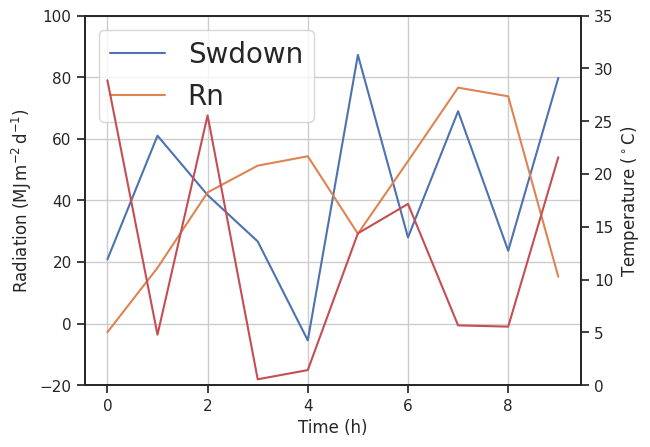

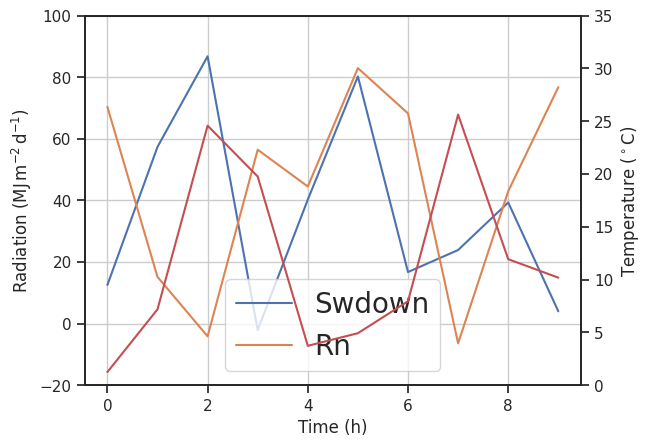

<Figure size 640x480 with 0 Axes>

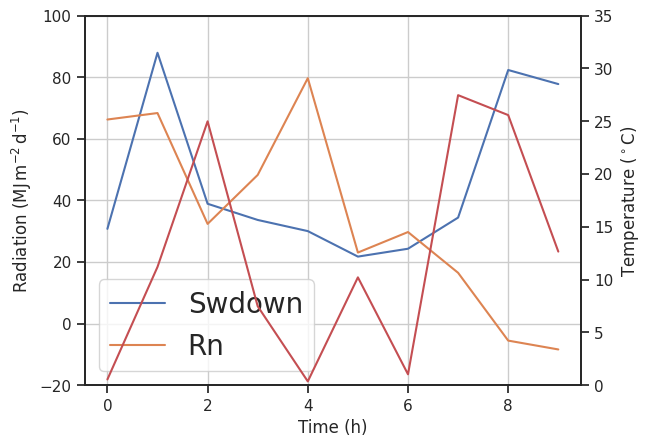

<Figure size 640x480 with 0 Axes>

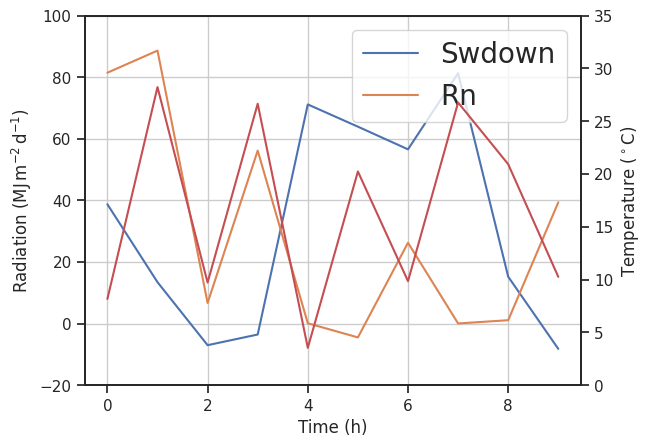

<Figure size 640x480 with 0 Axes>

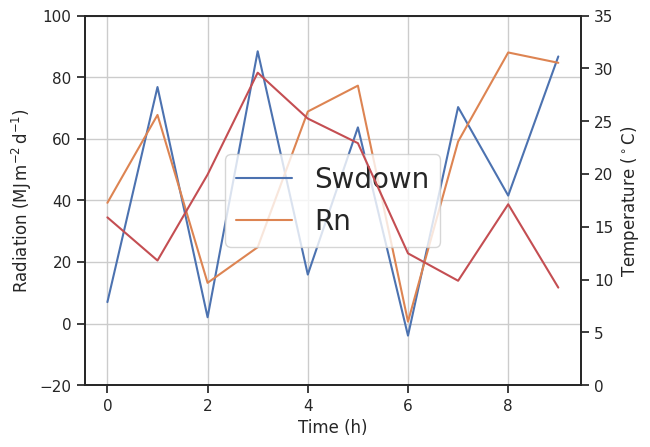

<Figure size 640x480 with 0 Axes>

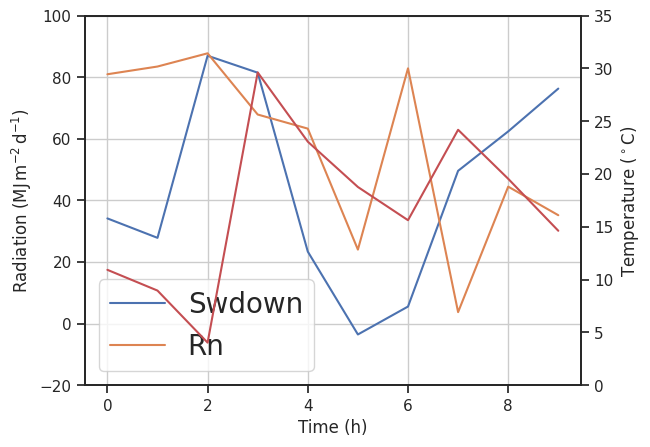

<Figure size 640x480 with 0 Axes>

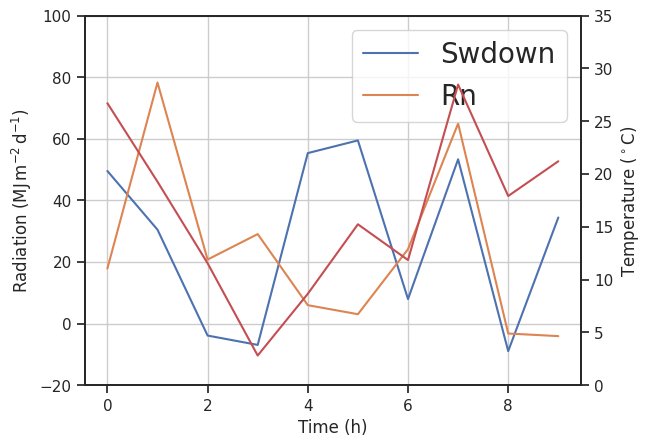

<Figure size 640x480 with 0 Axes>

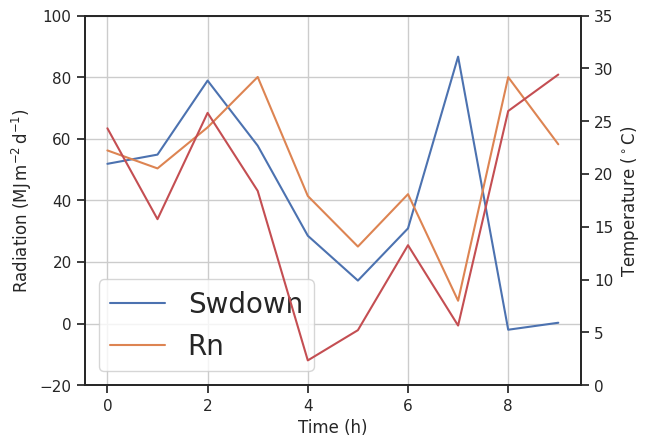

<Figure size 640x480 with 0 Axes>

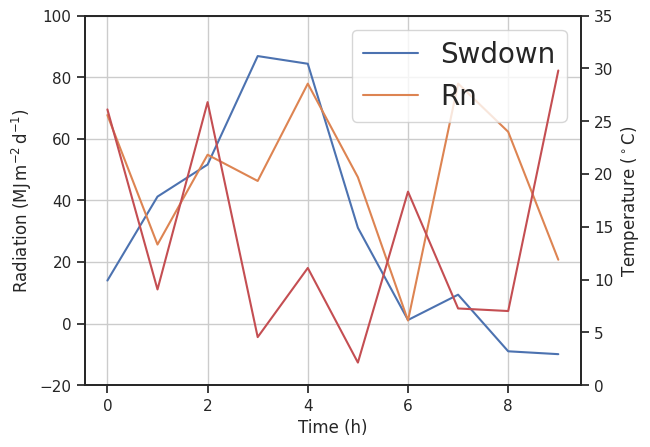

<Figure size 640x480 with 0 Axes>

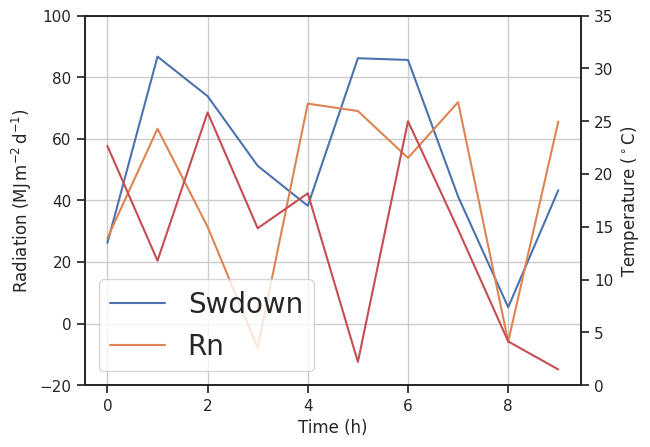

<Figure size 640x480 with 0 Axes>

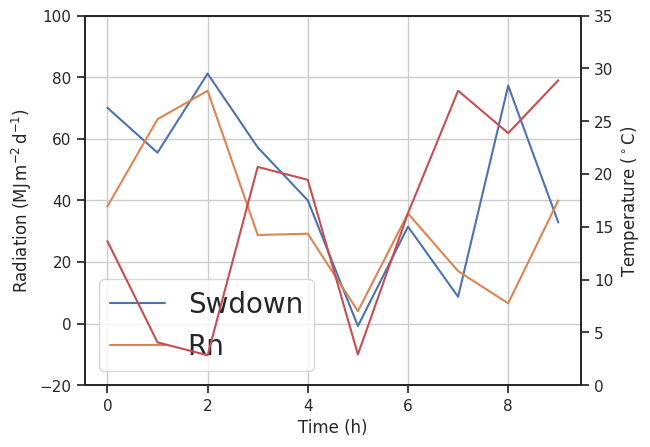

<Figure size 640x480 with 0 Axes>

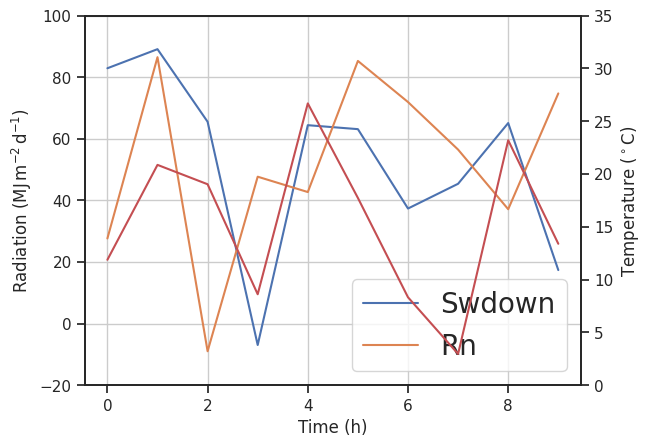

<Figure size 640x480 with 0 Axes>

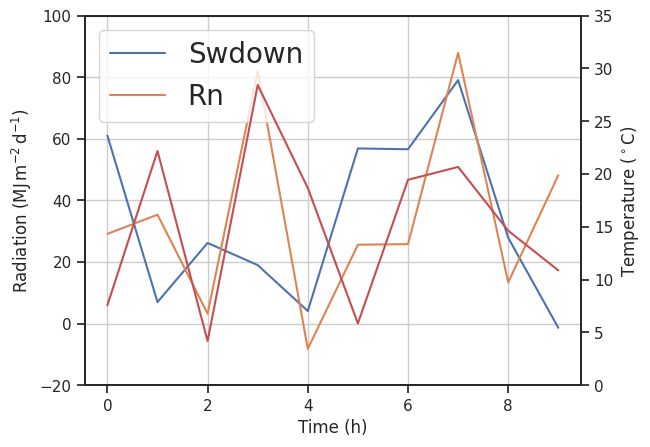

<Figure size 640x480 with 0 Axes>

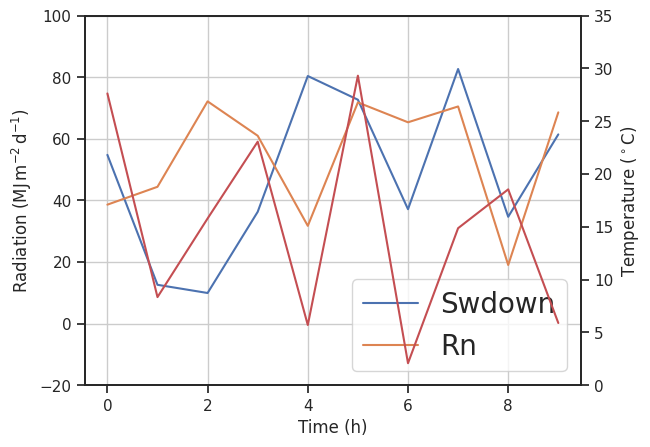

<Figure size 640x480 with 0 Axes>

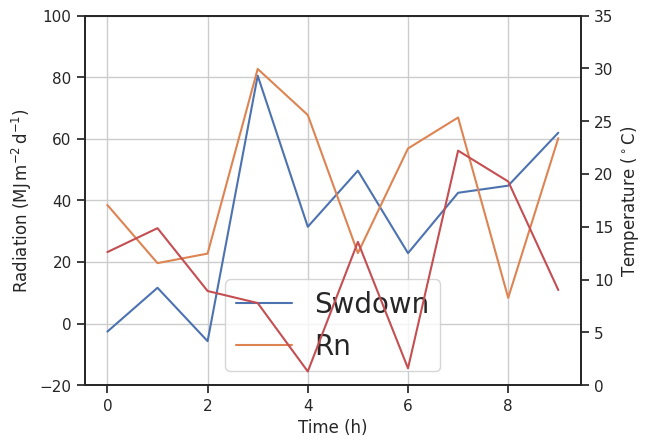

<Figure size 640x480 with 0 Axes>

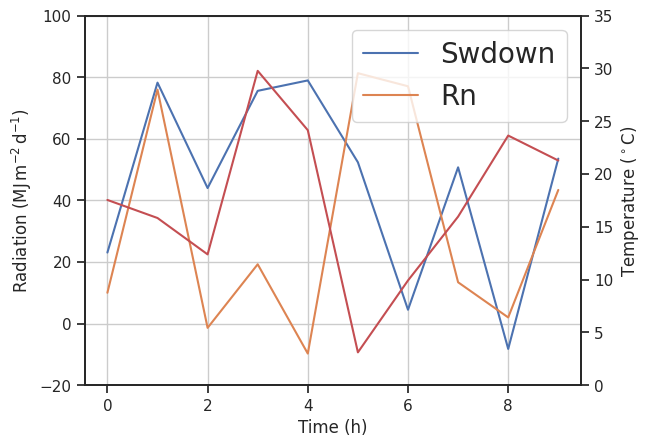

<Figure size 640x480 with 0 Axes>

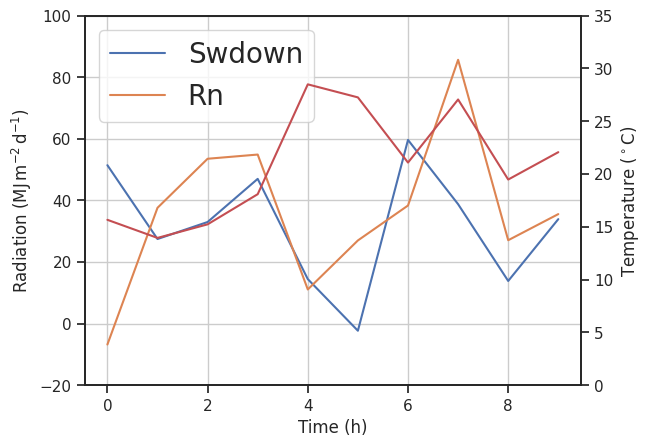

<Figure size 640x480 with 0 Axes>

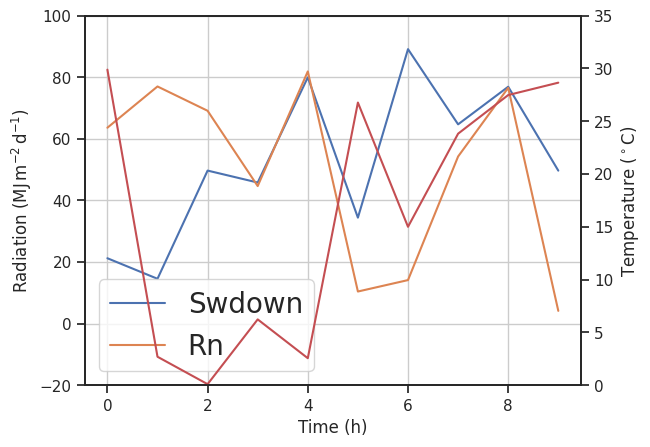

<Figure size 640x480 with 0 Axes>

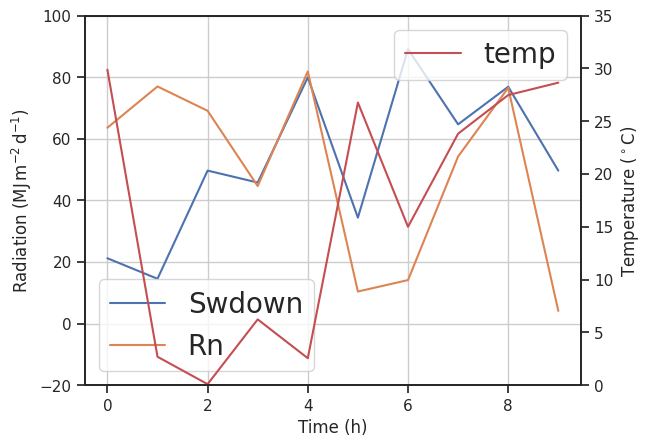

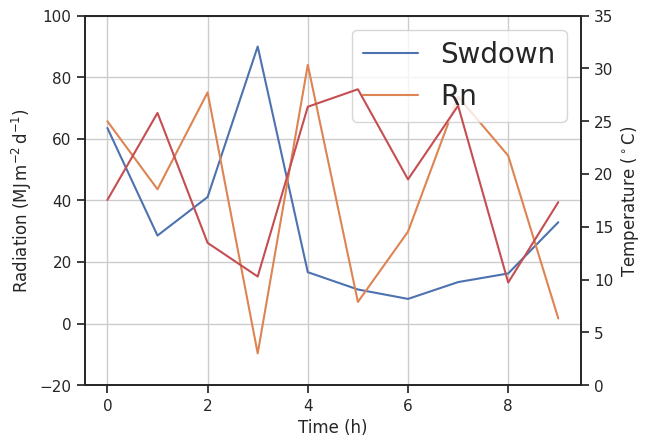

<string>:42: SyntaxWarning: invalid escape sequence '\m'
<string>:47: SyntaxWarning: invalid escape sequence '\m'
<string>:42: SyntaxWarning: invalid escape sequence '\m'
<string>:47: SyntaxWarning: invalid escape sequence '\m'


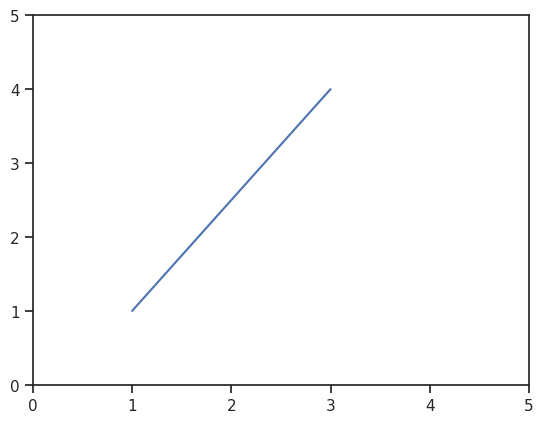

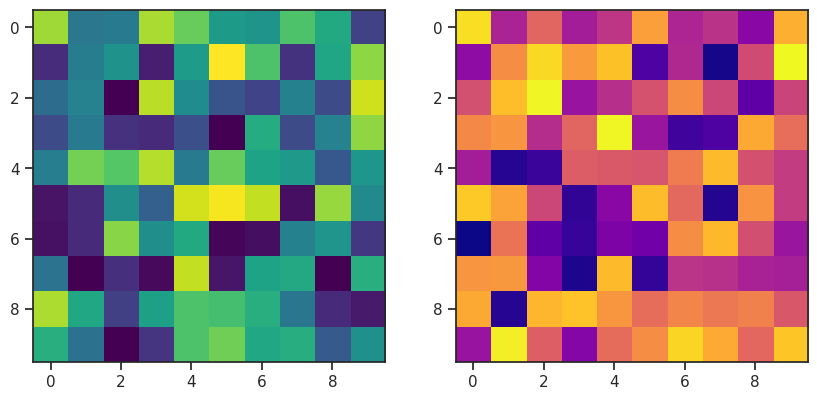

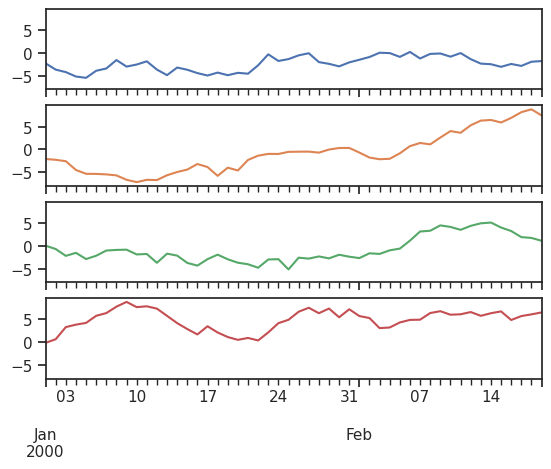

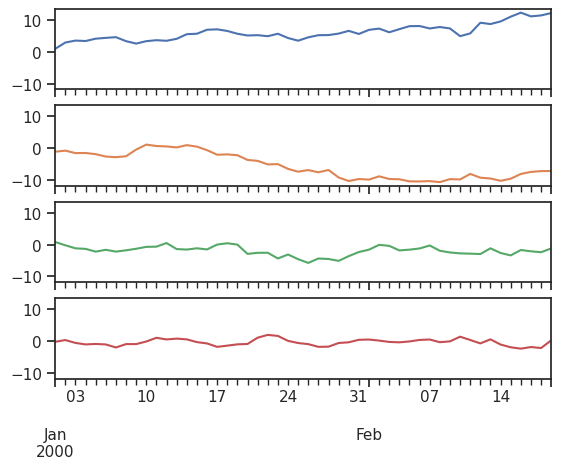

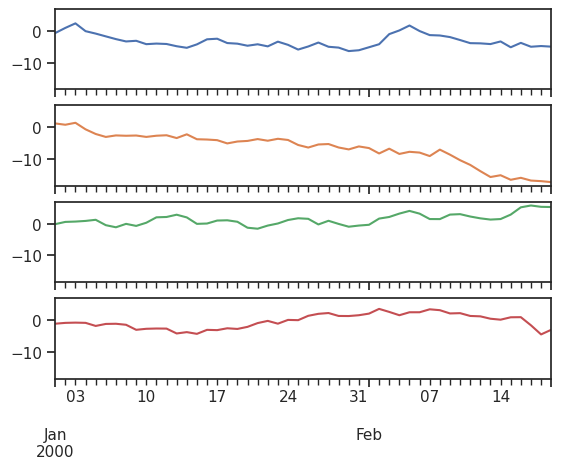

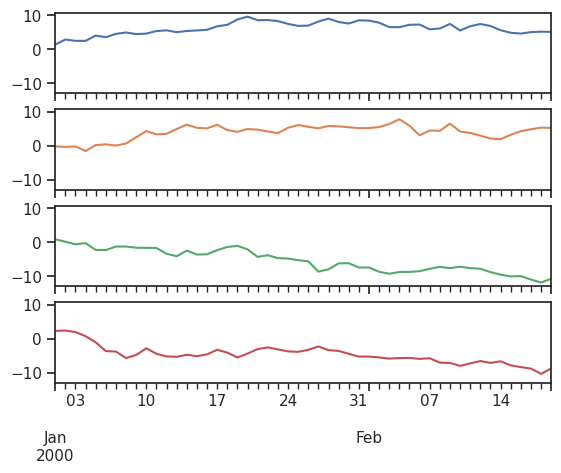

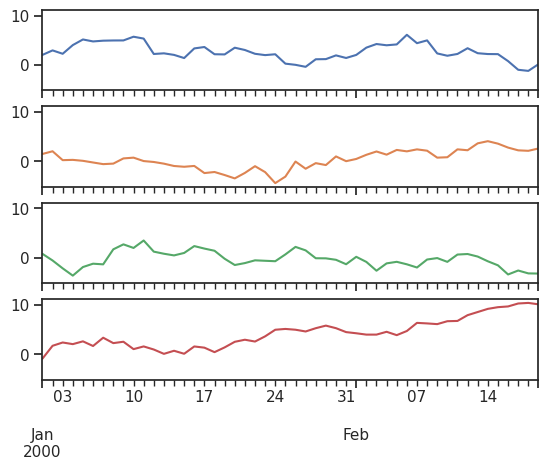

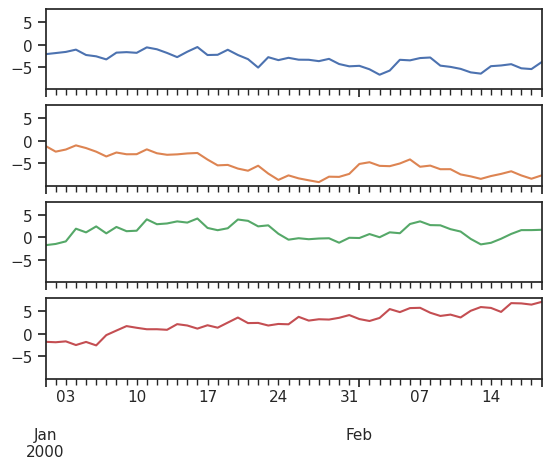

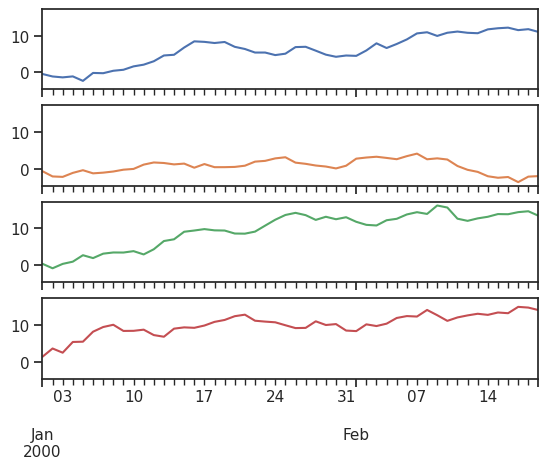

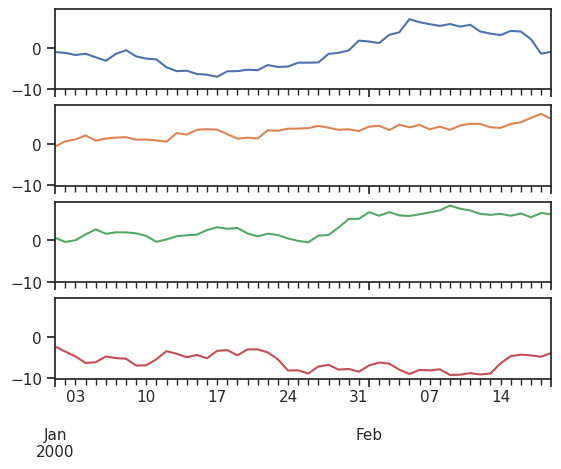

[ds1000] Processed 600/1000


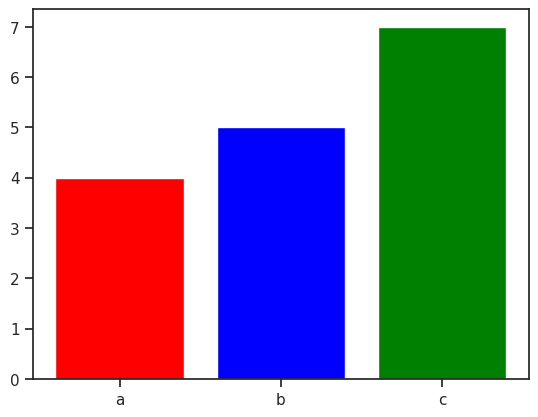

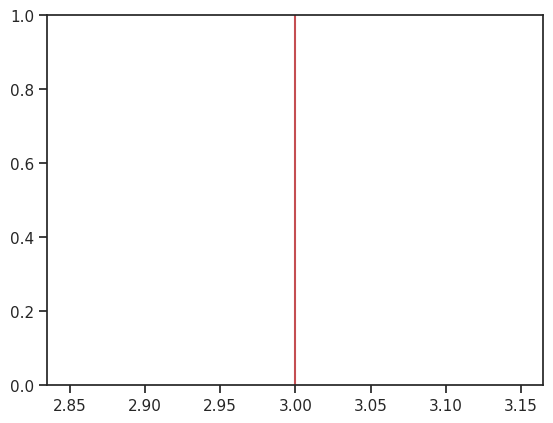

<string>:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `hi

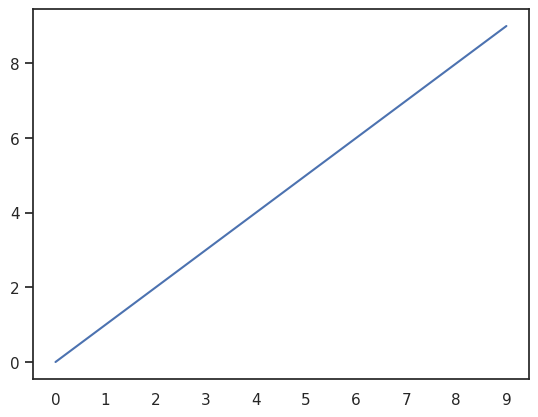

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

[ds1000] Processed 700/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
<string>:21: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:17: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:17: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:21: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
<string>:5: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
<string>:23: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod(

[ds1000] Processed 800/1000


<string>:23: SyntaxWarning: invalid escape sequence '\s'
<string>:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
<string>:23: SyntaxWarning: invalid escape sequence '\s'
<string>:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

[ds1000] Processed 900/1000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
<string>:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
<string>:61: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.

Saved → ds1000_pipeline_output.csv

Loading HUMANEVAL...
HUMANEVAL Columns: Index(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point',
       'GENERATED_CODE', 'STATUS'],
      dtype='object')
Running pipeline for HUMANEVAL...
[humaneval] Processed 0/164
['()', '(())', '(()())']
(0, 1)
(10, 24)
1
5
3
4
[4, 2, 1, 2, 2, 1, 1, 1, 1, 4, 4]
0
3
3
one three five
[2, 5, 6]
[5, 3, 2, 3, 9, 123, 1]
[1, 2, 3]
[2, 6, 3, 4, 8, 9, 5]
0
2
3
[1, 2, 3]
[3, 6, 5, 4]
2
3
5
13
89
[2, 3, 4]
[6, 4, 6, 3, 4, 4, 10, 1, 124]
False
False
False
True
False
22
1000
111
4
8
14
All test cases passed!
['Hi', 'my', 'name', 'is', 'John']
['One', 'two', 'three', 'four', 'five', 'six']
14
12
14
12
0b11
-1
0b1111
0b11010
[1, 15, 33]
[]
['Eight', 'Five', 'Four', 'Three', 'Two', 'Two', 'One', 'One']
[]
['One']
[1, 2, 6, 24, 15]
(1, 2)
(4, 6)
0
3
3
0
3
3
True
True
True
True
YES
NO
('bcd', False)
('acdef', False)
('cdedc', True)
['the number of odd elements 4n the str4ng 4 of the 4nput.']
['the number of odd el

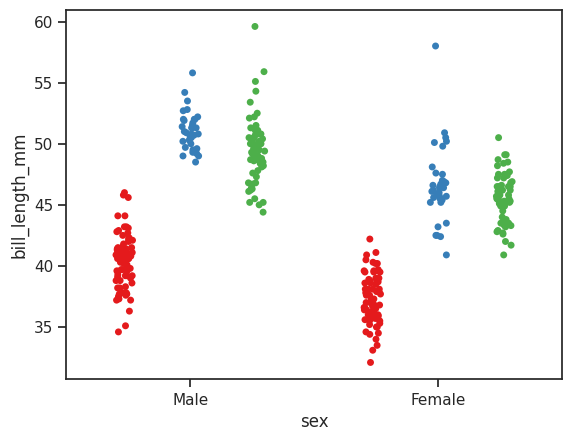

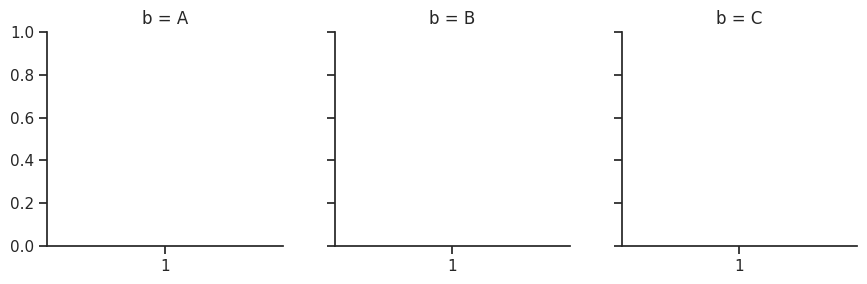

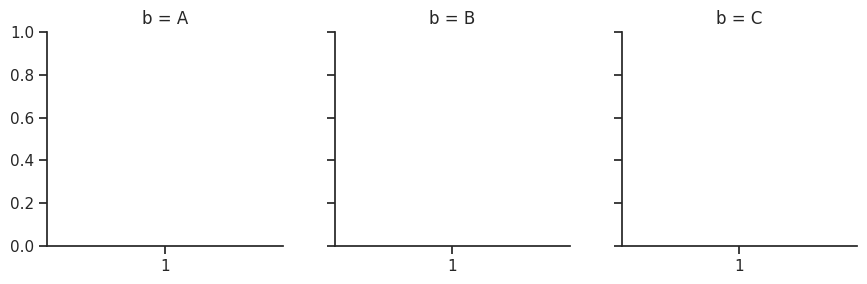

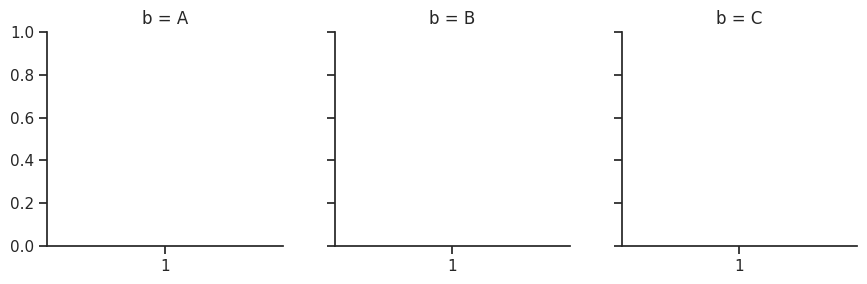

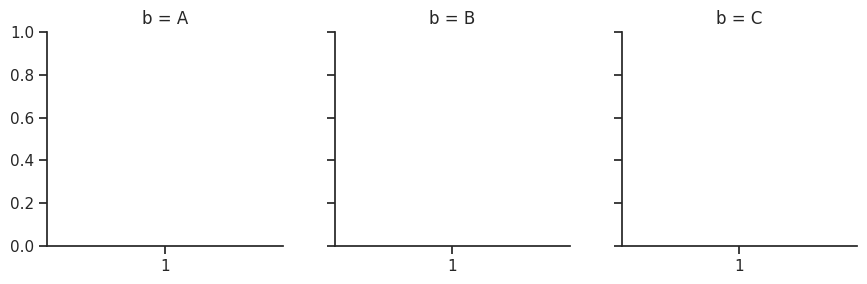

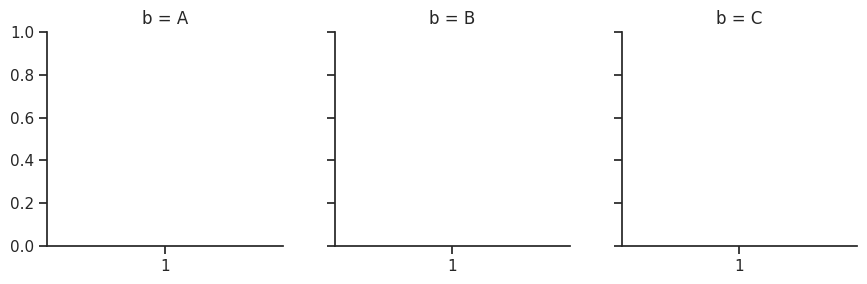

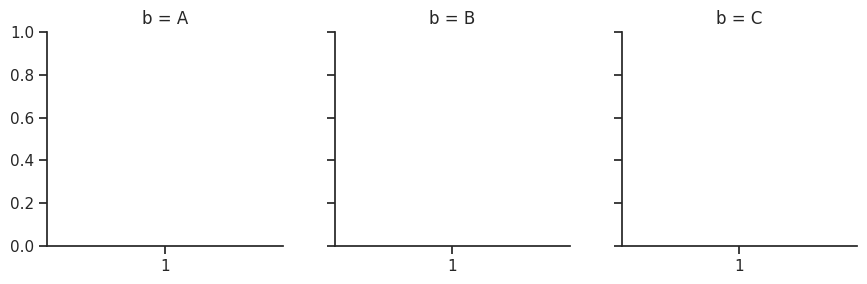

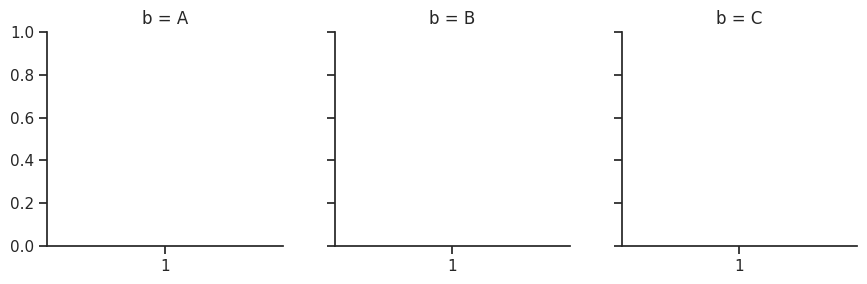

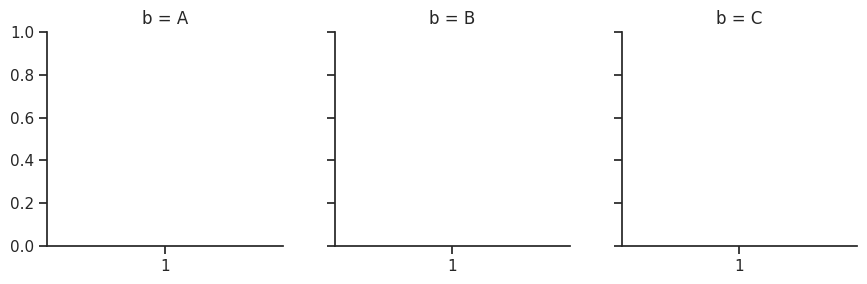

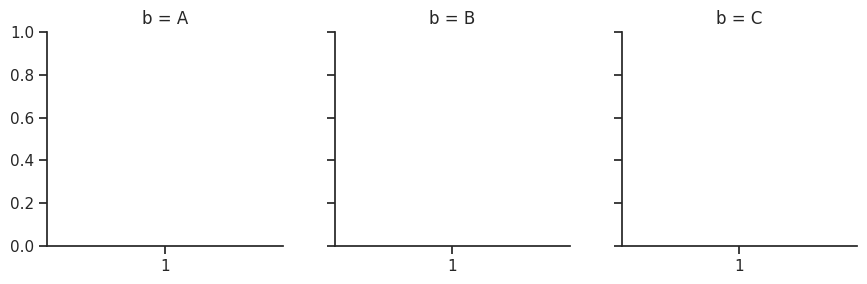

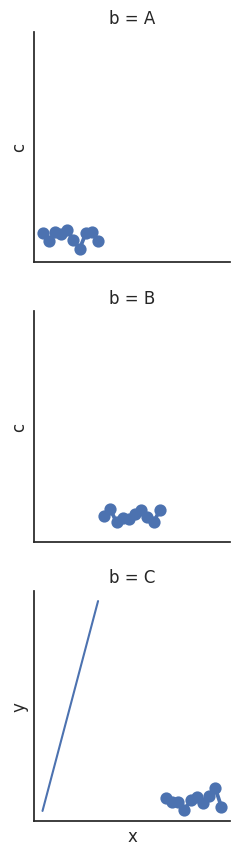

<Figure size 300x300 with 0 Axes>

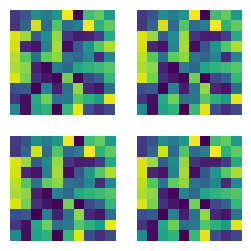

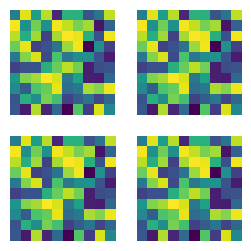

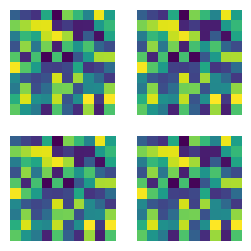

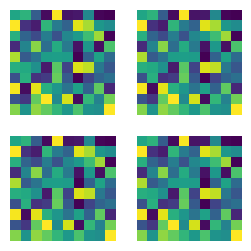

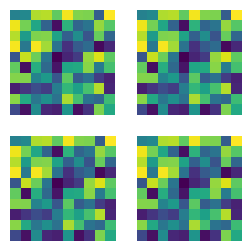

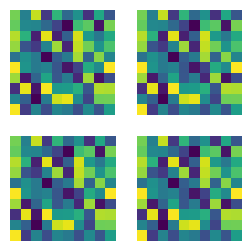

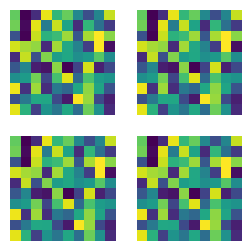

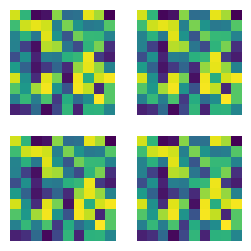

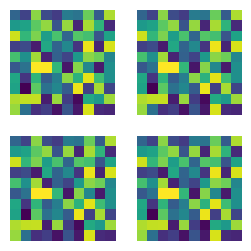

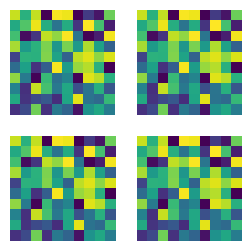

In [29]:
import pandas as pd

if __name__ == "__main__":

    DATASETS = {
        "ds1000": "ds1k_gen.csv",
        "humaneval": "humaneval_gen.csv",
        "mbpp": "mbpp_gen.csv"
    }

    for dataset_name, file_path in DATASETS.items():

        print(f"\nLoading {dataset_name.upper()}...")
        df = pd.read_csv(file_path)

        print(f"{dataset_name.upper()} Columns:", df.columns)

        print(f"Running pipeline for {dataset_name.upper()}...")
        results_df = run_dataset_pipeline(df, dataset_name)

        output_file = f"{dataset_name}_pipeline_output.csv"
        results_df.to_csv(output_file, index=False)

        print(f"Saved → {output_file}")

    print("\n✅ Pipeline execution completed for all datasets.")

# NOT WORKING

## LIBRARY_API CONSTRUCTION AND ANALYSIS

In [ ]:
BUILTINS = set(dir(builtins))


def analyze_library_api_single(code: str):
    class LibraryAPIVistor(ast.NodeVisitor):
        def __init__(self):
            self.imports = {}
            self.errors = []

        def visit_Import(self, node):
            for alias in node.names:
                name = alias.asname or alias.name.split(".")[0]
                try:
                    self.imports[name] = importlib.import_module(alias.name)
                except Exception:
                    self.errors.append({
                        "type": "module_not_found",
                        "module": alias.name,
                        "line": node.lineno
                    })

        def visit_ImportFrom(self, node):
            if node.module is None:
                return

            try:
                module = importlib.import_module(node.module)
                for alias in node.names:
                    name = alias.asname or alias.name
                    if hasattr(module, alias.name):
                        self.imports[name] = getattr(module, alias.name)
                    else:
                        self.errors.append({
                            "type": "name_error",
                            "name": alias.name,
                            "line": node.lineno
                        })
            except Exception:
                self.errors.append({
                    "type": "module_not_found",
                    "module": node.module,
                    "line": node.lineno
                })

        # ---------------- attribute access ----------------
        def visit_Attribute(self, node):
            if isinstance(node.value, ast.Name): #kind of typeof(0)
                base = node.value.id
                attr = node.attr

                if base in self.imports:
                    obj = self.imports[base]
                    if not hasattr(obj, attr):
                        self.errors.append({
                            "type": "attribute_error",
                            "object": base,
                            "attribute": attr,
                            "line": node.lineno
                        })

            self.generic_visit(node)

        # ---------------- for function calls ----------------
        def visit_Call(self, node):
            if isinstance(node.func, ast.Attribute):
                if isinstance(node.func.value, ast.Name):
                    base = node.func.value.id
                    func_name = node.func.attr

                    if base in self.imports:
                        obj = self.imports[base]
                        if hasattr(obj, func_name):
                            try:
                                sig = inspect.signature(getattr(obj, func_name))
                                for kw in node.keywords:
                                    if kw.arg not in sig.parameters:
                                        self.errors.append({
                                            "type": "type_error",
                                            "function": func_name,
                                            "invalid_arg": kw.arg,
                                            "line": node.lineno
                                        })
                            except Exception:
                                pass

            self.generic_visit(node)

    result = {
        "type": None,
        "value": 0,
        "libapi_details": []
    }

    try:
        tree = ast.parse(code)
        visitor = LibraryAPIVistor()
        visitor.visit(tree)

        if visitor.errors:
            result["type"] = "LibraryAPIError"
            result["value"] = len(visitor.errors)
            result["libapi_details"] = visitor.errors

    except Exception as e:
        result["type"] = "ParsingError"
        result["value"] = 1 #this is so wrong!
        result["libapi_details"] = [{"type": "parse_failure", "message": str(e)}]

    return result

## DYNAMIC ANALYSIS MODULE

In [ ]:
# OUTPUT_CSV = "dynamic_execution_results.csv"
TIMEOUT_SECONDS = 10


class TimeoutException(Exception):
    pass


def timeout_handler(signum, frame):
    raise TimeoutException("Execution exceeded timeout")


def extract_syntax_error_line(error_message: str) -> str:

    match = re.search(r'\(<string>,\s*line\s+(\d+)\)', error_message)
    if match:
        return match.group(1)
    return ""

#objects are stores as hasesh which can't be used thus we serialize this!
def serialize_value(value: Any, max_length: int = 500) -> str:
    try:
        if isinstance(value, pd.DataFrame):
            try:
                serialized = value.to_dict('list')
                result = f"DataFrame({serialized})"
            except:
                result = f"DataFrame:\n{value.to_string()}"
        elif isinstance(value, pd.Series):
            try:
                serialized = value.to_dict()
                result = f"Series({serialized})"
            except:
                result = f"Series:\n{value.to_string()}"
        elif isinstance(value, np.ndarray):
            try:
                result = f"array({value.tolist()})"
            except:
                result = f"array({repr(value)})"
        elif isinstance(value, (dict, list, tuple)):
            result = str(value)
        elif value is None:
            return "None"
        else:
            try:
                if pd.isna(value):
                    return "NaN"
            except (TypeError, ValueError):
                pass
            result = str(value)

        if len(result) > max_length:
            result = result[:max_length] + "...[truncated]"

        return result
    except Exception as e:
        return f"<Serialization Error: {str(e)}>"


def extract_ds1000_test_cases(generated_code: str, code_context: str) -> List[List[str]]:

    test_cases_data = []

    try:
        # testing environment
        test_env = {}
        exec(code_context, test_env)

        if 'generate_test_case' not in test_env:
            return []

        for test_id in range(1, 10):
            try:
                test_input, expected_result = test_env['generate_test_case'](test_id)

                exec_env = {}
                exec_env['test_input'] = test_input

                try:
                    exec(generated_code, exec_env)
                    actual_result = exec_env.get('result', '<No result variable>')
                except Exception as exec_error:
                    actual_result = f"<Execution Error: {str(exec_error)}>"

                # Serialize the values from objects
                input_str = serialize_value(test_input)
                expected_str = serialize_value(expected_result)
                actual_str = serialize_value(actual_result)

                test_cases_data.append([input_str, expected_str, actual_str])

            except Exception:
                break
    except Exception as e:
        pass
    return test_cases_data


def extract_humaneval_test_cases(generated_code: str, test_code: str, entry_point: str) -> List[List[str]]:
    test_cases_data = []
    try:
        tree = ast.parse(test_code)

        test_env = {}
        exec(generated_code, test_env)

        if entry_point not in test_env:
            return []

        func = test_env[entry_point]

        #using as to find all the assert statements!
        for node in ast.walk(tree):
            if isinstance(node, ast.Assert): #ast.Assert
                try:
                    test_node = node.test

                    # Handle assert func(input) == expected
                    if isinstance(test_node, ast.Compare): #ast.Compare
                        left = test_node.left
                        comparators = test_node.comparators
                        if isinstance(left, ast.Call):
                            args = []
                            for arg in left.args:
                                try:
                                    arg_value = ast.literal_eval(arg)
                                    args.append(arg_value)
                                except:
                                    args.append("<complex_arg>")

                            if comparators:
                                try:
                                    expected_value = ast.literal_eval(comparators[0])
                                except:
                                    expected_value = "<complex_expected>"
                            else:
                                expected_value = "<unknown>"

                            # Execute function with args to get actual
                            try:
                                actual_value = func(*args)
                            except Exception as exec_error:
                                actual_value = f"<Error: {str(exec_error)}>"

                            # Serialize
                            input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                            expected_str = serialize_value(expected_value)
                            actual_str = serialize_value(actual_value)

                            test_cases_data.append([input_str, expected_str, actual_str])
                except Exception:
                    continue

    except Exception as e:
        pass

    return test_cases_data


def extract_mbpp_test_cases(generated_code: str, test_list: List[str], test_imports: List[str]) -> List[List[str]]:

    test_cases_data = []

    try:
        test_env = {}
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)
        exec(generated_code, test_env)

        for test_assertion in test_list:
            if not test_assertion.strip():
                continue

            try:
                tree = ast.parse(test_assertion)

                for node in ast.walk(tree):
                    if isinstance(node, ast.Assert):
                        test_node = node.test

                        if isinstance(test_node, ast.Compare):
                            left = test_node.left
                            comparators = test_node.comparators

                            if isinstance(left, ast.Call):

                                func_name = None
                                if isinstance(left.func, ast.Name):
                                    func_name = left.func.id

                                if func_name and func_name in test_env:
                                    func = test_env[func_name]

                                    args = []
                                    for arg in left.args:
                                        try:
                                            arg_value = eval(compile(ast.Expression(arg), '<string>', 'eval'), test_env)
                                            args.append(arg_value)
                                        except:
                                            args.append("<complex_arg>")

                                    if comparators:
                                        try:
                                            expected_value = eval(compile(ast.Expression(comparators[0]), '<string>', 'eval'), test_env)
                                        except:
                                            expected_value = "<complex_expected>"
                                    else:
                                        expected_value = "<unknown>"

                                    try:
                                        actual_value = func(*args)
                                    except Exception as exec_error:
                                        actual_value = f"<Error: {str(exec_error)}>"

                                    # Serialize
                                    input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                                    expected_str = serialize_value(expected_value)
                                    actual_str = serialize_value(actual_value)

                                    test_cases_data.append([input_str, expected_str, actual_str])
            except Exception:
                continue

    except Exception as e:
        pass

    return test_cases_data


def execute_with_timeout(func, args, timeout=TIMEOUT_SECONDS):

    result_container = {"result": None, "exception": None, "traceback": None}

    def wrapper():
        try:
            result_container["result"] = func(*args)
        except Exception as e:
            result_container["exception"] = e
            result_container["traceback"] = traceback.format_exc()

    thread = threading.Thread(target=wrapper)
    thread.daemon = True
    thread.start()
    thread.join(timeout=timeout)

    if thread.is_alive():
        # Thread still running - timeout occurred
        # Extract generated_code from args if available
        gen_code = args[0] if args else ""
        return {
            "status": "failed",
            "error_type": "TimeoutError",
            "error_message": "Execution exceeded timeout (likely infinite loop or recursion)",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": gen_code
        }

    if result_container["exception"] is not None:
        e = result_container["exception"]
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = result_container["traceback"] or ""


        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        gen_code = args[0] if args else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": "",
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": gen_code
        }

    if result_container["result"] is not None:
        return result_container["result"]

    gen_code = args[0] if args else ""
    return {
        "status": "failed",
        "error_type": "UnknownError",
        "error_message": "Execution completed but no result returned",
        "line_number": "",
        "test_case": "",
        "testcase_output": "",
        "generated_code": gen_code
    }


def execute_ds1000_test_inner(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Inner function to execute DS1000 test (runs inside timeout wrapper).

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}
    line_offset = 0

    try:

        exec(code_context, test_env)

        # Compute line offset from exec_context template
        # DS1000's test_execution() wraps generated_code inside exec_context,
        # prepending setup lines before [insert]. Traceback line numbers refer
        # to the combined code, so we must subtract the offset to map back to
        # the original generated_code.
        exec_ctx = test_env.get('exec_context', '')
        if exec_ctx and '[insert]' in exec_ctx:
            line_offset = exec_ctx.split('[insert]')[0].count('\n')

        # Execute the test
        test_env['test_execution'](generated_code)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
            # Adjust for exec_context offset
            if line_num and line_offset:
                line_num = str(max(1, int(line_num) - line_offset))
        else:
            # For runtime errors, use the last <string> frame (innermost exec
            # context = actual error location), then adjust for the offset
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            if string_frames:
                raw_line = string_frames[-1].lineno
                line_num = str(max(1, raw_line - line_offset)) if raw_line else ""
            else:
                line_num = ""

        # Extract test case data for all failed tests
        test_case_data = extract_ds1000_test_cases(generated_code, code_context)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_ds1000_test(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Execute DS1000 test with timeout protection.

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_ds1000_test_inner, (generated_code, code_context))


def execute_humaneval_test_inner(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Inner function to execute HumanEval test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    try:

        exec(generated_code, test_env)

        exec(test_code, test_env)

        if entry_point in test_env and 'check' in test_env:
            test_env['check'](test_env[entry_point])
        else:
            raise NameError(f"Entry point '{entry_point}' or 'check' function not found")

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:

            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_humaneval_test_cases(generated_code, test_code, entry_point)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_humaneval_test(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Execute HumanEval test with timeout protection.

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_humaneval_test_inner, (generated_code, test_code, entry_point))


def execute_mbpp_test_inner(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Inner function to execute MBPP test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    test_case_parts = []
    if test_imports:
        test_case_parts.extend([imp for imp in test_imports if imp.strip()])
    if test_list:
        test_case_parts.extend([test for test in test_list if test.strip()])
    formatted_test_case = "\n".join(test_case_parts)

    try:
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)


        exec(generated_code, test_env)

        # Run each test assertion
        for test_assertion in test_list:
            if test_assertion.strip():  # Skip empty assertions
                exec(test_assertion, test_env)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
        else:
            # For runtime errors, get minimum line from <string> frames (user's code)
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_mbpp_test_cases(generated_code, test_list, test_imports)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_mbpp_test(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Execute MBPP test with timeout protection.

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_mbpp_test_inner, (generated_code, test_list, test_imports))


def process_ds1000(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process DS1000 dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing DS1000: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('full_code', ''))

        # Get code_context from the same row
        if 'code_context' not in row or pd.isna(row['code_context']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "ds1000",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        code_context = str(row['code_context'])

        # Execute test
        result = execute_ds1000_test(generated_code, code_context)
        result["dataset"] = "ds1000"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 100 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_humaneval(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process HumanEval dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing HumanEval: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test' not in row or pd.isna(row['test']) or 'entry_point' not in row or pd.isna(row['entry_point']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "humaneval",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        test_code = str(row['test'])
        entry_point = str(row['entry_point'])

        # Execute test
        result = execute_humaneval_test(generated_code, test_code, entry_point)
        result["dataset"] = "humaneval"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_mbpp(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process MBPP dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing MBPP: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test_list' not in row or pd.isna(row['test_list']) or 'test_imports' not in row or pd.isna(row['test_imports']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Parse test_list and test_imports from string representation
        test_list_str = str(row['test_list'])
        test_imports_str = str(row['test_imports'])

        try:
            # Fix for MBPP CSV format: Replace actual newlines between strings with commas
            # The CSV stores lists like: ['test1'\n 'test2'\n 'test3'] (actual newlines)
            # Python's literal_eval treats adjacent strings as concatenation, so we need commas
            test_list_str_fixed = test_list_str.replace("'\n '", "', '").replace('"\n "', '", "')
            test_list = ast.literal_eval(test_list_str_fixed)
            test_imports = ast.literal_eval(test_imports_str)
        except Exception as e:
            print(f"  Error parsing test data for task_id {task_id}: {e}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": f"Failed to parse test data: {str(e)}",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Execute test
        result = execute_mbpp_test(generated_code, test_list, test_imports)
        result["dataset"] = "mbpp"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def update_syntax_error_line_numbers(csv_path: Path) -> int:
    """
    Post-process existing CSV to extract line numbers from SyntaxError messages.
    This ensures any SyntaxErrors that slipped through without line numbers get updated.

    Args:
        csv_path: Path to the results CSV file

    Returns:
        Number of rows updated
    """
    print("\nPost-processing: Updating SyntaxError line numbers...")

    try:
        df = pd.read_csv(csv_path)
        updates = 0

        # Find SyntaxErrors with empty line_number
        for idx, row in df.iterrows():
            if row['error_type'] == 'SyntaxError' and pd.notna(row['error_message']):
                # Check if line_number is empty or NaN
                if pd.isna(row['line_number']) or str(row['line_number']).strip() == '':
                    # Extract line number from error message
                    line_num = extract_syntax_error_line(str(row['error_message']))
                    if line_num:
                        df.at[idx, 'line_number'] = line_num
                        updates += 1

        if updates > 0:
            df.to_csv(csv_path, index=False)
            print(f"✓ Updated {updates} SyntaxError entries with line numbers")
        else:
            print("✓ All SyntaxError entries already have line numbers")

        return updates

    except Exception as e:
        print(f"✗ Failed to update SyntaxError line numbers: {e}")
        traceback.print_exc()
        return 0





### run_dynamic_driver_dynamic_analysis

In [ ]:
def run_dynamic_driver_dynamic_analysis(
    row: pd.DataFrame,
    dataset_type: str,
    task_id: str,
    generated_code: str = "generated_code"
) -> pd.DataFrame:
    """
    Dynamic execution driver.

    Args:
        df: DataFrame containing generated code + test columns
        dataset_type: "DS1000", "HumanEval", or "MBPP"
        code_column: column containing code to evaluate

    Returns:
        DataFrame with structured dynamic execution results
    """

    results = []


    if dataset_type == "ds1000":
        code_context = str(row.get("code_context", ""))
        result = execute_ds1000_test(generated_code, code_context)

    elif dataset_type == "humaneval":
        test_code = str(row.get("test", ""))
        entry_point = str(row.get("entry_point", ""))
        result = execute_humaneval_test(generated_code, test_code, entry_point)

    elif dataset_type == "mbpp":
        try:
            test_list = row.get("test_list", [])
            test_imports = row.get("test_imports", [])
            result = execute_mbpp_test(generated_code, test_list, test_imports)
        except Exception as e:
            result = {
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": str(e),
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            }

    else:
        result = {
            "status": "failed",
            "error_type": "UnknownDataset",
            "error_message": f"Unsupported dataset: {dataset_type}",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

        result["dataset"] = dataset_type
        result["task_id"] = task_id



    return result

## KG CONSTRUCTION

In [ ]:


def load_library(lib_name):
    return importlib.import_module(lib_name)

def init_kg(lib_name):
    return {
        "library": lib_name,
        "version": "runtime", #we can use  the runtiem version!
        "modules": {},
        "classes": {},
        "functions": {}
    }

def get_signature(obj):
    try:
        sig = inspect.signature(obj)
        required, optional = [], []

        for name, param in sig.parameters.items():
            if param.default is inspect.Parameter.empty:
                required.append(name)
            else:
                optional.append(name)

        return required, optional
    except Exception:
        return [], []


def get_short_doc(obj):
    doc = inspect.getdoc(obj) #https://docs.python.org/3/library/inspect.html
    if not doc:
        return ""
    return doc.split("\n")[0]

def extract_functions(lib, kg):
    for name in dir(lib):
        try:
            obj = getattr(lib, name)
        except Exception:
            continue

        if isinstance(obj, (types.FunctionType, types.BuiltinFunctionType)):
            required, optional = get_signature(obj)

            kg["functions"][name] = {
                "node_type": "function",
                "module": lib.__name__,
                "parameters": {
                    "required": required,
                    "optional": optional
                },
                "returns": "unknown",
                "description": get_short_doc(obj),
                "example": ""
            }

def extract_classes(lib, kg):
    for name in dir(lib):
        try:
            obj = getattr(lib, name)
        except Exception:
            continue

        if inspect.isclass(obj):
            kg["classes"][name] = {
                "node_type": "class",
                "module": lib.__name__,
                "methods": [],
                "attributes": [],
                "description": get_short_doc(obj)
            }

def extract_class_members(lib, kg):
    for class_name, class_node in kg["classes"].items():
        try:
            cls = getattr(lib, class_name)
        except Exception:
            continue

        for attr_name in dir(cls):
            if attr_name.startswith("__"):
                continue

            try:
                attr = getattr(cls, attr_name)
            except Exception:
                continue

            #for methods
            if callable(attr):
                required, optional = get_signature(attr)

                kg["functions"][attr_name] = {
                    "node_type": "method",
                    "belongs_to": class_name,
                    "parameters": {
                        "required": required,
                        "optional": optional
                    },
                    "returns": "unknown",
                    "description": get_short_doc(attr),
                    "example": ""
                }

                class_node["methods"].append(attr_name)

            # for attributes
            else:
                class_node["attributes"].append(attr_name)

#extracting sub-modules
def extract_submodules(lib, kg):
    for name in dir(lib):
        try:
            obj = getattr(lib, name)
        except Exception:
            continue

        if inspect.ismodule(obj):
            kg["modules"][name] = {
                "node_type": "module",
                "parent": lib.__name__
            }
#driver code
def build_kg(lib_name):
    lib = load_library(lib_name)
    kg = init_kg(lib_name)

    extract_functions(lib, kg)
    extract_classes(lib, kg)
    extract_class_members(lib, kg)
    extract_submodules(lib, kg)

    return kg

#saving
def save_kg(kg, path):
    with open(path, "w") as f:
        json.dump(kg, f, indent=2) #https://docs.python.org/3/library/json.html

#main
if __name__ == "__main__":
    DS1000_LIBRARIES = [
        "numpy",
        "pandas",
        "matplotlib.pyplot",
        "seaborn",
        "scipy",
        "sklearn",
        "statsmodels.api"
    ]

    for lib_name in DS1000_LIBRARIES:
        try:
            print(f"\nBuilding KG for {lib_name} ...")

            kg = build_kg(lib_name)

            file_name = f"kg_{lib_name.replace('.', '_')}.json"
            save_kg(kg, file_name)

            print(f"Saved{file_name}")

        except Exception as e:
            print(f"Failed for {lib_name}: {e}")

    print("\n completed!!")


Building KG for numpy ...
Savedkg_numpy.json

Building KG for pandas ...
Savedkg_pandas.json

Building KG for matplotlib.pyplot ...
Savedkg_matplotlib_pyplot.json

Building KG for seaborn ...
Savedkg_seaborn.json

Building KG for scipy ...
Savedkg_scipy.json

Building KG for sklearn ...
Savedkg_sklearn.json

Building KG for statsmodels.api ...
Savedkg_statsmodels_api.json

 completed!!


## FAULT INFORMATION

### SCHEMA FOR FAULT_INFORMATION

- The output schema for ast_analysis
```
AST_SCHEMA = {
    "type": str | None,
    "value": int,
    "message": str | list[{
        "type": str,
        "line": int,
        "end_line": int
    }] | None
}

```
- now LIB_API
```
LIB_API_SCHEMA = {
    "type": "LibraryAPIError" | "ParsingError" | None,
    "value": int,
    "libapi_details": list[
        {
            "type": "module_not_found",
            "module": str,
            "line": int
        }
        |
        {
            "type": "name_error",
            "name": str,
            "line": int
        }
        |
        {
            "type": "attribute_error",
            "object": str,
            "attribute": str,
            "line": int
        }
        |
        {
            "type": "type_error",
            "function": str,
            "invalid_arg": str,
            "line": int
        }
        |
        {
            "type": "parse_failure",
            "message": str
        }
    ]
}

```

- Now DYNAMIC analysis schema

```
DYNAMIC_SCHEMA = {
    "status": str,
    "error_type": str,
    "error_message": str,
    "line_number": str,
    "test_case": str,  # JSON string
    "testcase_output": str,
    "generated_code": str,
    "dataset": str,
    "task_id": str
}

```

### CONSTRUCT FAULT_INFOMRATION

In [ ]:
import json

def build_fault_information(
    dataset: str,
    task_id: str,
    ast_result: dict,
    # cfg_result: dict,
    lib_result: dict,
    dynamic_result: dict
):
    """
    Builds a single fault_information dictionary
    in the exact same format as your CSV integration output.
    """

    ast_has_error = ast_result.get("type") is not None

    # cfg_has_error = False
    # if cfg_result:
    #     cfg_details = cfg_result.get("cfg_details", [])
    #     cfg_has_error = bool(cfg_details)

    lib_has_error = lib_result.get("value", 0) > 0

    dynamic_has_error = dynamic_result.get("status") == "failed"

    if ast_has_error or lib_has_error or dynamic_has_error: #ast_has_error or cfg_has_error or lib_has_error or dynamic_has_error
        status = "hallucinated"
    else:
        status = "passed"

    if status == "passed" or not ast_has_error:
        ast_info = ""
    else:
        ast_info = json.dumps(ast_result)


    # if status == "passed" or not cfg_has_error:
    #     cfg_info = ""
    # else:
    #     cfg_info = json.dumps(cfg_result)


    if status == "passed" or not lib_has_error:
        lib_info = ""
    else:
        lib_info = json.dumps(lib_result.get("libapi_details", []))


    if status == "passed" or not dynamic_has_error:
        dynamic_info = ""
    else:
        dynamic_info = json.dumps({
            "error_type": dynamic_result.get("error_type", ""),
            "error_message": dynamic_result.get("error_message", ""),
            "line_no": dynamic_result.get("line_number", ""),
            "test_case": dynamic_result.get("test_case", "")
        })


    fault_information = {
        "dataset": dataset,
        "status": status,
        "task_id": task_id,
        "ast_info": ast_info,
        # "cfg_info": cfg_info,
        "lib_info": lib_info,
        "dynamic_info": dynamic_info
    }

    return fault_information


## KG UTILS

In [ ]:

BASE_DIR = os.getcwd()

def load_kgs():
    kg = {"functions": {}, "classes": {}}

    for file in glob.glob(os.path.join(BASE_DIR, "kg_*.json")):
        with open(file, "r", encoding="utf8") as f:
            data = json.load(f)
            kg["functions"].update(data.get("functions", {}))
            kg["classes"].update(data.get("classes", {}))

    return kg


KG = load_kgs()

print("Loaded functions:", len(KG["functions"]))
print("Loaded classes:", len(KG["classes"]))


def detect_name_error(msg):
    m = re.search(r"name '(.+?)' is not defined", msg)
    return m.group(1) if m else None


def detect_attribute_error(msg):
    m = re.search(r"'(.+?)' object has no attribute '(.+?)'", msg)
    return m.groups() if m else None


def detect_type_error(msg):
    m = re.search(r"(?:\w+\.)?(\w+)\(\) (?:got an unexpected keyword argument|takes?\b)", msg)
    if m:
        return m.group(1)
    m = re.search(r"(?:\w+\.)?(\w+)\(\) missing \d+ required", msg)
    if m:
        return m.group(1)
    return None


def rank(symbol, candidates):
    return get_close_matches(symbol, candidates, n=2, cutoff=0.85)


def build_function(name, node):
    return {
        "api": f"{node.get('module','')}.{name}",
        "type": node["node_type"],
        "required_params": node["parameters"]["required"],
        "optional_params": node["parameters"]["optional"],
        "description": node.get("description", "")
    }


def build_method(name, node):
    return {
        "api": f"{node['belongs_to']}.{name}",
        "type": "method",
        "belongs_to": node["belongs_to"],
        "required_params": node["parameters"]["required"],
        "optional_params": node["parameters"]["optional"],
        "description": node.get("description", "")
    }

#chnanging this here!
def build_class(name, node):
    return {
        "api": name,
        "type": "class",
        "methods": node.get("methods", [])[::],
        "attributes": node.get("attributes", [])[::],
        "description": node.get("description", "")
    }


def suggest_name(symbol):
    """Only return suggestions when the symbol exactly matches a known
    KG function or class name.  Fuzzy matching local variable names
    (e.g. 'result', 'df') against the KG produces irrelevant noise."""
    out = []

    # Exact match in functions
    if symbol in KG["functions"]:
        node = KG["functions"][symbol]
        if node["node_type"] == "function":
            out.append(build_function(symbol, node))
        else:
            out.append(build_method(symbol, node))

    # Exact match in classes
    if symbol in KG["classes"]:
        out.append(build_class(symbol, KG["classes"][symbol]))

    return out[:2]


def suggest_attribute(cls, attr):
    out = []

    if cls in KG["classes"]:
        class_node = KG["classes"][cls]

        for m in rank(attr, class_node["methods"]):
            node = KG["functions"].get(m)
            if node:
                entry = build_method(m, node)
                # Override with the queried class so the suggestion
                # references the actual library/class, not a parent or
                # sibling class that the KG node may point to.
                entry["api"] = f"{cls}.{m}"
                entry["belongs_to"] = cls
                out.append(entry)

        for a in rank(attr, class_node["attributes"]):
            out.append({
                "api": f"{cls}.{a}",
                "type": "attribute",
                "belongs_to": cls
            })

    return out[:10]


def suggest_type(func):
    out = []

    if func in KG["functions"]:
        node = KG["functions"][func]
        if node["node_type"] == "function":
            out.append(build_function(func, node))
        else:
            out.append(build_method(func, node))

    return out[:10]


# ======================================================
# Main
# ======================================================

# def generate_suggestions(csv_path):
#     df = pd.read_csv(csv_path)

#     results = []

#     for _, row in df.iterrows():
#         msg = str(row.get("status", ""))

#         suggestion = []

#         name = detect_name_error(msg)
#         if name:
#             suggestion = suggest_name(name)

#         if not suggestion:
#             attr = detect_attribute_error(msg)
#             if attr:
#                 suggestion = suggest_attribute(attr[0], attr[1])

#         if not suggestion:
#             func = detect_type_error(msg)
#             if func:
#                 suggestion = suggest_type(func)

#         results.append(json.dumps(suggestion, ensure_ascii=False))

#     df["suggestion"] = results
#     df[["task_id", "status", "suggestion"]].to_csv(
#         "task_status_suggestions.csv",
#         index=False
#     )

#     print("\n✅ task_status_suggestions.csv generated")


# if __name__ == "__main__":
#     generate_suggestions("task_status.csv")


Loaded functions: 2198
Loaded classes: 211


## KG ANALYSIS

In [ ]:


# SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
# sys.path.insert(0, os.path.join(SCRIPT_DIR, "UTIL"))

# from kg_util import (
#     suggest_type,
#     suggest_attribute,
#     suggest_name,
#     detect_type_error,
#     detect_attribute_error,
#     detect_name_error,
# )

# ======================================================
# Project root (where patched_code.csv lives)
# ======================================================

# PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, "..", ".."))

# ======================================================
# Safe parsers
# ======================================================


def safe_literal_eval(val):
    """Parse a Python literal string (lib_info column). Returns list or []."""
    if pd.isna(val) or not str(val).strip():
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []


def safe_json_loads(val):
    """Parse a JSON string (dynamic_info column). Returns dict or {}."""
    if pd.isna(val) or not str(val).strip():
        return {}
    try:
        parsed = json.loads(str(val))
        return parsed if isinstance(parsed, dict) else {}
    except (json.JSONDecodeError, TypeError):
        return {}


# ======================================================
# Per-row suggestion dispatcher
# ======================================================


# def get_suggestion(row):
#     """Return a list of KG suggestion dicts for a single row."""
#     error_type = str(row.get("error_type", "")).strip()

#     # ----- Library API errors (parsed from lib_info) -----
#     if error_type.startswith("lib:"):
#         lib_entries = safe_literal_eval(row.get("lib_info"))
#         suggestions = []

#         for entry in lib_entries:
#             etype = entry.get("type", "")

#             if etype == "type_error":
#                 func = entry.get("function", "")
#                 if func:
#                     suggestions.extend(suggest_type(func))

#             elif etype == "attribute_error":
#                 obj = entry.get("object", "")
#                 attr = entry.get("attribute", "")
#                 if obj and attr:
#                     suggestions.extend(suggest_attribute(obj, attr))

#             elif etype == "name_error":
#                 name = entry.get("name", "")
#                 if name:
#                     suggestions.extend(suggest_name(name))

#             # lib: module_not_found -- no KG engine for this yet

#         return suggestions

#     # ----- Dynamic execution errors (parsed from dynamic_info) -----
#     if error_type.startswith("dynamic:"):
#         dynamic = safe_json_loads(row.get("dynamic_info"))
#         msg = dynamic.get("error_message", "")
#         if not msg:
#             return []

#         if "TypeError" in error_type:
#             func = detect_type_error(msg)
#             if func:
#                 return suggest_type(func)

#         elif "AttributeError" in error_type:
#             parsed = detect_attribute_error(msg)
#             if parsed:
#                 return suggest_attribute(parsed[0], parsed[1])

#         elif "NameError" in error_type:
#             symbol = detect_name_error(msg)
#             if symbol:
#                 return suggest_name(symbol)

#         return []

#     # ----- AST / CFG / other errors -- no KG relevance -----
#     return []

def get_suggestion(row):

    # Determine error source dynamically
    lib_info_raw = row.get("lib_info", "")
    dynamic_info_raw = row.get("dynamic_info", "")

    # ---- LIB branch ----
    if lib_info_raw:
        lib_entries = safe_literal_eval(lib_info_raw)
        suggestions = []

        for entry in lib_entries:
            etype = entry.get("type", "")

            if etype == "type_error":
                func = entry.get("function", "")
                if func:
                    suggestions.extend(suggest_type(func))

            elif etype == "attribute_error":
                obj = entry.get("object", "")
                attr = entry.get("attribute", "")
                if obj and attr:
                    suggestions.extend(suggest_attribute(obj, attr))

            elif etype == "name_error":
                name = entry.get("name", "")
                if name:
                    suggestions.extend(suggest_name(name))

        return suggestions

    # ---- DYNAMIC branch ----
    if dynamic_info_raw:
        dynamic = safe_json_loads(dynamic_info_raw)
        msg = dynamic.get("error_message", "")
        error_type = dynamic.get("error_type", "")

        if not msg:
            return []

        if error_type == "TypeError":
            func = detect_type_error(msg)
            if func:
                return suggest_type(func)

        elif error_type == "AttributeError":
            parsed = detect_attribute_error(msg)
            if parsed:
                return suggest_attribute(parsed[0], parsed[1])

        elif error_type == "NameError":
            symbol = detect_name_error(msg)
            if symbol:
                return suggest_name(symbol)

    return []



# ======================================================
# Main
# ======================================================


def kg_analysis_suggestion(fault_information):
    """
    Takes a single fault_information dict
    and returns KG suggestions.
    """

    # print("\nRunning KG Analysis for single fault...")

    # Directly use get_suggestion
    suggestions = get_suggestion(fault_information)

    # Deduplicate by api
    seen = set()
    unique = []
    for s in suggestions:
        key = s.get("api", "")
        if key and key not in seen:
            seen.add(key)
            unique.append(s)

    # print(f"KG Suggestions Found: {len(unique)}")
    return unique



# if __name__ == "__main__":
#     #should modify main and output paths!
#     main()

## FUNCTION AND PROMPTS

### HumanEval

In [ ]:

def construct_prompt_humaneval(docstring_prompt):

    system_message = (
        "You are an expert Python developer. Your task is to complete the function "
        "provided by the user. Follow the docstring exactly. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Complete this Python function:\n{docstring_prompt}"}
    ]

    return messages

#------------------------------------------------------------------------------------------------------------

def run_test_humaneval(generated_code, test_script, entry_point):

    execution_code = f"{generated_code}\n\n{test_script}\ncheck({entry_point})"

    try:
        exec_context = {}
        exec(execution_code, exec_context)
        return "passed"

    except AssertionError as e:
        return "Failed: Logic Hallucination (Assertion Error)"
    except SyntaxError as e:
        return f"Failed: Syntax Hallucination ({e})"
    except Exception as e:
        return f"Failed: {type(e).__name__}: {str(e)}"

#run_test(clean_code,t,df['entry_point'][9])

def extract_python_code_humaneval(text):

    pattern = r"```(?:python)?\n?(.*?)```"
    match = re.search(pattern, text, re.DOTALL)

    if match:
        return match.group(1).strip()
    return text.strip()


# clean_code = extract_python_code(response)
# exec(clean_code)
# print(clean_code)

#------------------------------------------------------------------------------------------------------------



### MBPP


In [ ]:
def construct_prompt_mbpp(prompt_text, signature):

    system_message = (
        "You are an expert Python developer. Your task is to implement a function "
        "based on a description and a specific function signature. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )


    user_content = (
        f"Problem Description:\n{prompt_text}\n\n"
        f"Please implement this exact function:\n{signature}"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_content}
    ]

    return messages
#print(construct_prompt(mbpp_df['prompt'][0],mbpp_df['function_signature'][0]))

def extract_python_code_mbpp(text):

    pattern = r"```(?:python)?\n?(.*?)```"
    match = re.search(pattern, text, re.DOTALL)

    if match:
        return match.group(1).strip()
    return text.strip()


#clean_code = extract_python_code(response)
def verify_code_mbpp(generated_code, test_list):
    namespace = {}
    try:
        exec(generated_code, namespace)
        for test_case in test_list:
            exec(test_case, namespace)
        return "Passed"
    except AssertionError as e:
        return "Failed: Logic Hallucination (Assertion Error)"
    except SyntaxError as e:
        return f"Failed: Syntax Hallucination ({e})"
    except Exception as e:
        return f"Failed: {type(e).__name__}: {str(e)}"

### DS1000

In [ ]:
def run_ds1000_official_test_ds1k(clean_code, code_context):
    """
    Executes the code_context to load the official test_execution function,
    then runs the generated code through it.
    """
    # Create a sandbox environment
    test_env = {}

    try:

        exec(code_context, test_env)
        test_env['test_execution'](clean_code)

        return "passed"

    except AssertionError:
        return "Failed: Logic Error (Assertion failed)"
    except Exception as e:
        # Catch syntax errors in model code or execution issues
        return f"Failed: {type(e).__name__}: {str(e)}"

In [ ]:
def extract_only_exec_context_wi(code_context):
    """
    Specifically extracts the raw string assigned to exec_context.
    This contains only the imports and variable mappings used in the test.
    Along with the insert marker.
    """
    # Look for the raw string pattern: exec_context = r""" ... """
    pattern = r'exec_context = r"""(.*?)"""'
    match = re.search(pattern, code_context, re.DOTALL)

    if match:
        content = match.group(1).strip()
        # We leave the [insert] marker out of the prompt snippet
        # so the model doesn't get confused by the tag itself.
        return content.strip()

    return "import pandas as pd\nimport numpy as np" # Basic fallback

In [ ]:
def contruct_prompt_ds1k_v4(raw_prompt, exec_context_snippet):
    """
    Simple DS-1000 prompt: minimal code, minimal hallucination.
    """

    system_message = (
        "You are a Python data scientist.\n"
        "You write concise, correct Python code for data manipulation.\n"
        "You prefer direct, vectorized solutions over complex logic."
    )

    user_message = (
        "You are given a Python code snippet with a placeholder [insert].\n"
        "Your code will be INSERTED at that position.\n\n"

        "===== EXISTING CODE =====\n"
        f"{exec_context_snippet}\n\n"

        "===== TASK =====\n"
        f"{raw_prompt}\n\n"

        "===== GUIDELINES =====\n"
        "- Think deeply about the given TASK before coding.\n"
        "- Write the simplest correct solution.\n"
        "- Prefer short, direct Pandas / NumPy operations.\n"
        "- Do NOT define helper functions or classes.\n"
        "- Do NOT print anything.\n"
        "- You MAY add imports if needed.\n"
        "- Use existing variables from the context.\n"
        "- Make sure `result` variable is declared before using it.\n"
        "- Give proper intendation at [INSERT] if the line before [INSERT] is a function.\n"
        "- Ensure the final output is available in variable `result`.This is really important.\n\n"

        "===== OUTPUT =====\n"
        "Return ONLY raw Python code.\n"
    )

    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message}
    ]


## MODEL LOADING

In [ ]:

model_id = "Qwen/Qwen2.5-Coder-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

print(f"Success! {model_id} loaded using standard transformers.")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Success! Qwen/Qwen2.5-Coder-3B-Instruct loaded using standard transformers.


## PATCH GENERATION

In [ ]:

"""
Patch Generator Tool
Generates error-marked code patches from fault information and generated code.
"""


def extract_ast_errors(ast_info: str) -> List[Tuple[int, int, str]]:
    """
    Extract error line numbers from ast_info.

    Args:
        ast_info: JSON string with 'value' field containing line number

    Returns:
        List of (start_line, end_line, error_type) tuples
    """
    if pd.isna(ast_info) or not ast_info or ast_info.strip() == '':
        return []

    try:
        # info = json.loads(ast_info)
        # if 'value' in info and info['value']:
        #     line_num = int(info['value'])
        #     error_type = info.get('type', 'AST Error')
        #     return [(line_num, line_num, f"ast: {error_type}")]
        details = ast_info.get("structural_details", [])

        errors = []
        for item in details:
          start = item.get("start_line")
          end = item.get("end_line", start)
          etype = item.get("type", "AST Error")

          if start:
              errors.append((int(start), int(end), f"ast: {etype}"))

        return errors
    except (json.JSONDecodeError, ValueError, TypeError) as e:
        print(f"Warning: Failed to parse ast_info: {ast_info[:100]}... Error: {e}")

    return []


# def extract_cfg_errors(cfg_info: str) -> List[Tuple[int, int, str]]:
#     """
#     Extract error line ranges from cfg_info.

#     Args:
#         cfg_info: String representation of list of dicts with 'start_line' and 'end_line'

#     Returns:
#         List of (start_line, end_line, error_type) tuples
#     """
#     if pd.isna(cfg_info) or not cfg_info or cfg_info.strip() == '':
#         return []

#     try:
#         # Use ast.literal_eval to safely parse the list of dicts
#         info_list = ast.literal_eval(cfg_info)

#         if not isinstance(info_list, list):
#             return []

#         errors = []
#         for item in info_list:
#             if isinstance(item, dict) and 'start_line' in item and 'end_line' in item:
#                 start_line = int(item['start_line'])
#                 end_line = int(item['end_line'])
#                 error_type = item.get('type', 'CFG Error')
#                 errors.append((start_line, end_line, f"cfg: {error_type}"))

#         return errors
#     except (SyntaxError, ValueError, TypeError) as e:
#         print(f"Warning: Failed to parse cfg_info: {cfg_info[:100]}... Error: {e}")

#     return []


def extract_lib_errors(lib_info: str) -> List[Tuple[int, int, str]]:
    """
    Extract error line numbers from lib_info.

    Args:
        lib_info: String representation of list of dicts with 'line' field

    Returns:
        List of (start_line, end_line, error_type) tuples
    """
    if pd.isna(lib_info) or not lib_info or lib_info.strip() == '':
        return []

    try:
        # Use ast.literal_eval to safely parse the list of dicts
        info_list = ast.literal_eval(lib_info)

        if not isinstance(info_list, list):
            return []

        errors = []
        for item in info_list:
            if isinstance(item, dict) and 'line' in item:
                line_num = int(item['line'])
                error_type = item.get('type', 'Library Error')
                errors.append((line_num, line_num, f"lib: {error_type}"))

        return errors
    except (SyntaxError, ValueError, TypeError) as e:
        print(f"Warning: Failed to parse lib_info: {lib_info[:100]}... Error: {e}")

    return []


def extract_dynamic_errors(dynamic_info: str) -> List[Tuple[int, int, str]]:
    """
    Extract error line numbers from dynamic_info.

    Args:
        dynamic_info: JSON string with 'line_no' field

    Returns:
        List of (start_line, end_line, error_type) tuples
    """
    if pd.isna(dynamic_info) or not dynamic_info or dynamic_info.strip() == '':
        return []

    try:
        info = json.loads(dynamic_info)

        if 'line_no' in info and info['line_no']:
            line_no_str = str(info['line_no']).strip()
            if line_no_str and line_no_str != '':
                # Convert to int (handle floats like "1.0")
                line_num = int(float(line_no_str))
                if line_num > 0:  # Valid line number
                    error_type = info.get('error_type', 'Dynamic Error')
                    return [(line_num, line_num, f"dynamic: {error_type}")]
    except (json.JSONDecodeError, ValueError, TypeError) as e:
        print(f"Warning: Failed to parse dynamic_info: {dynamic_info[:100]}... Error: {e}")

    return []


def generate_full_patch(code: str, errors: List[Tuple[int, int, str]]) -> Optional[str]:
    """
    Generate the full code with error markers inserted at each error location.

    Args:
        code: The generated code
        errors: List of (start_line, end_line, error_type) tuples (1-indexed)

    Returns:
        Full code with error markers at each error location, or None if invalid
    """
    if pd.isna(code) or not code:
        return None

    lines = code.split('\n')
    total_lines = len(lines)

    # Build lookup: line_idx -> markers before/after
    start_markers = {}  # idx -> list of error_type strings
    end_markers = {}    # idx -> list of error_type strings

    for start_line, end_line, error_type in errors:
        # Validate line numbers
        if start_line < 1 or end_line < 1 or start_line > total_lines or end_line > total_lines:
            print(f"Warning: Invalid line numbers {start_line}-{end_line} for code with {total_lines} lines")
            continue
        if start_line > end_line:
            print(f"Warning: start_line {start_line} > end_line {end_line}")
            continue

        start_markers.setdefault(start_line - 1, []).append(error_type)
        end_markers.setdefault(end_line - 1, []).append(error_type)

    # If no valid errors, return CODE JI!
    if not start_markers:
        return code

    # Build the full patched code with markers
    patched_lines = []
    for i, line in enumerate(lines):
        if i in start_markers:
            for et in start_markers[i]:
                patched_lines.append(f"<<<< [ERROR START] ({et})")
        patched_lines.append(line)
        if i in end_markers:
            for et in end_markers[i]:
                patched_lines.append(f"[ERROR FINISH] ({et}) >>>>")

    return '\n'.join(patched_lines)


# def process_row(row: pd.Series) -> Optional[dict]:
#     """
#     Process a single row and generate one combined patched code with all errors marked.

#     Args:
#         row: A row from the merged DataFrame

#     Returns:
#         A single dictionary with aggregated error info, or None if no errors found
#     """
#     # Extract all errors from each source
#     all_errors = []  # List of (source, start, end, error_type)

#     ast_errors = extract_ast_errors(row['ast_info'])
#     for start, end, error_type in ast_errors:
#         all_errors.append(('ast', start, end, error_type))

#     # NOTE: CFG errors commented out for now — will be re-enabled later
#     # cfg_errors = extract_cfg_errors(row['cfg_info'])
#     # for start, end, error_type in cfg_errors:
#     #     all_errors.append(('cfg', start, end, error_type))

#     lib_errors = extract_lib_errors(row['lib_info'])
#     for start, end, error_type in lib_errors:
#         all_errors.append(('lib', start, end, error_type))

#     dynamic_errors = extract_dynamic_errors(row['dynamic_info'])
#     for start, end, error_type in dynamic_errors:
#         all_errors.append(('dynamic', start, end, error_type))

#     # If no errors found, skip this row
#     if not all_errors:
#         return None

#     # Build the list of (start, end, error_type) for generate_full_patch
#     error_tuples = [(start, end, etype) for _, start, end, etype in all_errors]

#     # Generate a single patched code with ALL error markers in the full code
#     patched_code = generate_full_patch(row['generated_code'], error_tuples)

#     # Skip if patch generation failed
#     if patched_code is None:
#         return None

#     # Aggregate error metadata
#     error_sources = ','.join(source for source, _, _, _ in all_errors)
#     error_types = ','.join(etype for _, _, _, etype in all_errors)
#     error_lines = ','.join(f"{start}-{end}" for _, start, end, _ in all_errors)

#     return {
#         'dataset': row['dataset'],
#         'status': row['status'],
#         'task_id': row['task_id'],
#         'ast_info': row['ast_info'],
#         'cfg_info': row['cfg_info'],
#         'lib_info': row['lib_info'],
#         'dynamic_info': row['dynamic_info'],
#         'generated_code': row['generated_code'],
#         'patched_code': patched_code,
#         'error_sources': error_sources,
#         'error_types': error_types,
#         'error_lines': error_lines
#     }


# def main():
#     """Main execution function."""
#     # File paths
#     fault_info_path = 'Hallucination detection/Fault Information/fault_information.csv'
#     master_table_path = 'APR/ANALYSIS/hallucination_master_table.csv'
#     output_path = 'patched_code.csv'

#     print("=" * 80)
#     print("PATCH GENERATOR TOOL")
#     print("=" * 80)
#     print()

#     # Step 1: Load and merge data
#     print("Step 1: Loading and merging data...")
#     merged_df = load_and_merge_data(fault_info_path, master_table_path)
#     print()

#     # Step 2-4: Process each row and generate combined patches
#     print("Step 2-4: Processing rows and generating patches...")
#     all_result_rows = []

#     for idx, row in merged_df.iterrows():
#         if idx % 100 == 0:
#             print(f"Processing row {idx}/{len(merged_df)}...")

#         result = process_row(row)
#         if result is not None:
#             all_result_rows.append(result)

#     print(f"Total patches generated: {len(all_result_rows)}")
#     print()

#     # Step 5: Write output
#     print("Step 5: Writing output to patched_code.csv...")
#     result_df = pd.DataFrame(all_result_rows)

#     # Reorder columns
#     column_order = [
#         'dataset', 'status', 'task_id',
#         'ast_info', 'cfg_info', 'lib_info', 'dynamic_info',
#         'generated_code', 'patched_code',
#         'error_sources', 'error_types', 'error_lines'
#     ]






In [ ]:
# def generate_patch_from_fault(
#     fault_information: dict,
#     generated_code: str
# ) -> Optional[dict]:
#     """
#     Generate patched code directly from fault_information + generated_code.
#     No CSV required.
#     """

#     if not generated_code:
#         return None

#     # --------------------------------------------------
#     # 1️⃣ Extract errors from fault_information
#     # --------------------------------------------------

#     all_errors = []

#     # ---- AST ----
#     ast_errors = extract_ast_errors(fault_information.get("ast_info", ""))
#     for start, end, error_type in ast_errors:
#         all_errors.append(("ast", start, end, error_type))

#     # ---- LIB ----
#     lib_errors = extract_lib_errors(fault_information.get("lib_info", ""))
#     for start, end, error_type in lib_errors:
#         all_errors.append(("lib", start, end, error_type))

#     # ---- DYNAMIC ----
#     dynamic_errors = extract_dynamic_errors(fault_information.get("dynamic_info", ""))
#     for start, end, error_type in dynamic_errors:
#         all_errors.append(("dynamic", start, end, error_type))

#     if not all_errors:
#         return  {"patched_code": generated_code}

#     # --------------------------------------------------
#     # 2️⃣ Build tuples for patch generator
#     # --------------------------------------------------

#     error_tuples = [(start, end, etype) for _, start, end, etype in all_errors]

#     patched_code = generate_full_patch(generated_code, error_tuples)

#     if patched_code is None:
#         return  {"patched_code": generated_code}

#     # --------------------------------------------------
#     # 3️⃣ Aggregate metadata
#     # --------------------------------------------------

#     error_sources = ",".join(source for source, _, _, _ in all_errors)
#     error_types = ",".join(etype for _, _, _, etype in all_errors)
#     error_lines = ",".join(f"{start}-{end}" for _, start, end, _ in all_errors)

#     return {
#         "dataset": fault_information.get("dataset"),
#         "status": fault_information.get("status"),
#         "task_id": fault_information.get("task_id"),
#         "ast_info": fault_information.get("ast_info"),
#         "lib_info": fault_information.get("lib_info"),
#         "dynamic_info": fault_information.get("dynamic_info"),
#         "generated_code": generated_code,
#         "patched_code": patched_code,
#         "error_sources": error_sources,
#         "error_types": error_types,
#         "error_lines": error_lines
#     }

In [ ]:
def generate_patch_from_fault(
    fault_information: dict,
    generated_code: str
) -> Optional[dict]:

    if not generated_code:
        return None

    # --------------------------------------------------
    # 1️⃣ Extract AST errors FIRST
    # --------------------------------------------------

    ast_errors = extract_ast_errors(fault_information.get("ast_info", ""))

    # --------------------------------------------------
    # 🚨 If AST errors exist → ONLY patch AST
    # --------------------------------------------------

    if ast_errors:

        error_tuples = [
            (start, end, error_type)
            for start, end, error_type in ast_errors
        ]

        patched_code = generate_full_patch(generated_code, error_tuples)

        if patched_code is None:
            patched_code = generated_code

        return {
            "dataset": fault_information.get("dataset"),
            "status": fault_information.get("status"),
            "task_id": fault_information.get("task_id"),
            "generated_code": generated_code,
            "patched_code": patched_code,
            "error_sources": "ast",
            "error_types": ",".join(e[2] for e in ast_errors),
            "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in ast_errors),
        }

    # --------------------------------------------------
    # 2️⃣ If NO AST errors → normal pipeline
    # --------------------------------------------------

    all_errors = []

    # LIB
    lib_errors = extract_lib_errors(fault_information.get("lib_info", ""))
    for start, end, error_type in lib_errors:
        all_errors.append(("lib", start, end, error_type))

    # DYNAMIC
    dynamic_errors = extract_dynamic_errors(fault_information.get("dynamic_info", ""))
    for start, end, error_type in dynamic_errors:
        all_errors.append(("dynamic", start, end, error_type))

    if not all_errors:
        return {"patched_code": generated_code}

    error_tuples = [(start, end, etype) for _, start, end, etype in all_errors]
    patched_code = generate_full_patch(generated_code, error_tuples)

    if patched_code is None:
        patched_code = generated_code

    return {
        "dataset": fault_information.get("dataset"),
        "status": fault_information.get("status"),
        "task_id": fault_information.get("task_id"),
        "generated_code": generated_code,
        "patched_code": patched_code,
        "error_sources": ",".join(source for source, _, _, _ in all_errors),
        "error_types": ",".join(etype for _, _, _, etype in all_errors),
        "error_lines": ",".join(f"{start}-{end}" for _, start, end, _ in all_errors),
    }

## APR MODULE

#### hallucination_APR pipeline

In [ ]:
def hallucination_APR(code,dataset_type,df,task_id):
  ast_info = analyze_code_ast(code)
  print(f"AST Info: {ast_info}")

  lib_info = analyze_library_api_single(code)
  print(f"Library Info: {lib_info}")

  dynamic_info = run_dynamic_driver_dynamic_analysis(df,dataset_type,task_id,code)
  print(f"Dynamic Info: {dynamic_info}")

  fi = build_fault_information(dataset_type,task_id,ast_info,lib_info,dynamic_info)
  print(fi)
  if dataset_type == 'ds1000':
    og_q = df['prompt_2']
  elif dataset_type == 'mbpp':
    og_q = df['prompt']
  else:
    og_q = df['prompt']
  suggestions = kg_analysis_suggestion(fi)
  print(f"KG Suggestions: {suggestions}")
  patch_code = generate_patch_from_fault(fi,code)['patched_code']
  print('-------------------')

  return (fi,suggestions,patch_code,og_q)

#### do_pipeline ONCE

In [ ]:
def do_pipeline(code,dataset_type,df,task_id):
  count = 0
  result = []
  while count<3:
    fault_information,suggestions,patched_code,q = hallucination_APR(code,dataset_type,df,task_id) #fix!
    if fault_information['status'] == "passed":
      break
    result.append([fault_information,suggestions,patched_code])
    count+=1
    break
  return result

#### TESTING

##### DS004

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np

def f(df):
    df['Qu1'] = df['Qu1'].map(
        lambda x: 'other' if pd.value_counts(df['Qu1'])[x] < 2 else x
    )
    df['Qu3'] = df['Qu3'].map(
        lambda x: 'other' if pd.value_counts(df['Qu3'])[x] < 2 else x
    )
    return df

df = test_input
result = f(df)
"""
dataset_type = "ds1000"
task_id = "DS004"
row = task_row = df[df["task_id"] == task_id].iloc[0].to_dict()
result = do_pipeline(code,dataset_type,row,task_id)
print(result)
print(result[-1][-1])

##### DS042

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np
df = test_input
result = df.iloc[1:].reset_index(drop=True).add_prefix('A_')
result = result.append(df.iloc[0].rename(columns=lambda x: f'B_{x}'))
"""
dataset_type = "ds1000"
task_id = "DS042"
row = task_row = df[df["task_id"] == "DS042"].iloc[0].to_dict()
result = do_pipeline(code,dataset_type,row,task_id)
print('Q RESULTS:')
print(result)
print(result[-1][-1])

AST Info: {'type': None, 'value': 0, 'message': None}
Library Info: {'type': None, 'value': 0, 'libapi_details': []}
Dynamic Info: {'status': 'failed', 'error_type': 'AttributeError', 'error_message': "'DataFrame' object has no attribute 'append'", 'line_number': '6', 'test_case': '[["DataFrame({\'Nanonose\': [\'Sample type\', \'Water\', \'Water\', \'Water\', \'Water\'], \'Unnamed: 1\': [\'Concentration\', 9200, 9200, 9200, 4600], \'A\': [nan, 95.5, 94.5, 92.0, 53.0], \'B\': [nan, 21.0, 17.0, 16.0, 7.5], \'C\': [nan, 6.0, 5.0, 3.0, 2.5], \'D\': [nan, 11.942308, 5.484615, 11.057692, 3.538462], \'E\': [nan, 64.134615, 63.205769, 62.586538, 35.163462], \'F\': [nan, 21.49856, 19.65856, 19.81312, 6.876207], \'G\': [nan, 5.56784, 4.968, 5.19248, 1.641724], \'H\': [nan, 1.174135, 1.883444, 0.564835, 0.144654]})", "DataFrame({\'Sample type\': [\'Water\', \'Water\', \'Water\', \'Water\'], \'Concentration\': [9200, 9200, 9200, 4600], \'A\': [95.5, 94.5, 92.0, 53.0], \'B\': [21.0, 17.0, 16.0, 7.5

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np
df = test_input
result = df.iloc[1:].reset_index(drop=True).add_prefix('A_')
result = result.append(df.iloc[0].rename(columns=lambda x: f'B_{x}'))
"""
dataset_type = "ds1000"
task_id = "DS042"
row = task_row = df[df["task_id"] == "DS042"].iloc[0].to_dict()
result = do_pipeline(code,dataset_type,row,task_id)
print(result)

##### DS020

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np
df = test_input
result = df.assign(fips=df['row'].str[:3], row=df['row'].str[3:])
result = df
"""
dataset_type = "ds1000"
task_id = "DS020"
row = task_row = df[df["task_id"] == "DS020"].iloc[0].to_dict()
result = do_pipeline(code,dataset_type,row,task_id)
print(result)
print(result[-1][-1])

AST Info: {'type': None, 'value': 0, 'message': None}
Library Info: {'type': None, 'value': 0, 'libapi_details': []}
Dynamic Info: {'status': 'failed', 'error_type': 'KeyError', 'error_message': "'row'", 'line_number': '5', 'test_case': '[["DataFrame({\'A\': [1, 0, 0, 0, 1, 0], \'B\': [0, 1, 0, 0, 0, 1], \'C\': [0, 0, 1, 0, 0, 0], \'D\': [0, 0, 0, 1, 0, 0]})", "DataFrame({\'A\': [1, 0, 0, 0, 1, 0], \'B\': [0, 1, 0, 0, 0, 1], \'C\': [0, 0, 1, 0, 0, 0], \'D\': [0, 0, 0, 1, 0, 0], \'category\': [\'A\', \'B\', \'C\', \'D\', \'A\', \'B\']})", "<Execution Error: \'row\'>"], ["DataFrame({\'A\': [0, 0, 0, 1, 0, 0], \'B\': [0, 0, 1, 0, 0, 0], \'C\': [0, 1, 0, 0, 0, 1], \'D\': [1, 0, 0, 0, 1, 0]})", "DataFrame({\'A\': [0, 0, 0, 1, 0, 0], \'B\': [0, 0, 1, 0, 0, 0], \'C\': [0, 1, 0, 0, 0, 1], \'D\': [1, 0, 0, 0, 1, 0], \'category\': [\'D\', \'C\', \'B\', \'A\', \'D\', \'C\']})", "<Execution Error: \'row\'>"]]', 'testcase_output': '', 'generated_code': "\nimport pandas as pd\nimport numpy as np\ndf

## REPAIR PROMPT

#### gen_repair_prompt

In [ ]:
def gen_repair_prompt(patched_code, suggestions, fault_information, question):

    dynamic_info = fault_information.get("dynamic_info", "")
    ast_info = fault_information.get("ast_info", "")
    lib_info = fault_information.get("lib_info", "")

    # --------------------------------------------------
    # AST HAS ABSOLUTE PRIORITY
    # --------------------------------------------------

    ast_info = fault_information.get("ast_info", "")

    if ast_info:

        system_message = (
            "You are a STRICT Python syntax repair assistant.\n"
            "You must ONLY fix syntax or indentation errors.\n"
            "You must NOT refactor, redesign, or optimize.\n"
            "You must NOT change logic.\n"
            "You must NOT introduce new variables.\n"
            "You must return ONLY a single Python code block wrapped in ```python.\n"
            "No explanations."
        )

        user_prompt = f"""
    The following code contains SYNTAX or INDENTATION errors.

    ### Problem:
    {question}

    ### Buggy Code:
    {patched_code}

    ### AST Error Information:
    {ast_info}

    ### STRICT RULES:
    - Fix ONLY syntax / indentation.
    - Do NOT modify logic.
    - Do NOT rewrite functions.
    - Do NOT add helpers.
    - Return FULL corrected code.
    - Output ONLY one ```python block.

    Fix the syntax.
    """

        return [
            {"role": "system", "content": system_message},
            {"role": "user", "content": user_prompt.strip()}
        ]


    # --------------------------------------------------
    # Detect Logical Hallucination
    # --------------------------------------------------

    is_logical = False
    test_cases = ""

    if dynamic_info:
        try:
            dyn = json.loads(dynamic_info)

            if (
                dyn.get("error_type") == "AssertionError"
                and dyn.get("test_case")
            ):
                is_logical = True
                test_cases = dyn.get("test_case")

        except Exception:
            pass

    # 🔴 STRICT SYSTEM MESSAGE
    system_message = (
        "You are a STRICT patch-wise Python debugger.\n"
        "You are NOT allowed to refactor, redesign, or improve the code.\n"
        "You are ONLY allowed to modify code inside explicitly marked ERROR regions.\n"
        "You must preserve all existing variables, structure, and logic outside the marked region.\n"
        "You must NOT invent new variables unless absolutely required to fix the marked line.\n"
        "You must NOT modify code outside the marked region.\n"
        "You must return ONLY a single Python code block wrapped in ```python and ```.\n"
        "Do NOT include explanations."
    )

    # ==================================================
    # 🟢 CASE 1: LOGICAL HALLUCINATION
    # ==================================================

    if is_logical:

        user_prompt = f"""
The following problem was answered incorrectly.

### Problem:
{question}

The implementation runs but fails test cases.

### Buggy Code:
{patched_code}

### Failing Test Cases (Input, Expected, Actual):
{test_cases}

### STRICT RULES:
- Modify ONLY the marked region if present.
- If no markers exist, modify the minimum number of lines required.
- Do NOT rewrite the whole function.
- Do NOT introduce new helper functions.
- Do NOT change function signature.
- Remove any ERROR markers in final output.
- Return ONLY corrected code inside a single ```python block.

Fix the logic.
"""

    # ==================================================
    # 🔵 CASE 2: Non-Logical Errors (Patch Mode)
    # ==================================================

    else:

        error_context = ""

        if ast_info:
            error_context += f"\nAST Errors:\n{ast_info}\n"

        if lib_info:
            error_context += f"\nLibrary API Errors:\n{lib_info}\n"

        if dynamic_info:
            error_context += f"\nRuntime Errors:\n{dynamic_info}\n"

        kg_context = ""
        if suggestions:
            kg_context = f"\nRelevant API Suggestions:\n{json.dumps(suggestions, indent=2)}\n"

        user_prompt = f"""
The following problem was answered incorrectly.

### Problem:
{question}

The code below contains errors.
Only the marked regions may be edited.

### Buggy Code:
{patched_code}

### Error Information:
{error_context}

### API Suggestions:
{kg_context}

### STRICT PATCH RULES:

1. ONLY modify lines between:
   <<<< [ERROR START] (...)
   ...
   [ERROR FINISH] (...) >>>>

2. Do NOT modify any other part of the code.
3. Do NOT introduce new variables unless required to fix that exact line.
4. Do NOT refactor.
5. Do NOT optimize.
6. Do NOT improve formatting.
7. Remove ERROR markers in the final output.
8. Return the FULL corrected code.
9. Output must be wrapped in one ```python code block.
10. No explanations.

Fix ONLY the marked region.
"""

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt.strip()}
    ]

    return messages


#### do_pipeline_3

In [ ]:
def do_pipeline_3(code,dataset_type,df,task_id):
  count = 0
  result = []
  while count<3:
    fault_information,suggestions,patched_code,og_question = hallucination_APR(code,dataset_type,df,task_id)
    if fault_information['status'] == "passed":
      print('Passed or resolved error!')
      break
    result.append([fault_information,suggestions,patched_code])
    count+=1
    print(code)
    print('----Patched:\n')
    print(patched_code)
    rep_prompt = gen_repair_prompt(patched_code,suggestions,fault_information,og_question)
    formatted_messages = rep_prompt
    inputs = tokenizer.apply_chat_template(
        formatted_messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    gen_ids = outputs[0][len(inputs['input_ids'][0]):]
    raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
    #damm this was the error!
    code = extract_python_code_humaneval(raw_response)
    # print(code)
  return result

#### TESTING DS042

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np
df = test_input
result = df.iloc[1:].reset_index(drop=True).add_prefix('A_')
result = result.append(df.iloc[0].rename(columns=lambda x: f'B_{x}'))
"""
dataset_type = "ds1000"
task_id = "DS042"
row = task_row = df[df["task_id"] == "DS042"].iloc[0].to_dict()
result = do_pipeline_3(code,dataset_type,row,task_id)
print(result)


AST Info: {'type': None, 'value': 0, 'message': None}
Library Info: {'type': None, 'value': 0, 'libapi_details': []}
Dynamic Info: {'status': 'failed', 'error_type': 'AttributeError', 'error_message': "'DataFrame' object has no attribute 'append'", 'line_number': '6', 'test_case': '[["DataFrame({\'Nanonose\': [\'Sample type\', \'Water\', \'Water\', \'Water\', \'Water\'], \'Unnamed: 1\': [\'Concentration\', 9200, 9200, 9200, 4600], \'A\': [nan, 95.5, 94.5, 92.0, 53.0], \'B\': [nan, 21.0, 17.0, 16.0, 7.5], \'C\': [nan, 6.0, 5.0, 3.0, 2.5], \'D\': [nan, 11.942308, 5.484615, 11.057692, 3.538462], \'E\': [nan, 64.134615, 63.205769, 62.586538, 35.163462], \'F\': [nan, 21.49856, 19.65856, 19.81312, 6.876207], \'G\': [nan, 5.56784, 4.968, 5.19248, 1.641724], \'H\': [nan, 1.174135, 1.883444, 0.564835, 0.144654]})", "DataFrame({\'Sample type\': [\'Water\', \'Water\', \'Water\', \'Water\'], \'Concentration\': [9200, 9200, 9200, 4600], \'A\': [95.5, 94.5, 92.0, 53.0], \'B\': [21.0, 17.0, 16.0, 7.5

## AST APR

- Here we are doing testing with already generated code!
- we will check if our prompt can fix the syntatic errors.

In [ ]:
df = pd.read_csv('test_ds1000.csv')
code = """
import pandas as pd
import numpy as np
def f(df):
df['Qu1'] = df['Qu1'].map(lambda x: 'other' if pd.value_counts(df['Qu1']) < 2 else x)
df['Qu3'] = df['Qu3'].map(lambda x: 'other' if pd.value_counts(df['Qu3']) < 2 else x)
df = test_input
result = f(df)
"""
dataset_type = "ds1000"
task_id = "DS004"
row = task_row = df[df["task_id"] == "DS004"].iloc[0].to_dict()
result = do_pipeline_3(code,dataset_type,row,task_id)
print(result)


AST Info: {'type': 'IndentationError', 'value': 5, 'message': 'expected an indented block after function definition on line 4 (<unknown>, line 5)'}
Library Info: {'type': 'ParsingError', 'value': 1, 'libapi_details': [{'type': 'parse_failure', 'message': 'expected an indented block after function definition on line 4 (<unknown>, line 5)'}]}
Dynamic Info: {'status': 'failed', 'error_type': 'IndentationError', 'error_message': 'expected an indented block after function definition on line 4 (<string>, line 6)', 'line_number': '2', 'test_case': '[["DataFrame({\'Qu1\': [\'apple\', \'potato\', \'cheese\', \'banana\', \'cheese\', \'banana\', \'cheese\', \'potato\', \'egg\'], \'Qu2\': [\'sausage\', \'banana\', \'apple\', \'apple\', \'apple\', \'sausage\', \'banana\', \'banana\', \'banana\'], \'Qu3\': [\'apple\', \'potato\', \'sausage\', \'cheese\', \'cheese\', \'potato\', \'cheese\', \'potato\', \'egg\']})", "DataFrame({\'Qu1\': [\'other\', \'potato\', \'cheese\', \'banana\', \'cheese\', \'ban

NameError: name 'tokenizer' is not defined

## DRIVER CODE

In [ ]:
def main_driver():
  driver_datasets = {
      "humaneval": humaneval_test,
      "mbpp": mbpp_test,
      "ds1000": ds_test
  }
  for dataset_name, the_dataset in driver_datasets.items():
    print(f"Dataset: {dataset_name}")
    if dataset_name == "humaneval":
      for i in range(len(the_dataset)):
        task_id = the_dataset.iloc[i]["task_id"]

        row = the_dataset[the_dataset["task_id"] == task_id].iloc[0]
        formatted_messages = construct_prompt_humaneval(row['prompt'])
        inputs = tokenizer.apply_chat_template(
            formatted_messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        gen_ids = outputs[0][len(inputs['input_ids'][0]):]
        raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        clean_code = extract_python_code_humaneval(raw_response)
        print(dataset_name,'\n',row['task_id'],'\nCLEAN CODE:\n',clean_code)
        do_pipeline_3(clean_code,dataset_name,the_dataset,task_id)
        print('-------------------------------------------------------')

    if dataset_name == "mbpp":
      for i in range(len(mbpp_test)):
        task_id = mbpp_test.iloc[i]["task_id"]
        row = mbpp_test[mbpp_test["task_id"] == task_id].iloc[0]
        formatted_messages = construct_prompt_mbpp(row['prompt'],row['function_signature'])
        inputs = tokenizer.apply_chat_template(
            formatted_messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        gen_ids = outputs[0][len(inputs['input_ids'][0]):]
        raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        clean_code = extract_python_code_humaneval(raw_response)
        print(dataset_name,'\n',row['task_id'],'\nCLEAN CODE:\n',clean_code)
        do_pipeline_3(clean_code,dataset_name,the_dataset,task_id)
        print('-------------------------------------------------------')

    if dataset_name == "ds1000":
      for i in range(len(ds_test)):
        task_id = ds_test.iloc[i]["task_id"]

        row = ds_test[ds_test["task_id"] == task_id].iloc[0]
        formatted_messages = contruct_prompt_ds1k_v4(row['prompt'],extract_only_exec_context_wi(row['code_context']))
        inputs = tokenizer.apply_chat_template(
            formatted_messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        gen_ids = outputs[0][len(inputs['input_ids'][0]):]
        raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
        clean_code = extract_python_code_humaneval(raw_response)
        print(dataset_name,'\n',row['task_id'],'\nCLEAN CODE:\n',clean_code)
        do_pipeline_3(clean_code,dataset_name,the_dataset,task_id)
        print('-------------------------------------------------------')

if __name__ == "__main__":
  main_driver()

Dataset: humaneval
humaneval 
 HumanEval/115 
CLEAN CODE:
 def max_fill(grid, capacity):
    total_water = sum(row.count(1) for row in grid)
    return math.ceil(total_water / capacity)

# Test cases
print(max_fill([[0,0,1,0], [0,1,0,0], [1,1,1,1]], 1))  # Output: 6
print(max_fill([[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]], 2))  # Output: 5
print(max_fill([[0,0,0], [0,0,0]], 5))  # Output: 0
AST Info: {'type': None, 'value': 0, 'message': None}
Library Info: {'type': None, 'value': 0, 'libapi_details': []}
Dynamic Info: {'status': 'failed', 'error_type': 'NameError', 'error_message': "name 'math' is not defined", 'line_number': '3', 'test_case': '', 'testcase_output': '', 'generated_code': 'def max_fill(grid, capacity):\n    total_water = sum(row.count(1) for row in grid)\n    return math.ceil(total_water / capacity)\n\n# Test cases\nprint(max_fill([[0,0,1,0], [0,1,0,0], [1,1,1,1]], 1))  # Output: 6\nprint(max_fill([[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]], 2))  # Output: 5\nprint

## MULTIGEN TRY

> *Do_sample=False*
- meaning LLM uses `greedy decoding`,thus it always choose the next best most probable tokken.

In [ ]:
import pandas as pd

result_df_1 = pd.DataFrame({
    "task_id": humaneval_test["task_id"].astype(str),
    "code1": "",
    "code2": "",
    "code3": ""
})
for gen_round in range(3):
  column_name = f"code{gen_round+1}"
  for i in range(len(humaneval_test)):
      task_id = humaneval_test.iloc[i]["task_id"]

      row = humaneval_test[humaneval_test["task_id"] == task_id].iloc[0]
      formatted_messages = construct_prompt_humaneval(row['prompt'])
      inputs = tokenizer.apply_chat_template(
          formatted_messages,
          add_generation_prompt=True,
          tokenize=True,
          return_dict=True,
          return_tensors="pt"
      ).to("cuda")

      with torch.no_grad():
          outputs = model.generate(
              **inputs,
              max_new_tokens=512,
              do_sample=False,
              pad_token_id=tokenizer.eos_token_id
          )

      gen_ids = outputs[0][len(inputs['input_ids'][0]):]
      raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
      clean_code = extract_python_code_humaneval(raw_response)
      print(row['task_id'],clean_code)
      result_df_1.loc[result_df_1["task_id"] == task_id, column_name] = clean_code

#-------------------------------------------------------
result_df_2 = pd.DataFrame({
    "task_id": mbpp_test["task_id"].astype(str),
    "code1": "",
    "code2": "",
    "code3": ""
})
for gen_round in range(3):
  column_name = f"code{gen_round+1}"
  for i in range(len(mbpp_test)):
      task_id = mbpp_test.iloc[i]["task_id"]

      row = mbpp_test[mbpp_test["task_id"] == task_id].iloc[0]
      formatted_messages = construct_prompt_mbpp(row['prompt'],row['function_signature'])
      inputs = tokenizer.apply_chat_template(
          formatted_messages,
          add_generation_prompt=True,
          tokenize=True,
          return_dict=True,
          return_tensors="pt"
      ).to("cuda")

      with torch.no_grad():
          outputs = model.generate(
              **inputs,
              max_new_tokens=512,
              do_sample=False,
              pad_token_id=tokenizer.eos_token_id
          )

      gen_ids = outputs[0][len(inputs['input_ids'][0]):]
      raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
      clean_code = extract_python_code_humaneval(raw_response)
      print(row['task_id'],clean_code)
      result_df_2.loc[result_df_2["task_id"] == task_id, column_name] = clean_code

#---------------------------------------------------------------------
result_df_3 = pd.DataFrame({
    "task_id": ds_test["task_id"].astype(str),
    "code1": "",
    "code2": "",
    "code3": ""
})
for gen_round in range(3):
  column_name = f"code{gen_round+1}"
  for i in range(len(ds_test)):
      task_id = ds_test.iloc[i]["task_id"]

      row = ds_test[ds_test["task_id"] == task_id].iloc[0]
      formatted_messages = contruct_prompt_ds1k_v4(row['prompt'],extract_only_exec_context_wi(row['code_context']))
      inputs = tokenizer.apply_chat_template(
          formatted_messages,
          add_generation_prompt=True,
          tokenize=True,
          return_dict=True,
          return_tensors="pt"
      ).to("cuda")

      with torch.no_grad():
          outputs = model.generate(
              **inputs,
              max_new_tokens=512,
              do_sample=False,
              pad_token_id=tokenizer.eos_token_id
          )

      gen_ids = outputs[0][len(inputs['input_ids'][0]):]
      raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
      clean_code = extract_python_code_humaneval(raw_response)
      print(row['task_id'],clean_code)
      result_df_3.loc[result_df_3["task_id"] == task_id, column_name] = clean_code


HumanEval/115 def max_fill(grid, capacity):
    total_water = sum(row.count(1) for row in grid)
    return math.ceil(total_water / capacity)

# Test cases
print(max_fill([[0,0,1,0], [0,1,0,0], [1,1,1,1]], 1))  # Output: 6
print(max_fill([[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]], 2))  # Output: 5
print(max_fill([[0,0,0], [0,0,0]], 5))  # Output: 0
HumanEval/120 from typing import List

def maximum(arr: List[int], k: int) -> List[int]:
    # Use the heapq.nlargest function to find the k largest elements
    return heapq.nlargest(k, arr)

# Test cases
print(maximum([-3, -4, 5], 3))  # Output: [-4, -3, 5]
print(maximum([4, -4, 4], 2))   # Output: [4, 4]
print(maximum([-3, 2, 1, 2, -1, -2, 1], 1))  # Output: [2]
HumanEval/115 def max_fill(grid, capacity):
    total_water = sum(row.count(1) for row in grid)
    return math.ceil(total_water / capacity)

# Test cases
print(max_fill([[0,0,1,0], [0,1,0,0], [1,1,1,1]], 1))  # Output: 6
print(max_fill([[0,0,1,1], [0,0,0,0], [1,1,1,1], [0,1,1,1]

In [ ]:
import pandas as pd

def combine_results(df1, df2, df3, output_path="multi_try.csv"):
    df1 = df1.copy()
    df2 = df2.copy()
    df3 = df3.copy()

    df1["dataset"] = "HumanEval"
    df2["dataset"] = "MBPP"
    df3["dataset"] = "DS1000"

    cols = ["dataset", "task_id", "code1", "code2", "code3"]
    df1 = df1[cols]
    df2 = df2[cols]
    df3 = df3[cols]

    combined_df = pd.concat([df1, df2, df3], ignore_index=True)

    combined_df.to_csv(output_path, index=False)

    print(f"Saved combined results to {output_path}")

    return combined_df


In [ ]:
final_df = combine_results(result_df_1, result_df_2, result_df_3)

Saved combined results to multi_try.csv


## FINAL DATASET

## CODING AND UNDERSTANDING

# DYNAMIC TESTING

### DATA LOADING

In [ ]:
df_ds1k_code = pd.read_csv('ds1k_gen.csv')
df_humaneval_code = pd.read_csv('humaneval_gen.csv')
df_mbpp_code = pd.read_csv('mbpp_gen.csv')

In [ ]:
print('DS1000 :',df_ds1k_code.columns)
print('HUMANEVAL :',df_humaneval_code.columns)
print('MBPP :',df_mbpp_code.columns)

DS1000 : Index(['prompt', 'reference_code', 'metadata', 'code_context', 'prompt_2',
       'generated_code_snippet', 'full_code', 'Status', 'task_id'],
      dtype='object')
HUMANEVAL : Index(['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point',
       'GENERATED_CODE', 'STATUS'],
      dtype='object')
MBPP : Index(['source_file', 'task_id', 'prompt', 'code', 'test_imports', 'test_list',
       'function_signature', 'GENERATED_CODE', 'STATUS'],
      dtype='object')


## LOGIC

In [ ]:
# OUTPUT_CSV = "dynamic_execution_results.csv"
TIMEOUT_SECONDS = 10


class TimeoutException(Exception):
    pass


def timeout_handler(signum, frame):
    raise TimeoutException("Execution exceeded timeout")


def extract_syntax_error_line(error_message: str) -> str:

    match = re.search(r'\(<string>,\s*line\s+(\d+)\)', error_message)
    if match:
        return match.group(1)
    return ""

#objects are stores as hasesh which can't be used thus we serialize this!
def serialize_value(value: Any, max_length: int = 500) -> str:
    try:
        if isinstance(value, pd.DataFrame):
            try:
                serialized = value.to_dict('list')
                result = f"DataFrame({serialized})"
            except:
                result = f"DataFrame:\n{value.to_string()}"
        elif isinstance(value, pd.Series):
            try:
                serialized = value.to_dict()
                result = f"Series({serialized})"
            except:
                result = f"Series:\n{value.to_string()}"
        elif isinstance(value, np.ndarray):
            try:
                result = f"array({value.tolist()})"
            except:
                result = f"array({repr(value)})"
        elif isinstance(value, (dict, list, tuple)):
            result = str(value)
        elif value is None:
            return "None"
        else:
            try:
                if pd.isna(value):
                    return "NaN"
            except (TypeError, ValueError):
                pass
            result = str(value)

        if len(result) > max_length:
            result = result[:max_length] + "...[truncated]"

        return result
    except Exception as e:
        return f"<Serialization Error: {str(e)}>"


def extract_ds1000_test_cases(generated_code: str, code_context: str) -> List[List[str]]:

    test_cases_data = []

    try:
        # testing environment
        test_env = {}
        exec(code_context, test_env)

        if 'generate_test_case' not in test_env:
            return []

        for test_id in range(1, 10):
            try:
                test_input, expected_result = test_env['generate_test_case'](test_id)

                exec_env = {}
                exec_env['test_input'] = test_input

                try:
                    exec(generated_code, exec_env)
                    actual_result = exec_env.get('result', '<No result variable>')
                except Exception as exec_error:
                    actual_result = f"<Execution Error: {str(exec_error)}>"

                # Serialize the values from objects
                input_str = serialize_value(test_input)
                expected_str = serialize_value(expected_result)
                actual_str = serialize_value(actual_result)

                test_cases_data.append([input_str, expected_str, actual_str])

            except Exception:
                break
    except Exception as e:
        pass
    return test_cases_data


def extract_humaneval_test_cases(generated_code: str, test_code: str, entry_point: str) -> List[List[str]]:
    test_cases_data = []
    try:
        tree = ast.parse(test_code)

        test_env = {}
        exec(generated_code, test_env)

        if entry_point not in test_env:
            return []

        func = test_env[entry_point]

        #using as to find all the assert statements!
        for node in ast.walk(tree):
            if isinstance(node, ast.Assert): #ast.Assert
                try:
                    test_node = node.test

                    # Handle assert func(input) == expected
                    if isinstance(test_node, ast.Compare): #ast.Compare
                        left = test_node.left
                        comparators = test_node.comparators
                        if isinstance(left, ast.Call):
                            args = []
                            for arg in left.args:
                                try:
                                    arg_value = ast.literal_eval(arg)
                                    args.append(arg_value)
                                except:
                                    args.append("<complex_arg>")

                            if comparators:
                                try:
                                    expected_value = ast.literal_eval(comparators[0])
                                except:
                                    expected_value = "<complex_expected>"
                            else:
                                expected_value = "<unknown>"

                            # Execute function with args to get actual
                            try:
                                actual_value = func(*args)
                            except Exception as exec_error:
                                actual_value = f"<Error: {str(exec_error)}>"

                            # Serialize
                            input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                            expected_str = serialize_value(expected_value)
                            actual_str = serialize_value(actual_value)

                            test_cases_data.append([input_str, expected_str, actual_str])
                except Exception:
                    continue

    except Exception as e:
        pass

    return test_cases_data


def extract_mbpp_test_cases(generated_code: str, test_list: List[str], test_imports: List[str]) -> List[List[str]]:

    test_cases_data = []

    try:
        test_env = {}
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)
        exec(generated_code, test_env)

        for test_assertion in test_list:
            if not test_assertion.strip():
                continue

            try:
                tree = ast.parse(test_assertion)

                for node in ast.walk(tree):
                    if isinstance(node, ast.Assert):
                        test_node = node.test

                        if isinstance(test_node, ast.Compare):
                            left = test_node.left
                            comparators = test_node.comparators

                            if isinstance(left, ast.Call):

                                func_name = None
                                if isinstance(left.func, ast.Name):
                                    func_name = left.func.id

                                if func_name and func_name in test_env:
                                    func = test_env[func_name]

                                    args = []
                                    for arg in left.args:
                                        try:
                                            arg_value = eval(compile(ast.Expression(arg), '<string>', 'eval'), test_env)
                                            args.append(arg_value)
                                        except:
                                            args.append("<complex_arg>")

                                    if comparators:
                                        try:
                                            expected_value = eval(compile(ast.Expression(comparators[0]), '<string>', 'eval'), test_env)
                                        except:
                                            expected_value = "<complex_expected>"
                                    else:
                                        expected_value = "<unknown>"

                                    try:
                                        actual_value = func(*args)
                                    except Exception as exec_error:
                                        actual_value = f"<Error: {str(exec_error)}>"

                                    # Serialize
                                    input_str = serialize_value(tuple(args) if len(args) > 1 else (args[0] if args else "()"))
                                    expected_str = serialize_value(expected_value)
                                    actual_str = serialize_value(actual_value)

                                    test_cases_data.append([input_str, expected_str, actual_str])
            except Exception:
                continue

    except Exception as e:
        pass

    return test_cases_data


def execute_with_timeout(func, args, timeout=TIMEOUT_SECONDS):

    result_container = {"result": None, "exception": None, "traceback": None}

    def wrapper():
        try:
            result_container["result"] = func(*args)
        except Exception as e:
            result_container["exception"] = e
            result_container["traceback"] = traceback.format_exc()

    thread = threading.Thread(target=wrapper)
    thread.daemon = True
    thread.start()
    thread.join(timeout=timeout)

    if thread.is_alive():
        # Thread still running - timeout occurred
        # Extract generated_code from args if available
        gen_code = args[0] if args else ""
        return {
            "status": "failed",
            "error_type": "TimeoutError",
            "error_message": "Execution exceeded timeout (likely infinite loop or recursion)",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": gen_code
        }

    if result_container["exception"] is not None:
        e = result_container["exception"]
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = result_container["traceback"] or ""


        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        gen_code = args[0] if args else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": "",
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": gen_code
        }

    if result_container["result"] is not None:
        return result_container["result"]

    gen_code = args[0] if args else ""
    return {
        "status": "failed",
        "error_type": "UnknownError",
        "error_message": "Execution completed but no result returned",
        "line_number": "",
        "test_case": "",
        "testcase_output": "",
        "generated_code": gen_code
    }


def execute_ds1000_test_inner(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Inner function to execute DS1000 test (runs inside timeout wrapper).

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}
    line_offset = 0

    try:

        exec(code_context, test_env)

        # Compute line offset from exec_context template
        # DS1000's test_execution() wraps generated_code inside exec_context,
        # prepending setup lines before [insert]. Traceback line numbers refer
        # to the combined code, so we must subtract the offset to map back to
        # the original generated_code.
        exec_ctx = test_env.get('exec_context', '')
        if exec_ctx and '[insert]' in exec_ctx:
            line_offset = exec_ctx.split('[insert]')[0].count('\n')

        # Execute the test
        test_env['test_execution'](generated_code)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
            # Adjust for exec_context offset
            if line_num and line_offset:
                line_num = str(max(1, int(line_num) - line_offset))
        else:
            # For runtime errors, use the last <string> frame (innermost exec
            # context = actual error location), then adjust for the offset
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            if string_frames:
                raw_line = string_frames[-1].lineno
                line_num = str(max(1, raw_line - line_offset)) if raw_line else ""
            else:
                line_num = ""

        # Extract test case data for all failed tests
        test_case_data = extract_ds1000_test_cases(generated_code, code_context)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_ds1000_test(generated_code: str, code_context: str) -> Dict[str, Any]:
    """
    Execute DS1000 test with timeout protection.

    Args:
        generated_code: Generated code snippet
        code_context: Test context with test_execution function

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_ds1000_test_inner, (generated_code, code_context))


def execute_humaneval_test_inner(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Inner function to execute HumanEval test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    try:

        exec(generated_code, test_env)

        exec(test_code, test_env)

        if entry_point in test_env and 'check' in test_env:
            test_env['check'](test_env[entry_point])
        else:
            raise NameError(f"Entry point '{entry_point}' or 'check' function not found")

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        if is_assertion_error:
            line_num = ""
        elif is_syntax_error:
            line_num = extract_syntax_error_line(str(e))
        else:

            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_humaneval_test_cases(generated_code, test_code, entry_point)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_humaneval_test(generated_code: str, test_code: str, entry_point: str) -> Dict[str, Any]:
    """
    Execute HumanEval test with timeout protection.

    Args:
        generated_code: Generated function code
        test_code: Test code with check() function
        entry_point: Function name to test

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_humaneval_test_inner, (generated_code, test_code, entry_point))


def execute_mbpp_test_inner(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Inner function to execute MBPP test (runs inside timeout wrapper).

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results including test_case and testcase_output
    """
    test_env = {}

    test_case_parts = []
    if test_imports:
        test_case_parts.extend([imp for imp in test_imports if imp.strip()])
    if test_list:
        test_case_parts.extend([test for test in test_list if test.strip()])
    formatted_test_case = "\n".join(test_case_parts)

    try:
        for imp in test_imports:
            if imp.strip():
                exec(imp, test_env)


        exec(generated_code, test_env)

        # Run each test assertion
        for test_assertion in test_list:
            if test_assertion.strip():  # Skip empty assertions
                exec(test_assertion, test_env)

        return {
            "status": "passed",
            "error_type": "",
            "error_message": "",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()

        # Get line number based on error type
        if is_assertion_error:
            # AssertionErrors don't populate line_number
            line_num = ""
        elif is_syntax_error:
            # Extract line number from SyntaxError message
            line_num = extract_syntax_error_line(str(e))
        else:
            # For runtime errors, get minimum line from <string> frames (user's code)
            string_frames = [frame for frame in tb if '<string>' in frame.filename]
            line_num = min((frame.lineno for frame in string_frames), default="") if string_frames else ""

        # Extract test case data for all failed tests
        test_case_data = extract_mbpp_test_cases(generated_code, test_list, test_imports)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""

        return {
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e),
            "line_number": str(line_num) if line_num else "",
            "test_case": test_case_json,
            "testcase_output": full_traceback if is_assertion_error else "",
            "generated_code": generated_code
        }


def execute_mbpp_test(generated_code: str, test_list: List[str], test_imports: List[str]) -> Dict[str, Any]:
    """
    Execute MBPP test with timeout protection.

    Args:
        generated_code: Generated function code
        test_list: List of test assertions
        test_imports: List of import statements

    Returns:
        Dictionary with test results
    """
    return execute_with_timeout(execute_mbpp_test_inner, (generated_code, test_list, test_imports))


def process_ds1000(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process DS1000 dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing DS1000: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('full_code', ''))

        # Get code_context from the same row
        if 'code_context' not in row or pd.isna(row['code_context']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "ds1000",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        code_context = str(row['code_context'])

        # Execute test
        result = execute_ds1000_test(generated_code, code_context)
        result["dataset"] = "ds1000"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 100 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_humaneval(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process HumanEval dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing HumanEval: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test' not in row or pd.isna(row['test']) or 'entry_point' not in row or pd.isna(row['entry_point']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "humaneval",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        test_code = str(row['test'])
        entry_point = str(row['entry_point'])

        # Execute test
        result = execute_humaneval_test(generated_code, test_code, entry_point)
        result["dataset"] = "humaneval"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def process_mbpp(gen_df: pd.DataFrame) -> List[Dict[str, Any]]:
    """
    Process MBPP dataset and execute tests.

    Args:
        gen_df: DataFrame with generated code and test cases

    Returns:
        List of result dictionaries
    """
    results = []

    print(f"Processing MBPP: {len(gen_df)} samples")

    for idx, row in gen_df.iterrows():
        task_id = row.get('task_id')
        generated_code = str(row.get('GENERATED_CODE', ''))

        # Get test data from the same row
        if 'test_list' not in row or pd.isna(row['test_list']) or 'test_imports' not in row or pd.isna(row['test_imports']):
            print(f"  Warning: No test found for task_id {task_id}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestNotFound",
                "error_message": "Test case not found in dataset",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Parse test_list and test_imports from string representation
        test_list_str = str(row['test_list'])
        test_imports_str = str(row['test_imports'])

        try:
            # Fix for MBPP CSV format: Replace actual newlines between strings with commas
            # The CSV stores lists like: ['test1'\n 'test2'\n 'test3'] (actual newlines)
            # Python's literal_eval treats adjacent strings as concatenation, so we need commas
            test_list_str_fixed = test_list_str.replace("'\n '", "', '").replace('"\n "', '", "')
            test_list = ast.literal_eval(test_list_str_fixed)
            test_imports = ast.literal_eval(test_imports_str)
        except Exception as e:
            print(f"  Error parsing test data for task_id {task_id}: {e}")
            results.append({
                "dataset": "mbpp",
                "task_id": task_id,
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": f"Failed to parse test data: {str(e)}",
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            })
            continue

        # Execute test
        result = execute_mbpp_test(generated_code, test_list, test_imports)
        result["dataset"] = "mbpp"
        result["task_id"] = task_id

        results.append(result)

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(gen_df)} samples")

    return results


def update_syntax_error_line_numbers(csv_path: Path) -> int:
    """
    Post-process existing CSV to extract line numbers from SyntaxError messages.
    This ensures any SyntaxErrors that slipped through without line numbers get updated.

    Args:
        csv_path: Path to the results CSV file

    Returns:
        Number of rows updated
    """
    print("\nPost-processing: Updating SyntaxError line numbers...")

    try:
        df = pd.read_csv(csv_path)
        updates = 0

        # Find SyntaxErrors with empty line_number
        for idx, row in df.iterrows():
            if row['error_type'] == 'SyntaxError' and pd.notna(row['error_message']):
                # Check if line_number is empty or NaN
                if pd.isna(row['line_number']) or str(row['line_number']).strip() == '':
                    # Extract line number from error message
                    line_num = extract_syntax_error_line(str(row['error_message']))
                    if line_num:
                        df.at[idx, 'line_number'] = line_num
                        updates += 1

        if updates > 0:
            df.to_csv(csv_path, index=False)
            print(f"✓ Updated {updates} SyntaxError entries with line numbers")
        else:
            print("✓ All SyntaxError entries already have line numbers")

        return updates

    except Exception as e:
        print(f"✗ Failed to update SyntaxError line numbers: {e}")
        traceback.print_exc()
        return 0


## driver

In [ ]:
def run_dynamic_driver_dynamic_analysis(
    row: pd.DataFrame,
    dataset_type: str,
    task_id: str,
    generated_code: str = "generated_code"
) -> pd.DataFrame:
    """
    Dynamic execution driver.

    Args:
        df: DataFrame containing generated code + test columns
        dataset_type: "DS1000", "HumanEval", or "MBPP"
        code_column: column containing code to evaluate

    Returns:
        DataFrame with structured dynamic execution results
    """

    results = []


    if dataset_type == "ds1000":
        code_context = str(row.get("code_context", ""))
        result = execute_ds1000_test(generated_code, code_context)

    elif dataset_type == "humaneval":
        test_code = str(row.get("test", ""))
        entry_point = str(row.get("entry_point", ""))
        result = execute_humaneval_test(generated_code, test_code, entry_point)

    elif dataset_type == "mbpp":
        try:
            test_list = row.get("test_list", [])
            test_imports = row.get("test_imports", [])
            result = execute_mbpp_test(generated_code, test_list, test_imports)
        except Exception as e:
            result = {
                "status": "failed",
                "error_type": "TestParseError",
                "error_message": str(e),
                "line_number": "",
                "test_case": "",
                "testcase_output": "",
                "generated_code": generated_code
            }

    else:
        result = {
            "status": "failed",
            "error_type": "UnknownDataset",
            "error_message": f"Unsupported dataset: {dataset_type}",
            "line_number": "",
            "test_case": "",
            "testcase_output": "",
            "generated_code": generated_code
        }

        result["dataset"] = dataset_type
        result["task_id"] = task_id



    return result

## CSV DRIVER

In [ ]:
from pathlib import Path
import pandas as pd

OUTPUT_CSV = "dynamic_execution_results.csv"


def run_dynamic_analysis(
    df_ds1k_code: pd.DataFrame,
    df_humaneval: pd.DataFrame,
    df_mbpp: pd.DataFrame,
    output_path: str = OUTPUT_CSV
):
    """
    Main driver for dynamic hallucination detection across all datasets.
    """

    all_results = []

    print("\n==============================")
    print("🚀 Starting Dynamic Execution")
    print("==============================\n")

    # -------------------------
    # DS1000
    # -------------------------
    if df_ds1k_code is not None and len(df_ds1k_code) > 0:
        ds_results = process_ds1000(df_ds1k_code)
        all_results.extend(ds_results)

    # -------------------------
    # HumanEval
    # -------------------------
    if df_humaneval is not None and len(df_humaneval) > 0:
        he_results = process_humaneval(df_humaneval)
        all_results.extend(he_results)

    # -------------------------
    # MBPP
    # -------------------------
    if df_mbpp is not None and len(df_mbpp) > 0:
        mbpp_results = process_mbpp(df_mbpp)
        all_results.extend(mbpp_results)

    # -------------------------
    # Convert to DataFrame
    # -------------------------
    results_df = pd.DataFrame(all_results)

    # Standardize column order
    column_order = [
        "dataset",
        "task_id",
        "status",
        "error_type",
        "error_message",
        "line_number",
        "test_case",
        "testcase_output",
        "generated_code"
    ]

    results_df = results_df.reindex(columns=column_order)

    # -------------------------
    # Save CSV
    # -------------------------
    results_df.to_csv(output_path, index=False)

    print("\n==============================")
    print(f"✅ Dynamic results saved to: {output_path}")
    print(f"📊 Total samples processed: {len(results_df)}")
    print("==============================\n")

    # -------------------------
    # Post-process SyntaxErrors
    # -------------------------
    update_syntax_error_line_numbers(Path(output_path))

    return results_df


🚀 Starting Dynamic Execution

Processing DS1000: 1000 samples


<string>:11: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
<string>:10: SyntaxWarning: invalid escape sequence '\['
<string>:10: SyntaxWarning: invalid escape sequence '\]'
<string>:10: SyntaxWarning: invalid escape sequence '\['
<string>:10: SyntaxWarning: invalid escape sequence '\]'
<string>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
<string>:9: FutureWarning: Series.fillna with 

  Processed 100/1000 samples


<string>:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
<string>:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_

  Processed 200/1000 samples


<string>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:17: FutureWarning: Setting an item of incompatible dtyp

  Processed 300/1000 samples
  Processed 400/1000 samples
  Processed 500/1000 samples


<string>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artist

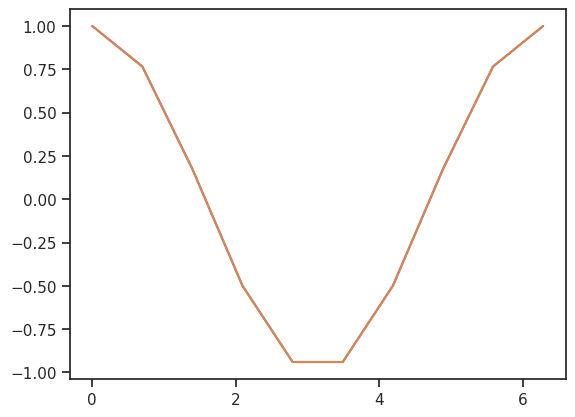

<string>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `hi

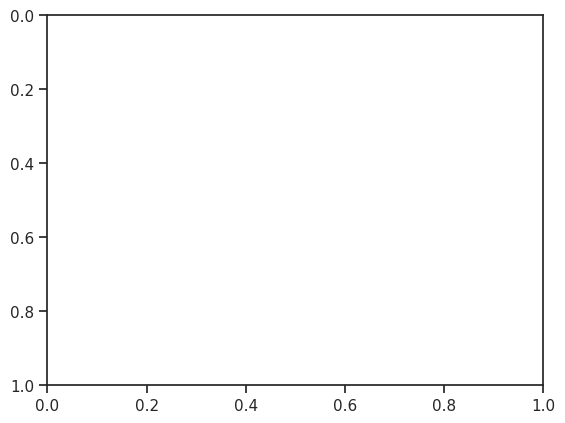

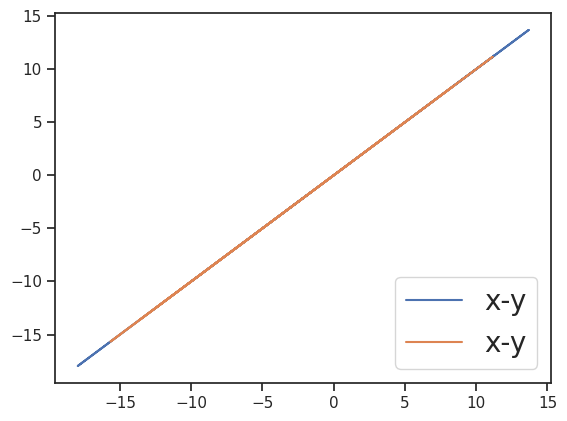

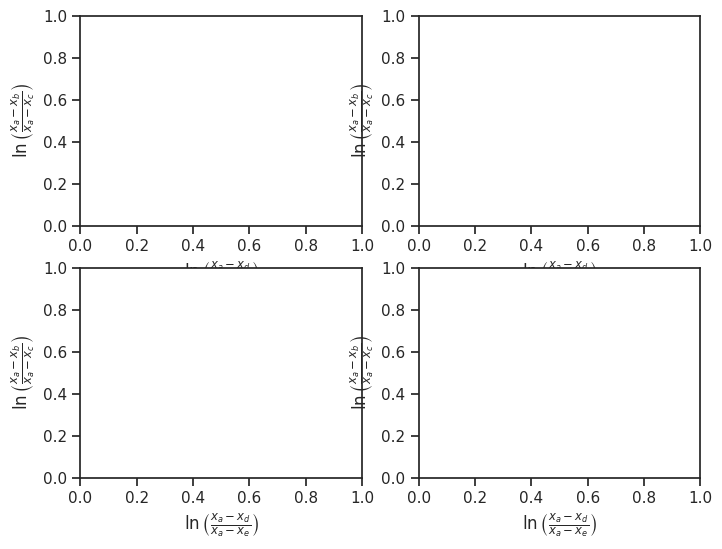

<Figure size 640x480 with 0 Axes>

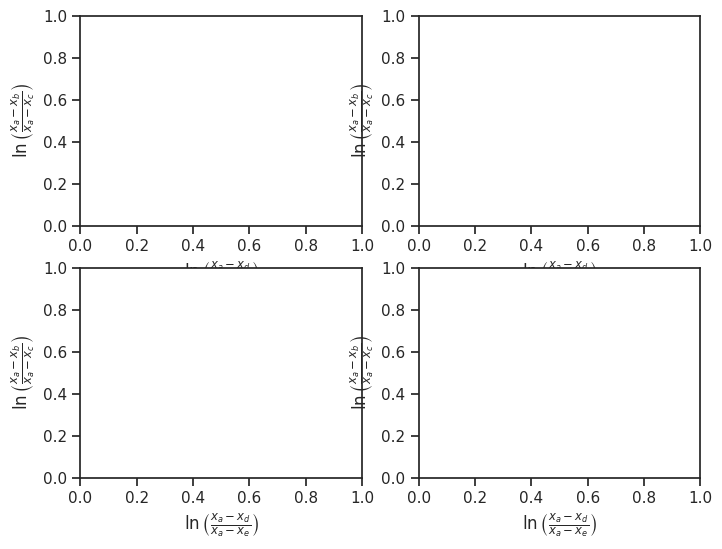

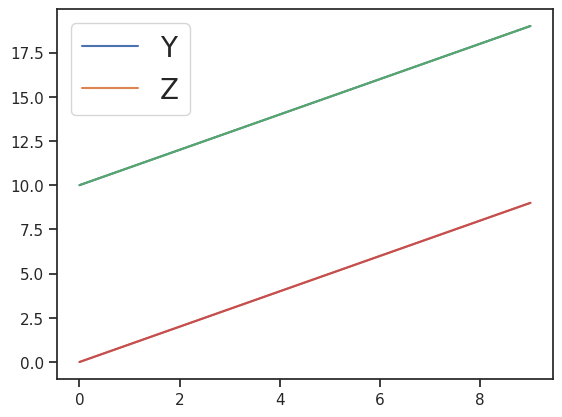

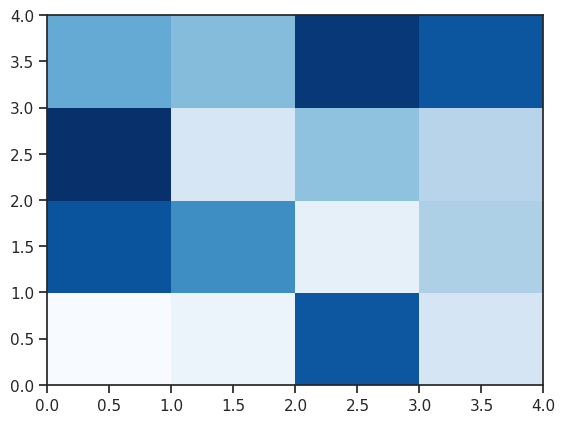

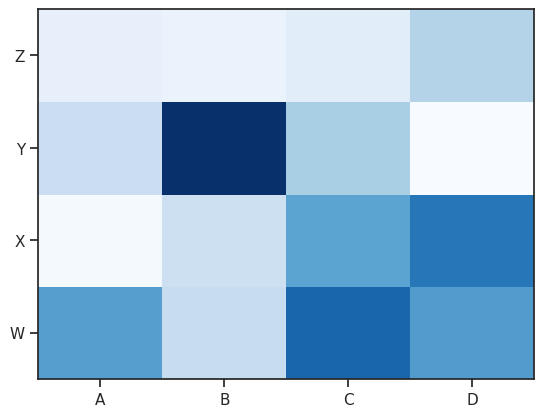

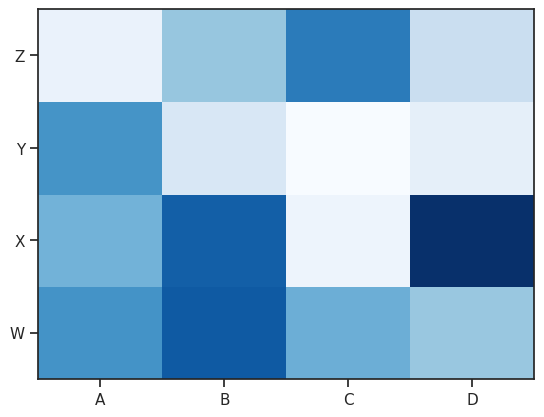

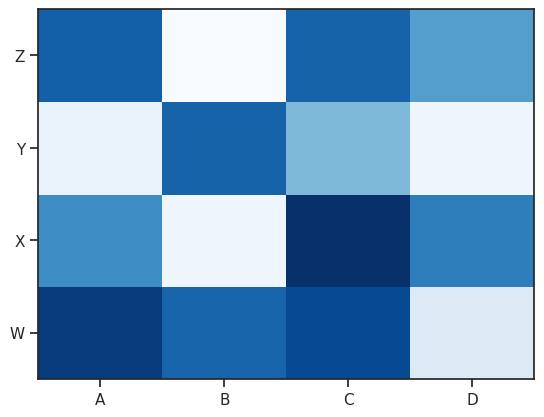

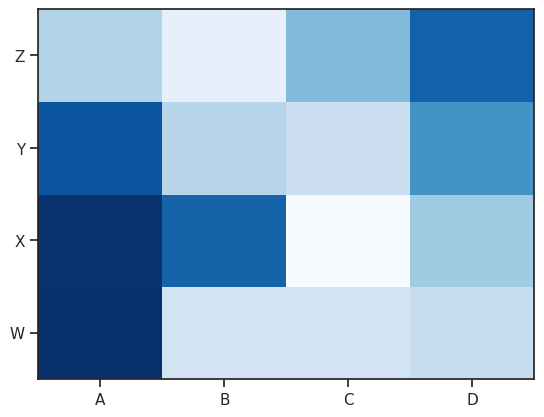

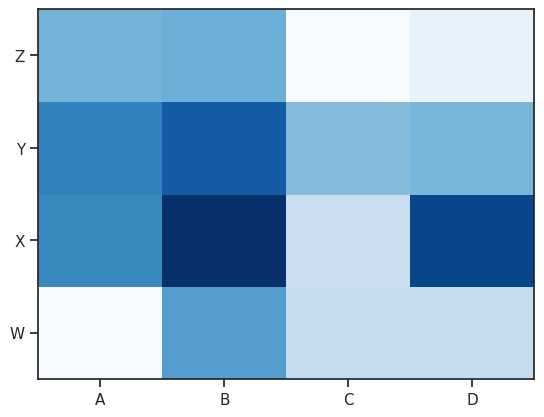

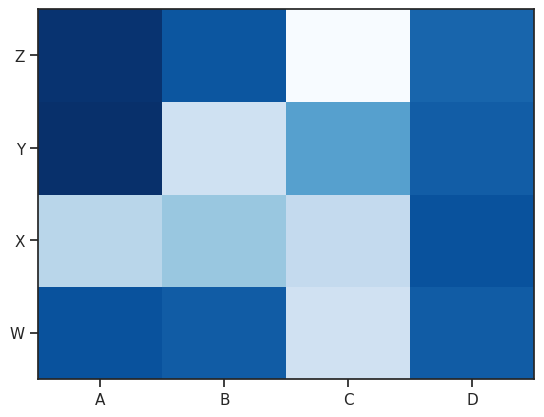

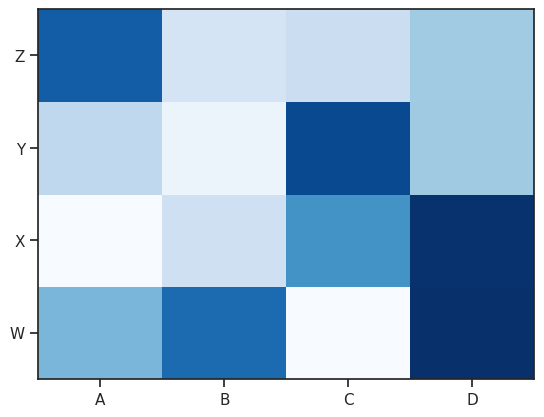

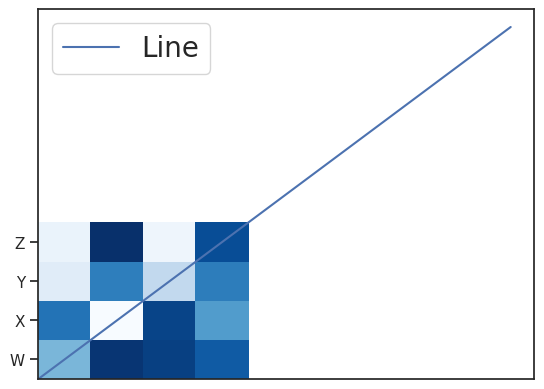

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1696: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f = plt.figure(figsize=(height, height))


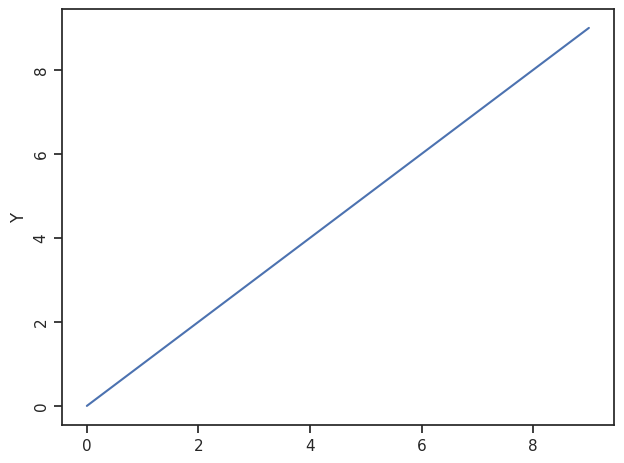

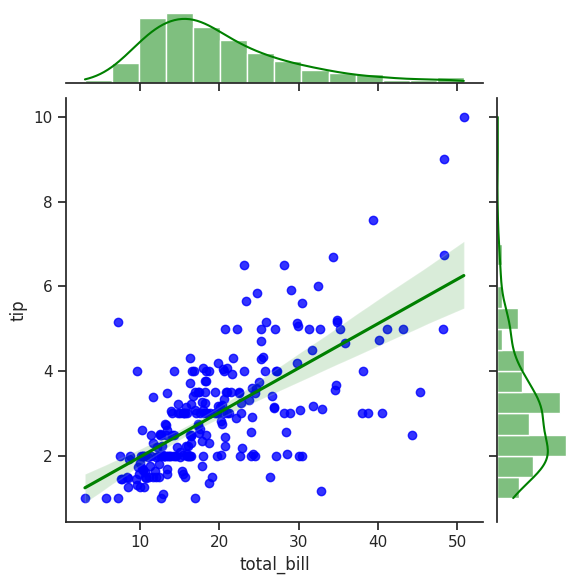

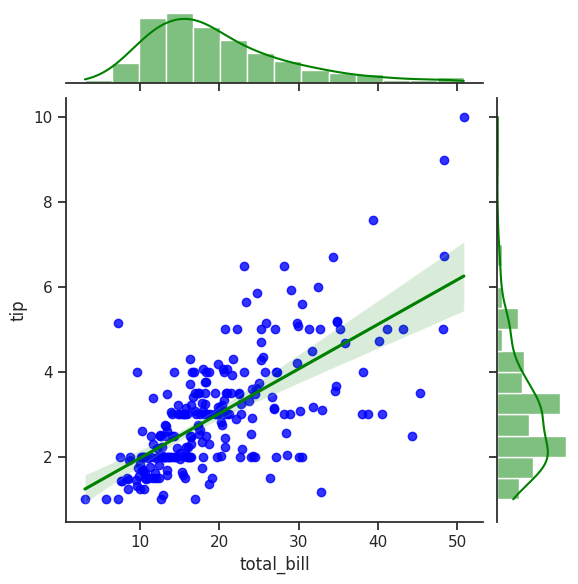

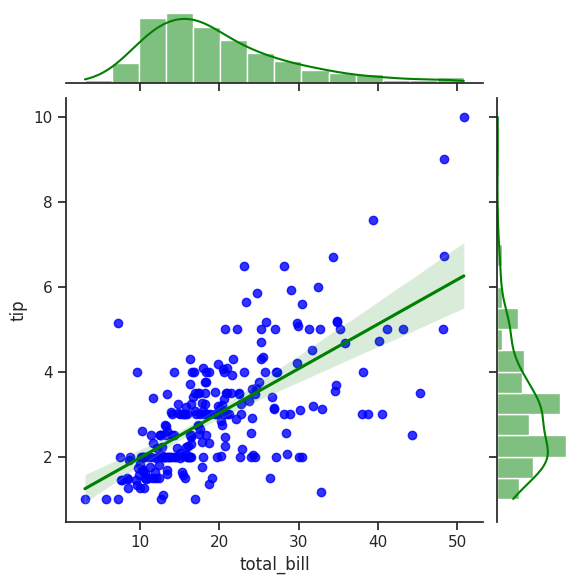

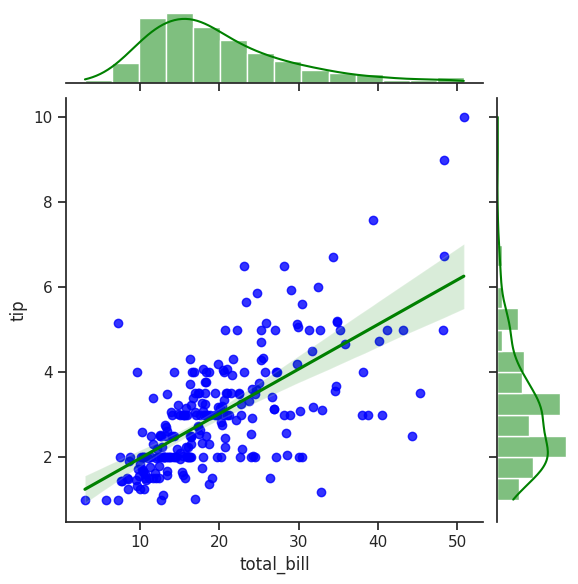

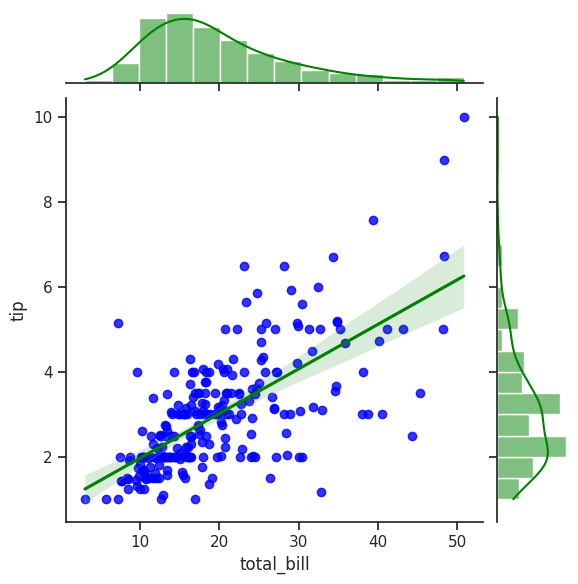

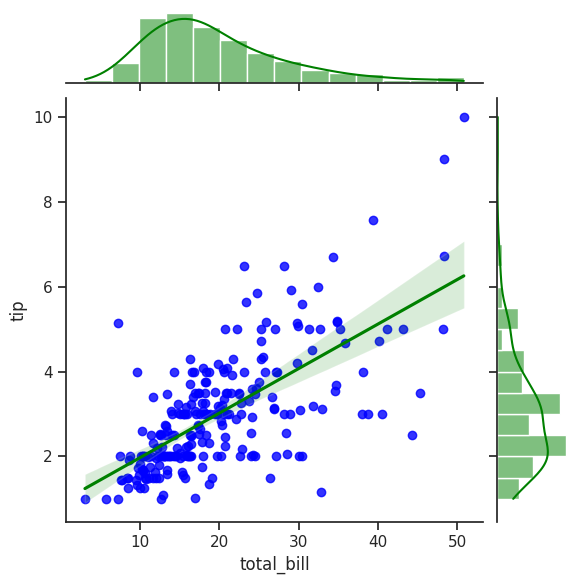

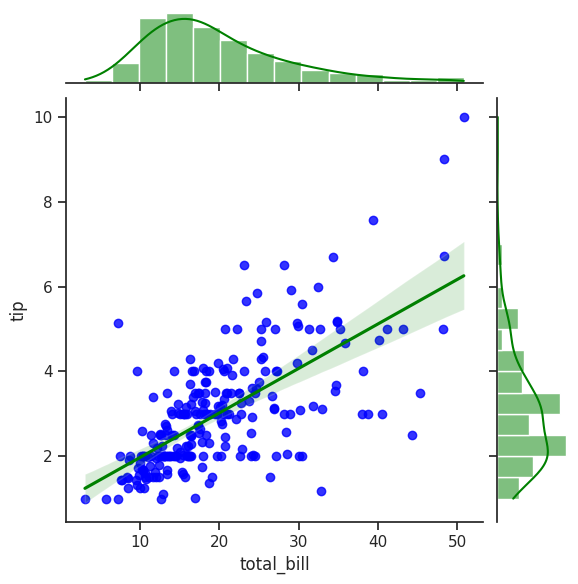

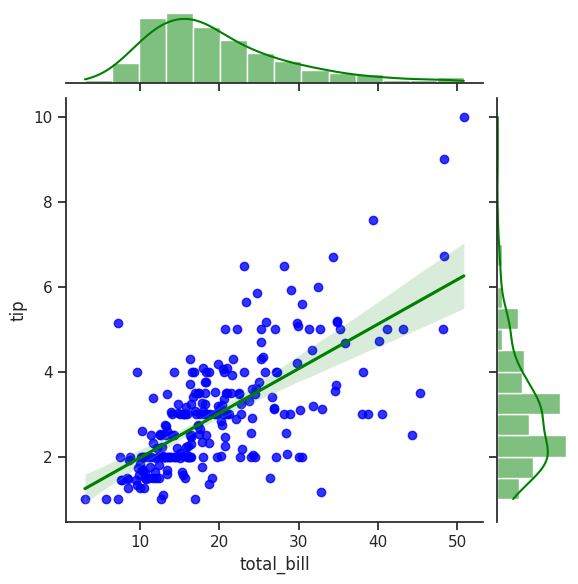

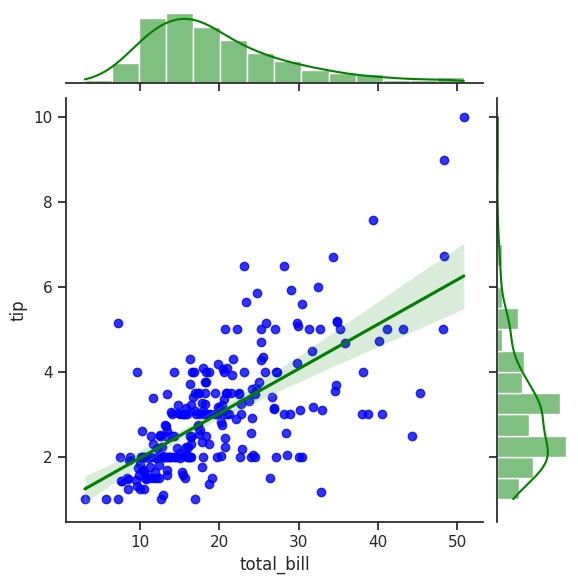

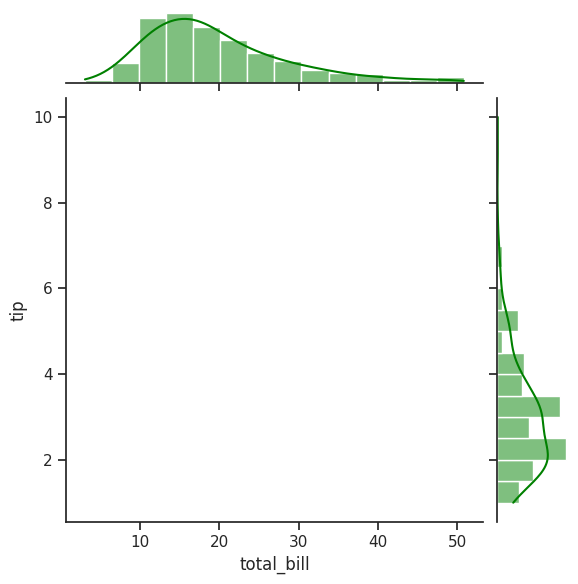

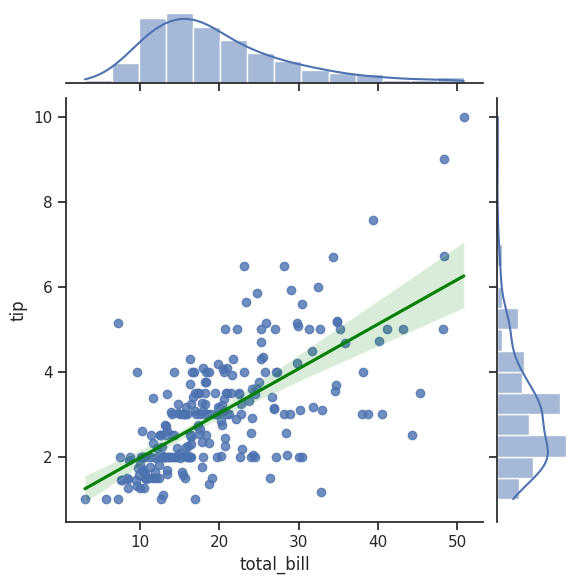

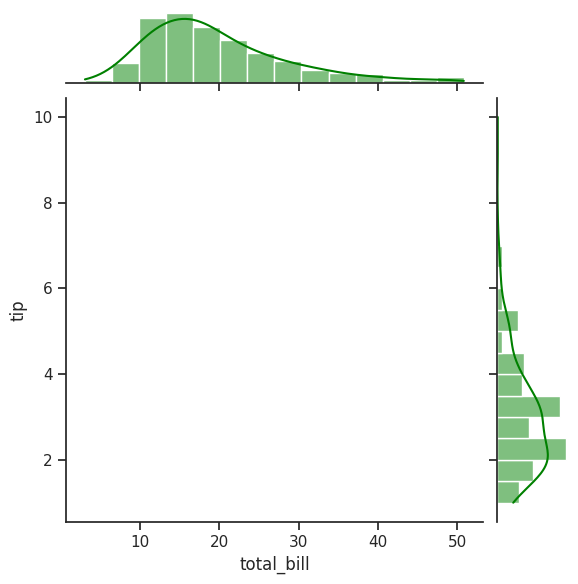

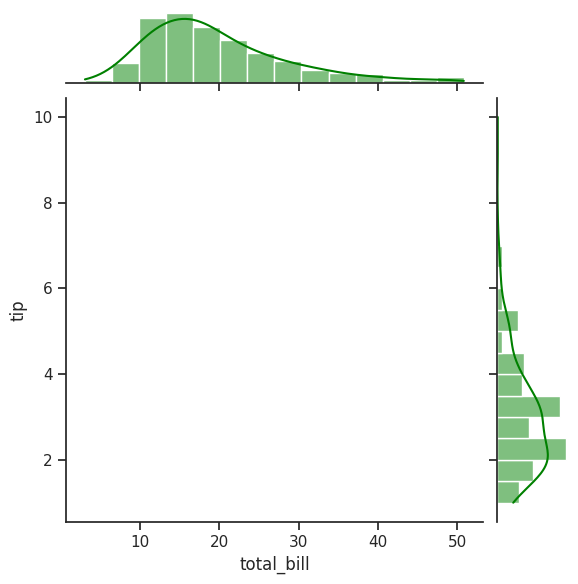

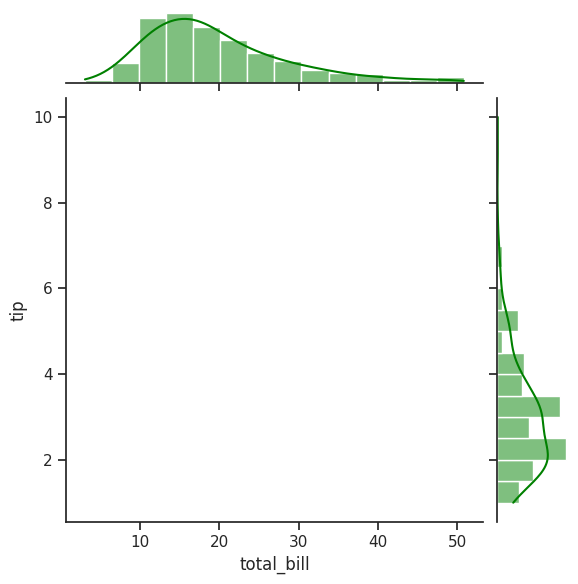

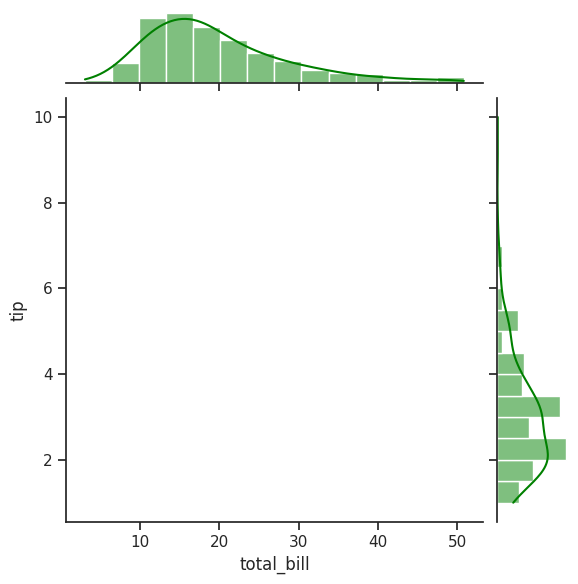

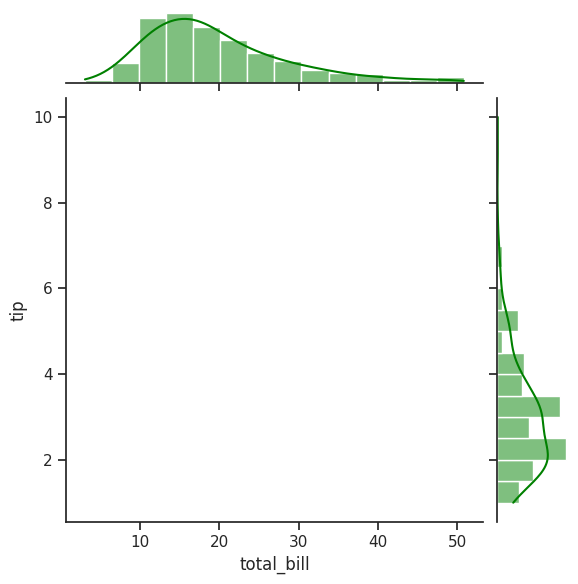

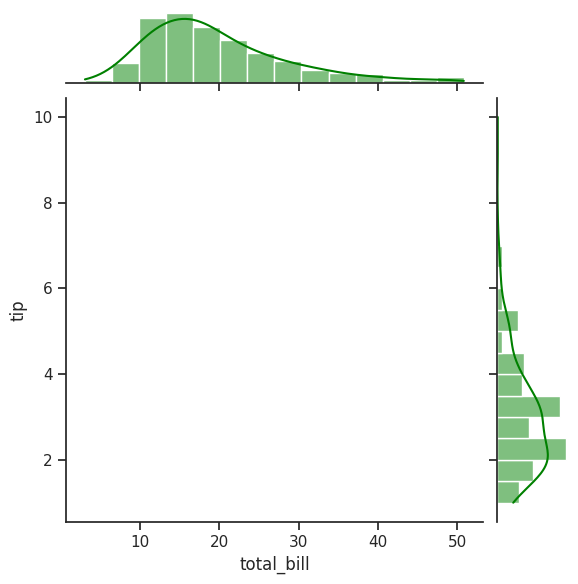

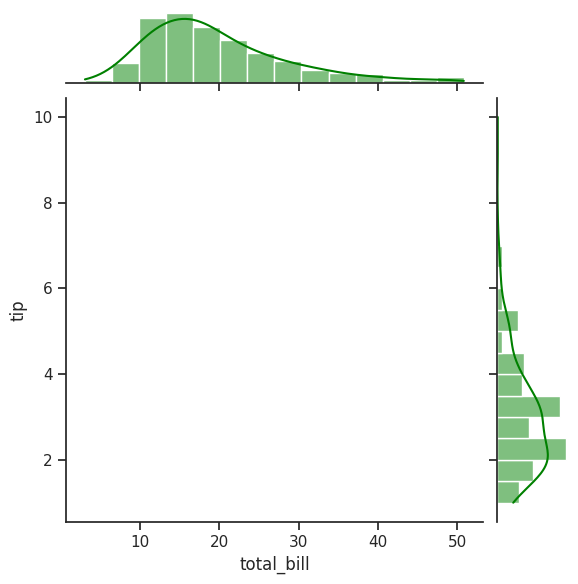

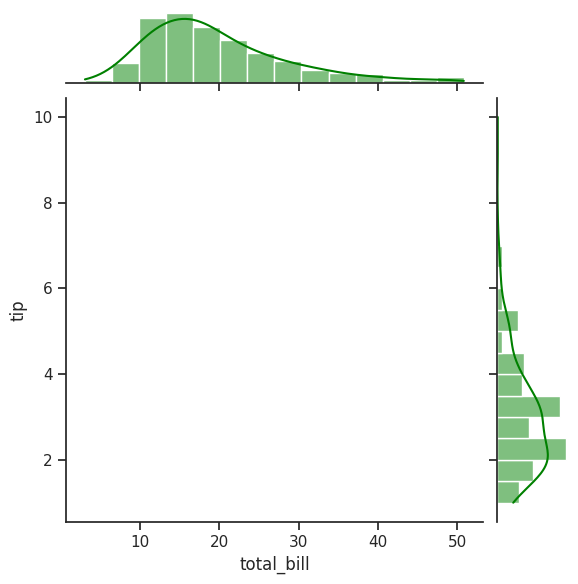

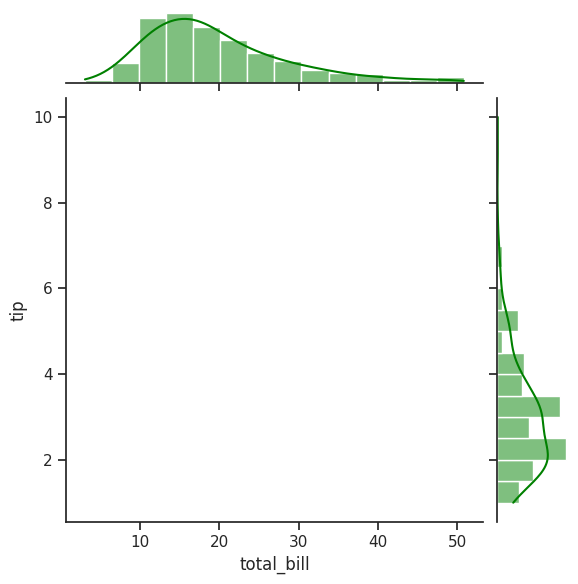

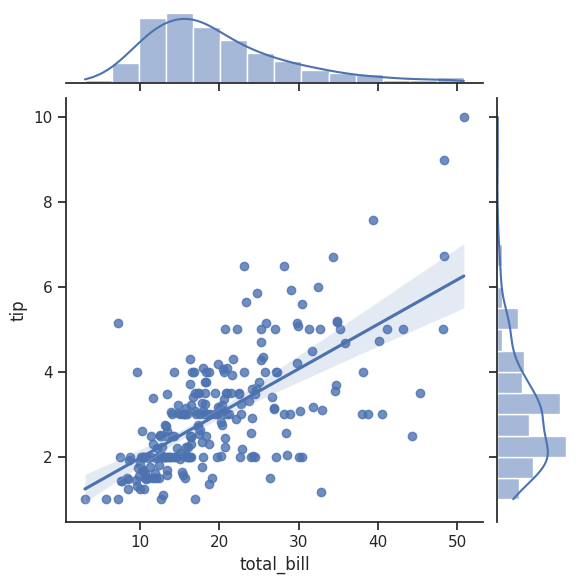

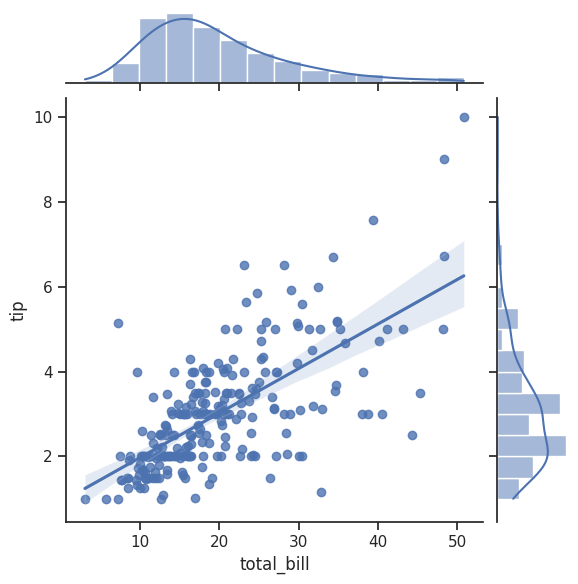

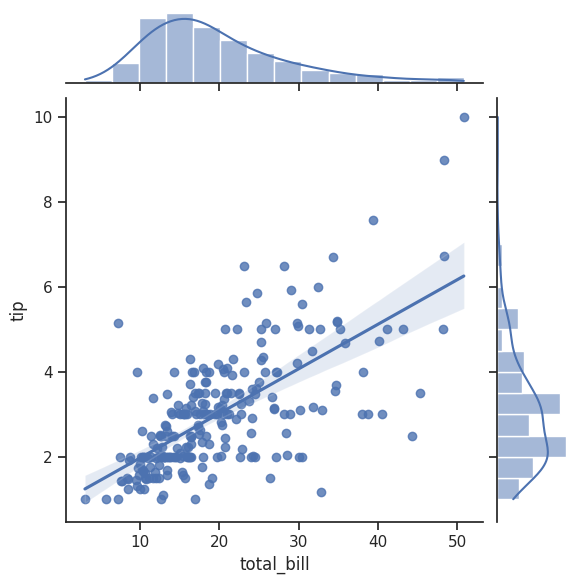

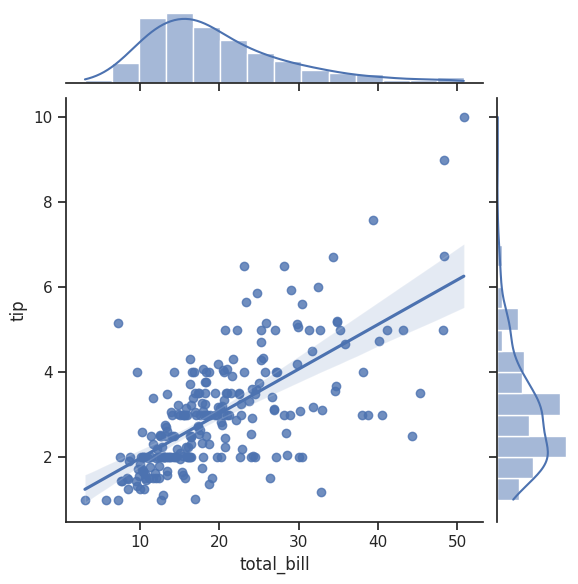

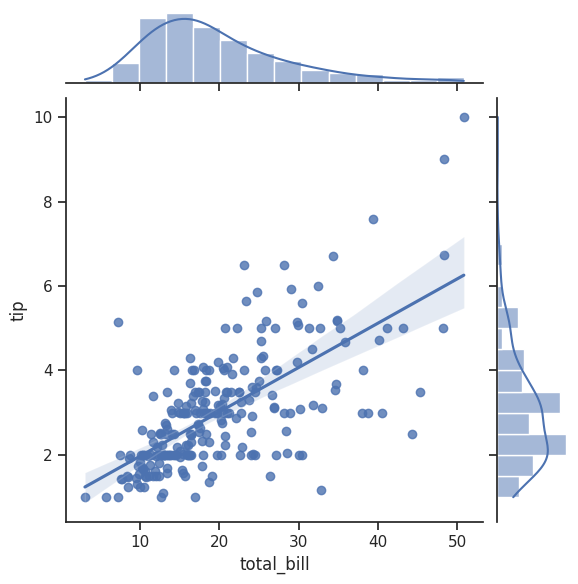

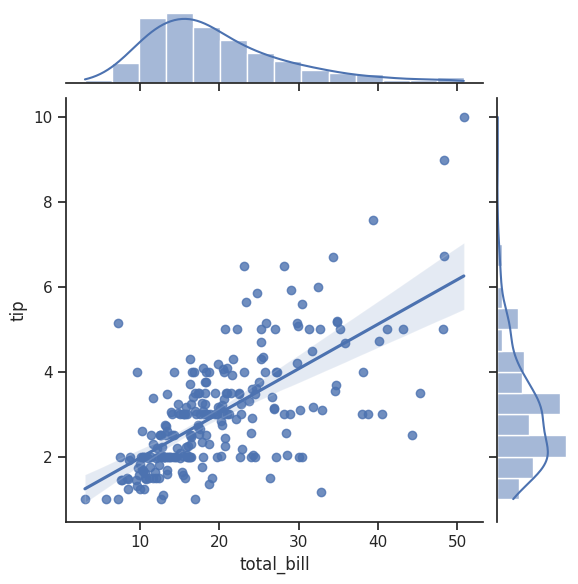

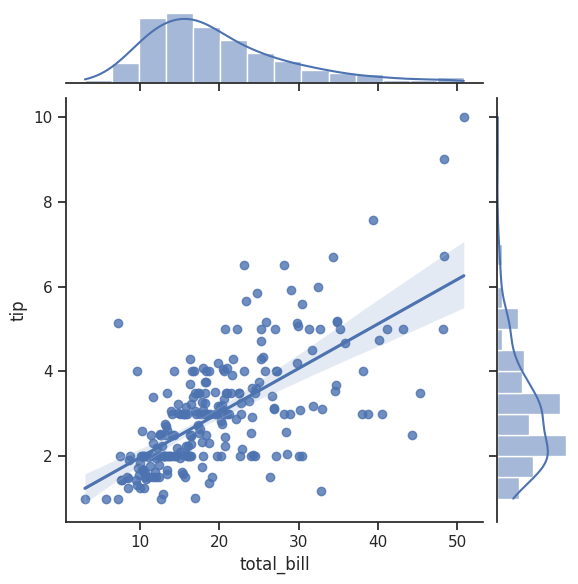

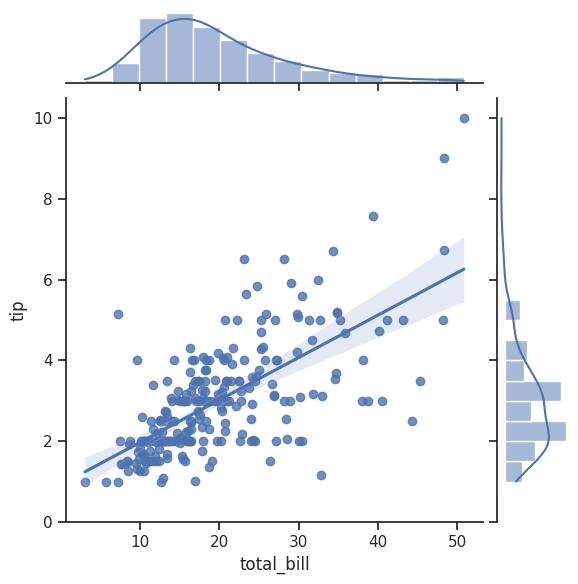

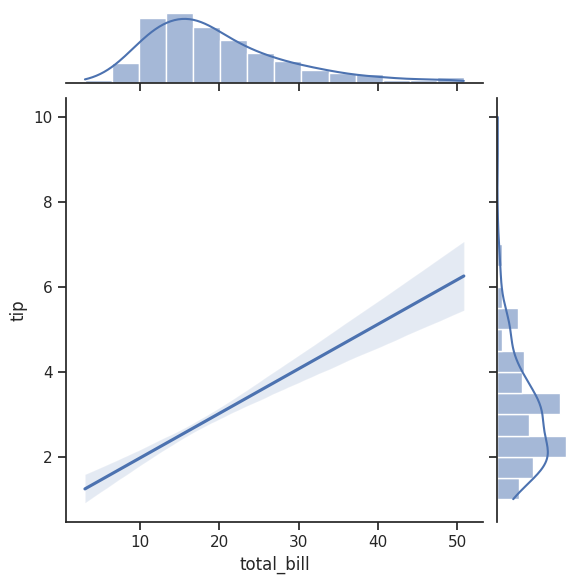

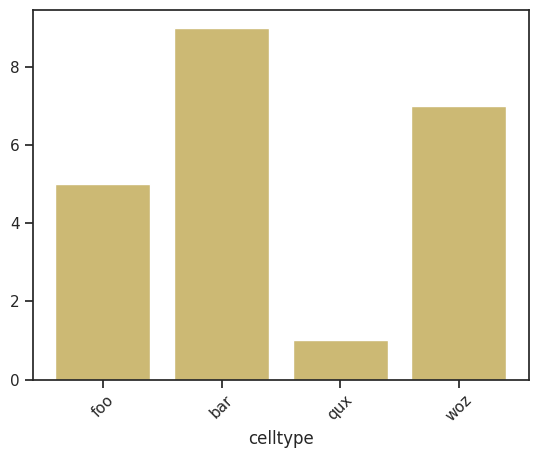

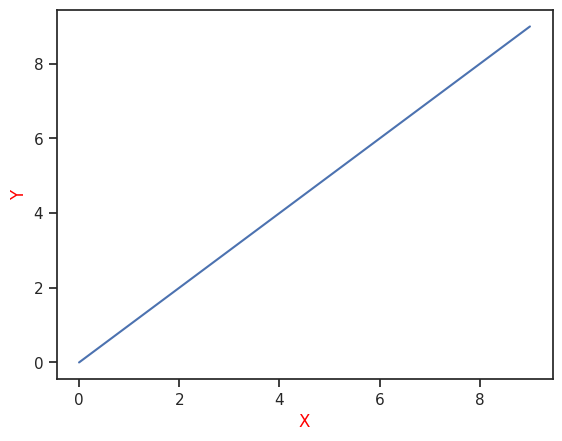

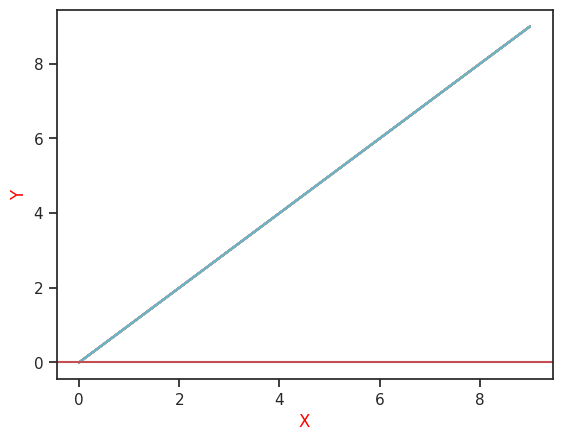

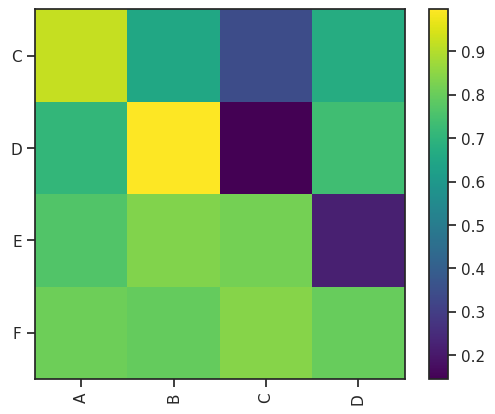

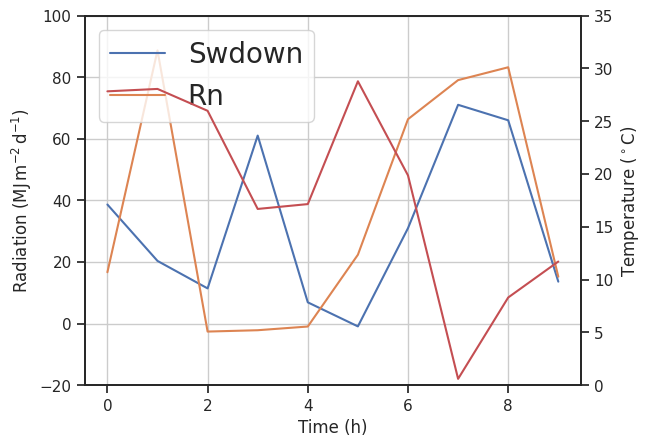

<Figure size 640x480 with 0 Axes>

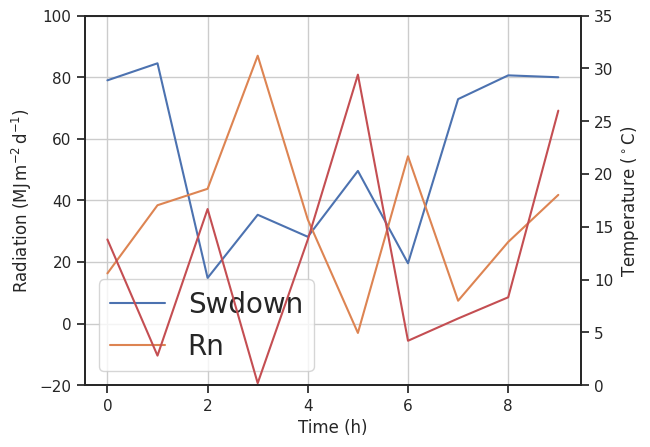

<Figure size 640x480 with 0 Axes>

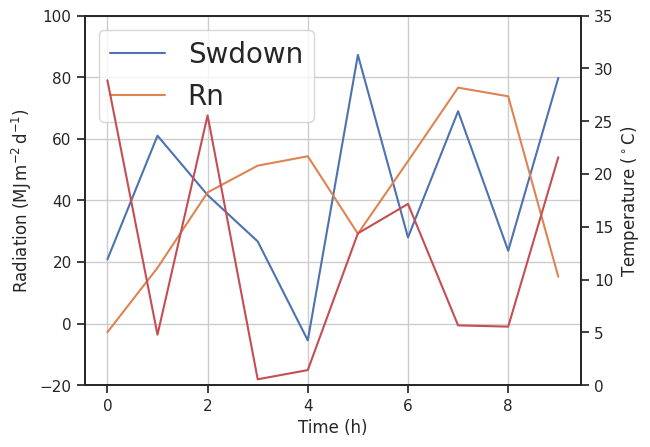

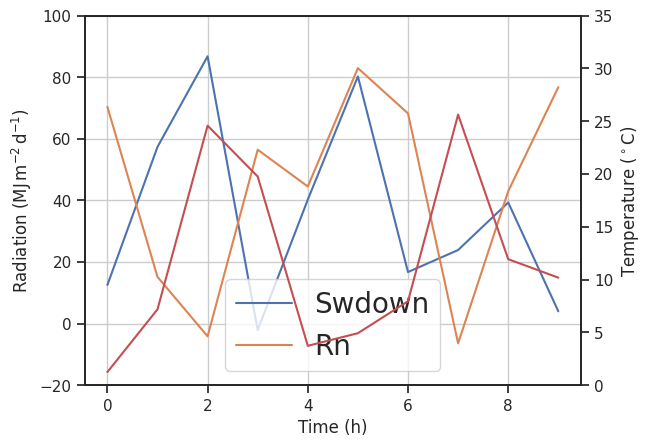

<Figure size 640x480 with 0 Axes>

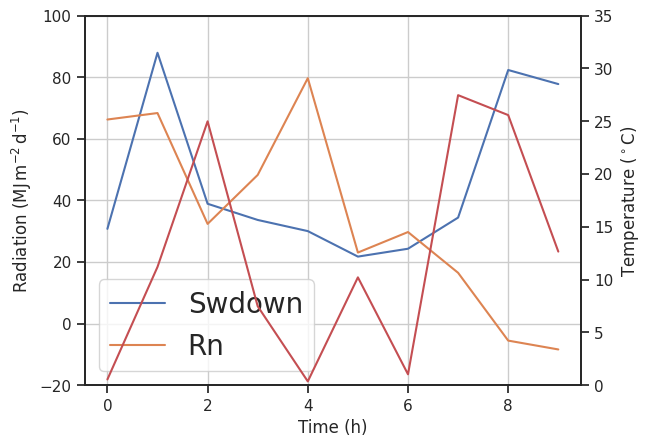

<Figure size 640x480 with 0 Axes>

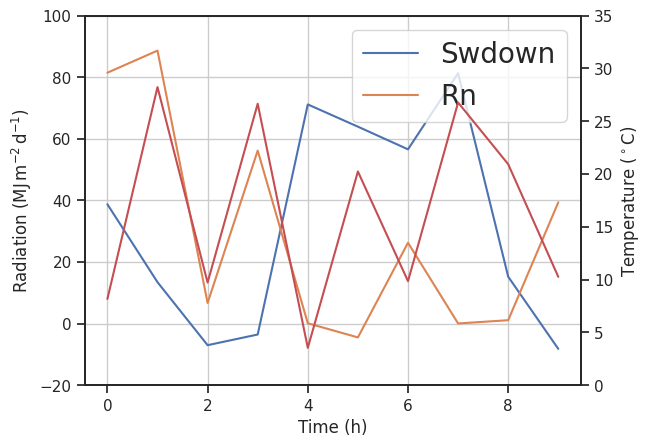

<Figure size 640x480 with 0 Axes>

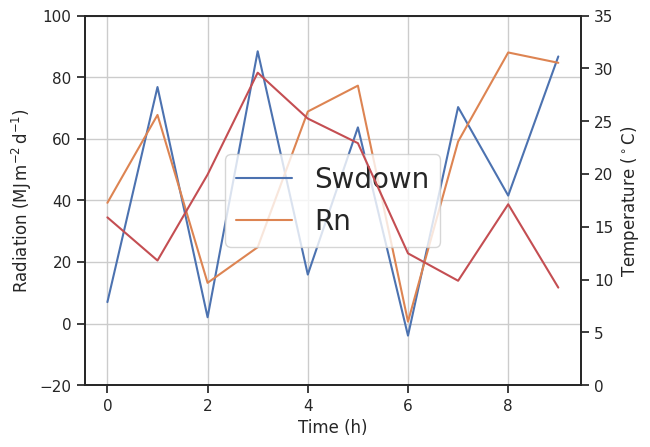

<Figure size 640x480 with 0 Axes>

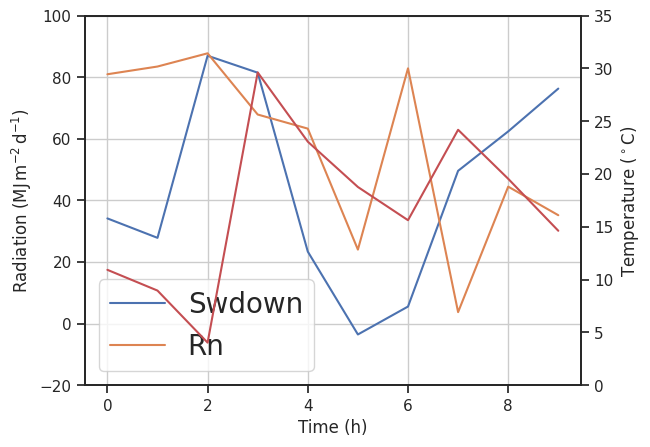

<Figure size 640x480 with 0 Axes>

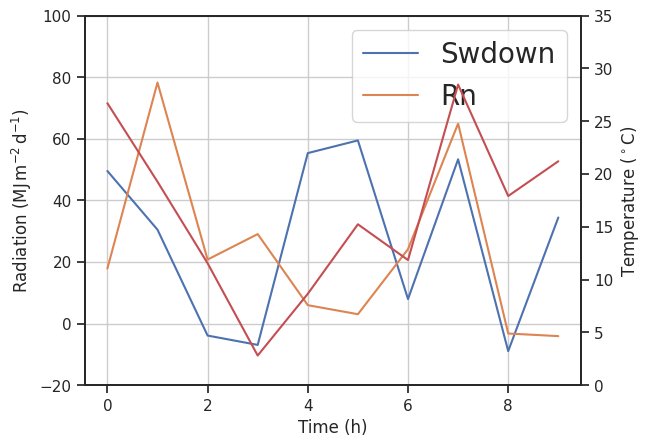

<Figure size 640x480 with 0 Axes>

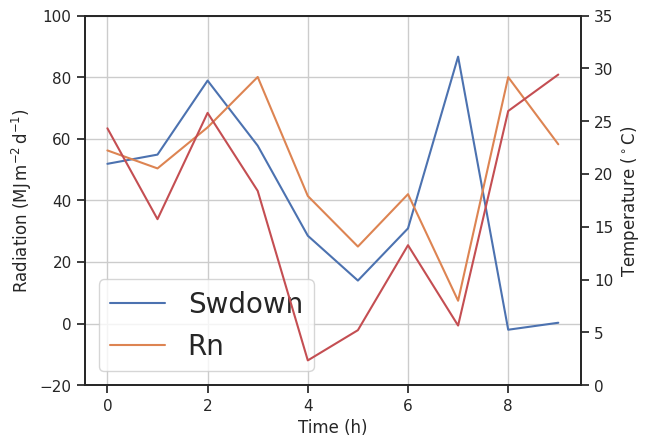

<Figure size 640x480 with 0 Axes>

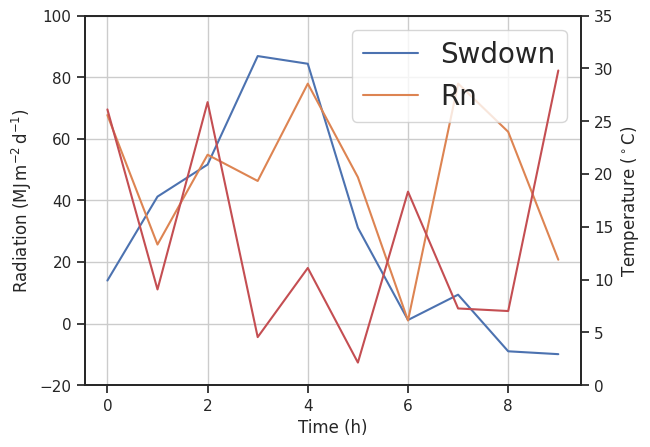

<Figure size 640x480 with 0 Axes>

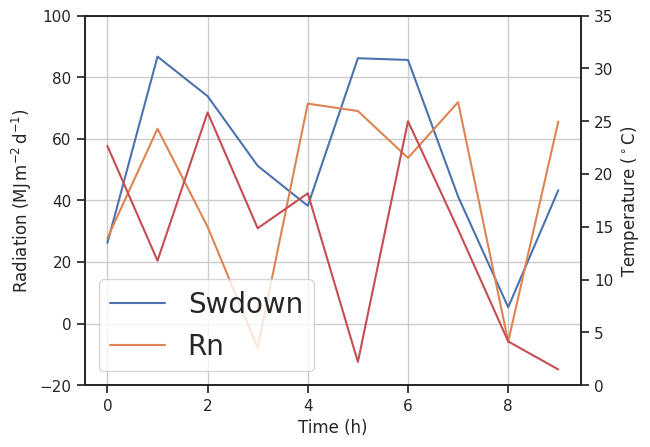

<Figure size 640x480 with 0 Axes>

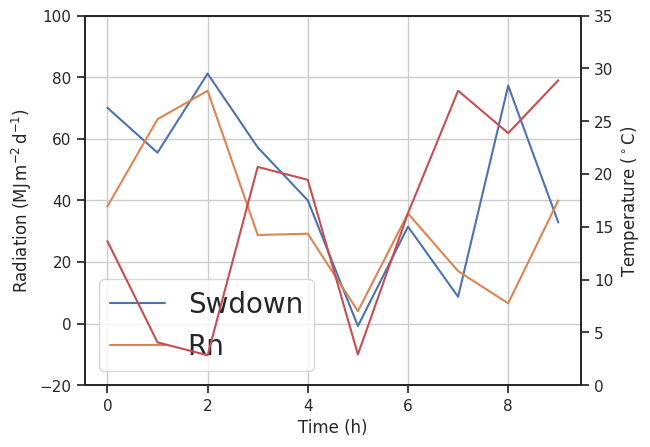

<Figure size 640x480 with 0 Axes>

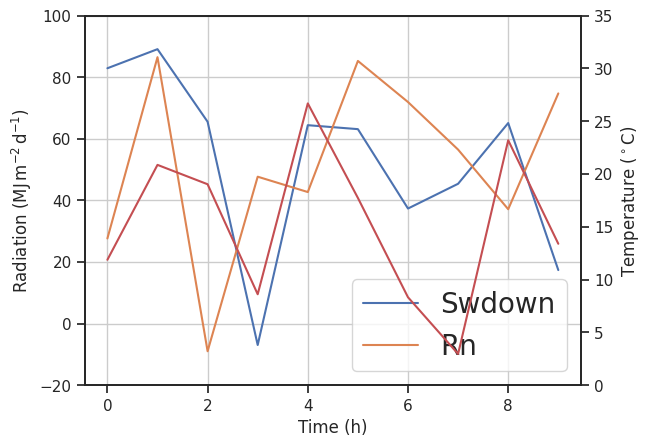

<Figure size 640x480 with 0 Axes>

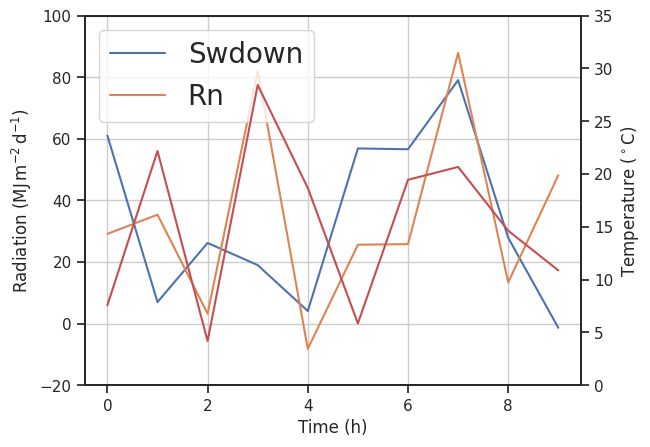

<Figure size 640x480 with 0 Axes>

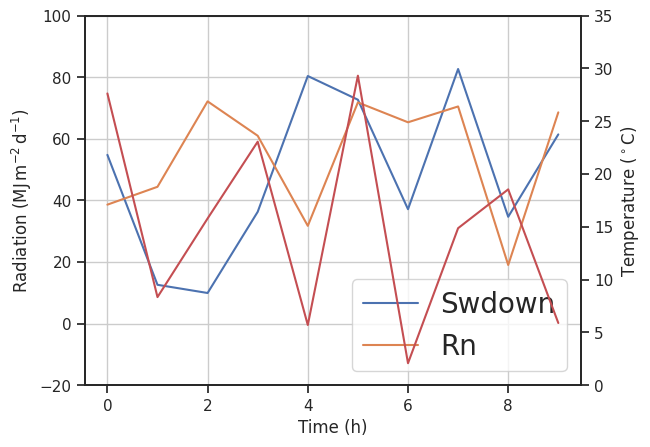

<Figure size 640x480 with 0 Axes>

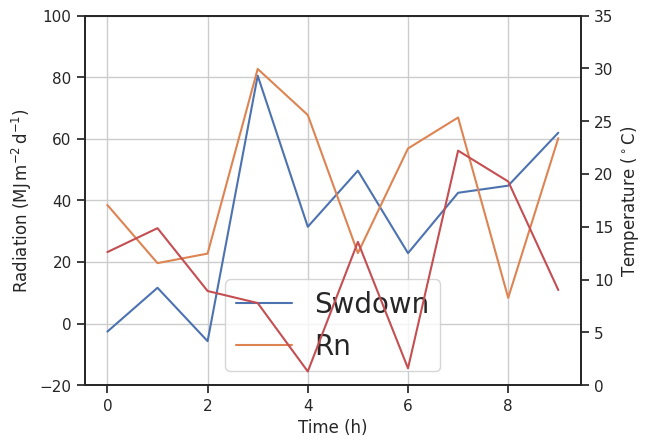

<Figure size 640x480 with 0 Axes>

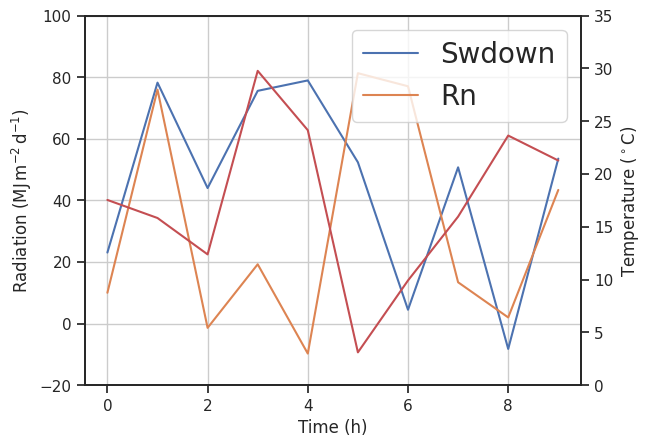

<Figure size 640x480 with 0 Axes>

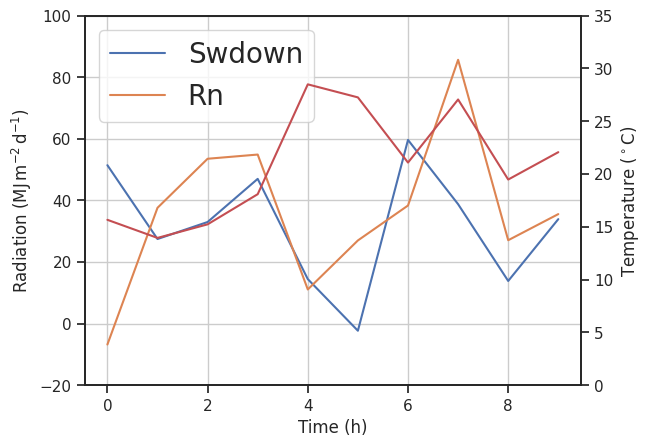

<Figure size 640x480 with 0 Axes>

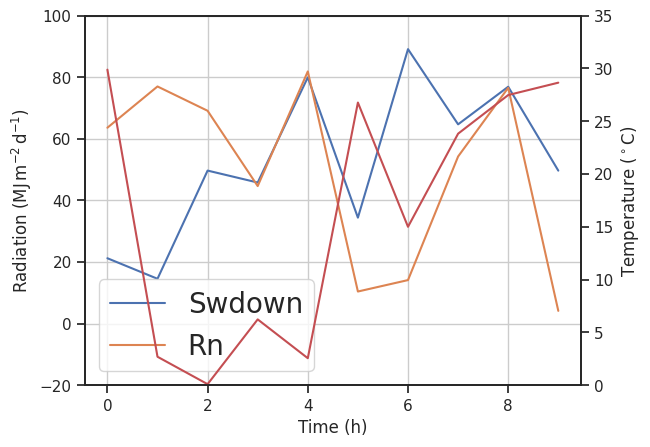

<Figure size 640x480 with 0 Axes>

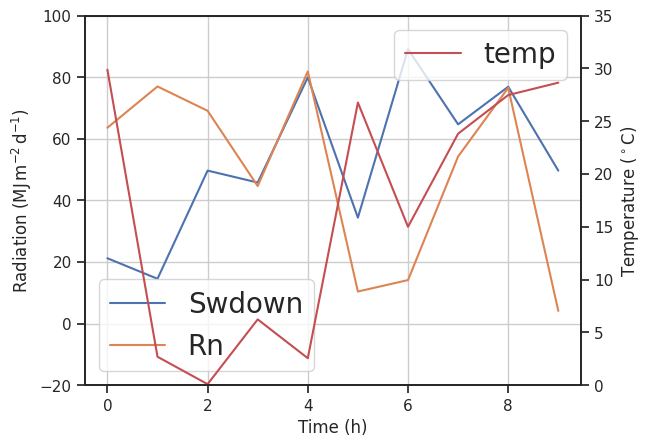

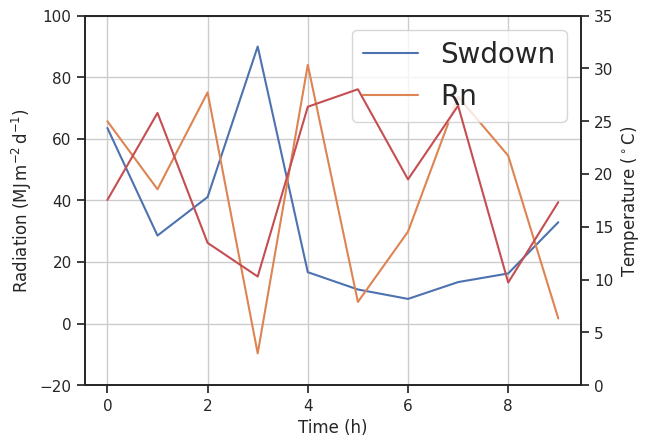

<string>:42: SyntaxWarning: invalid escape sequence '\m'
<string>:47: SyntaxWarning: invalid escape sequence '\m'
<string>:42: SyntaxWarning: invalid escape sequence '\m'
<string>:47: SyntaxWarning: invalid escape sequence '\m'


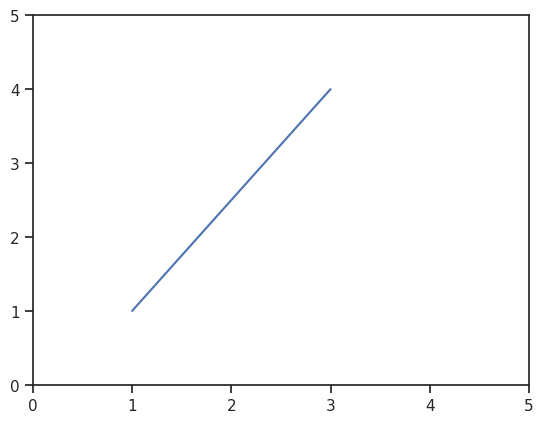

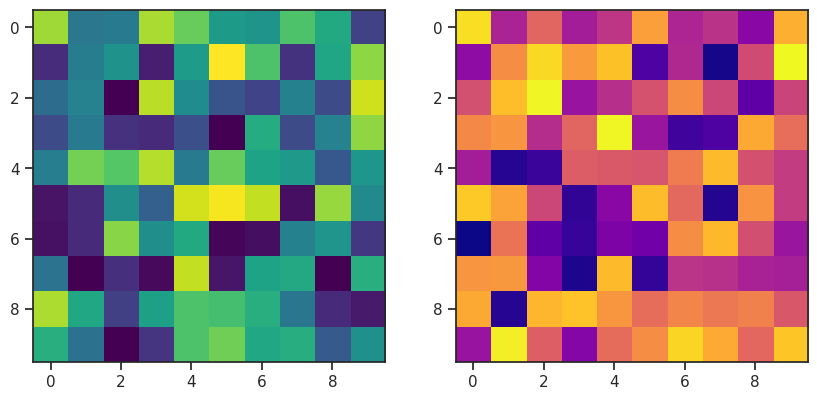

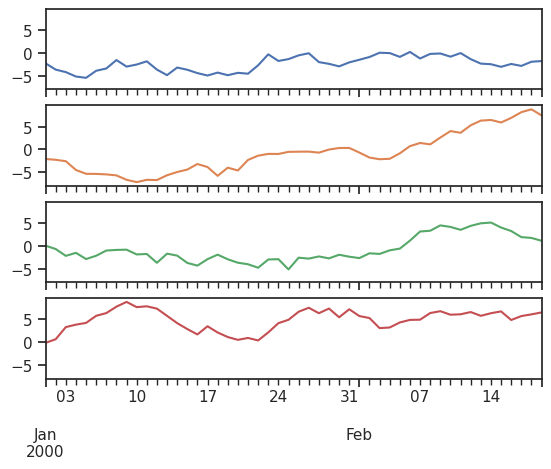

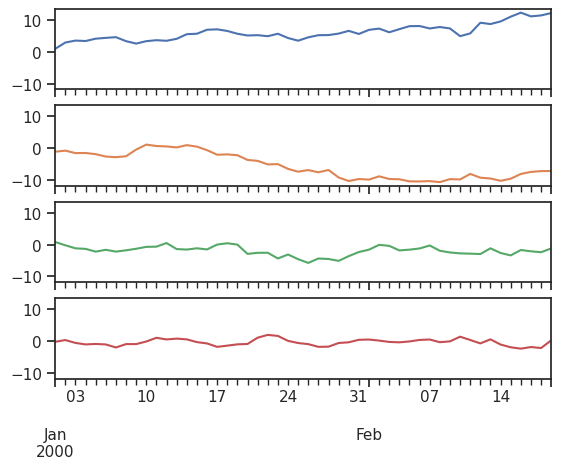

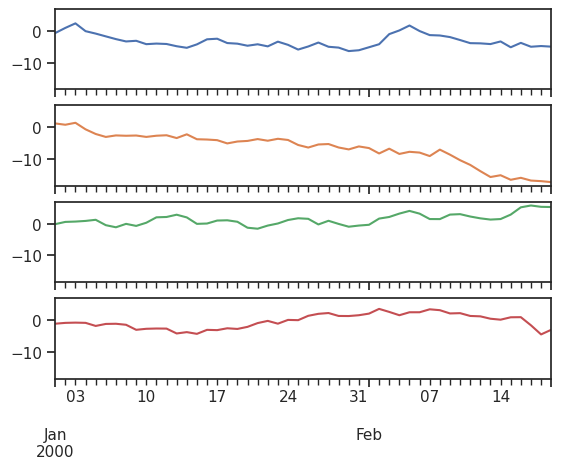

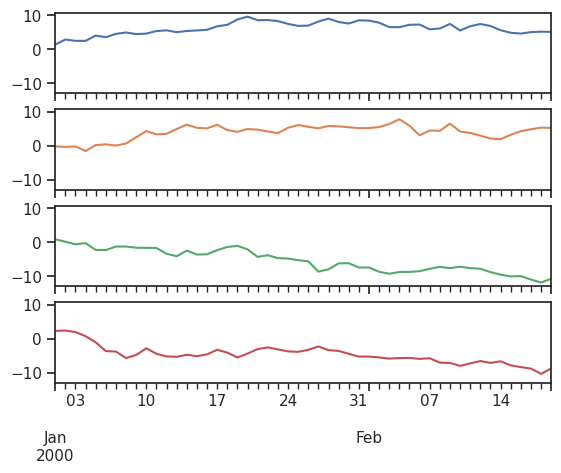

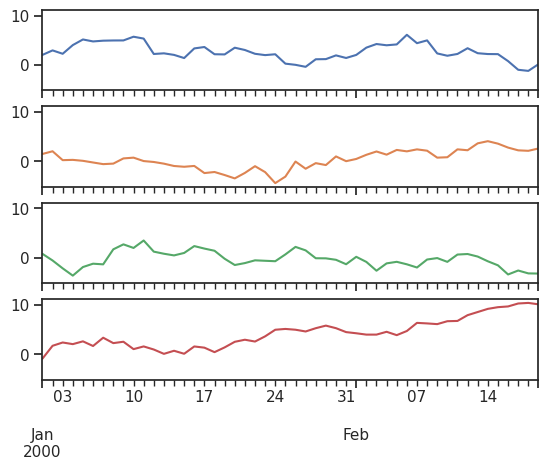

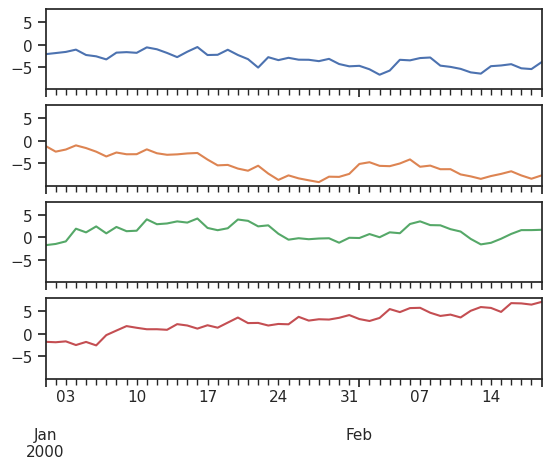

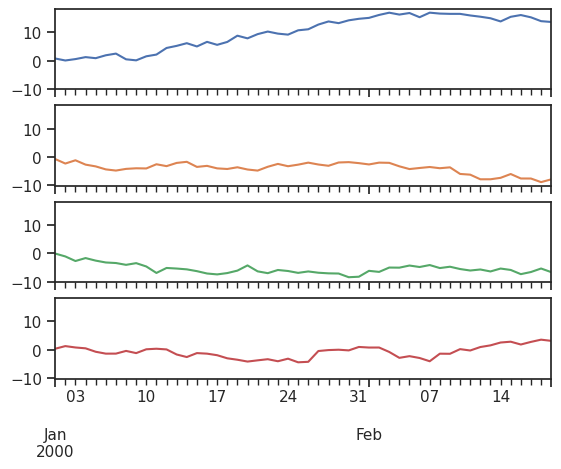

  Processed 600/1000 samples


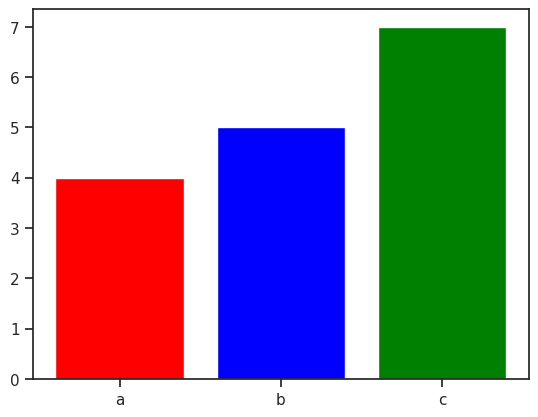

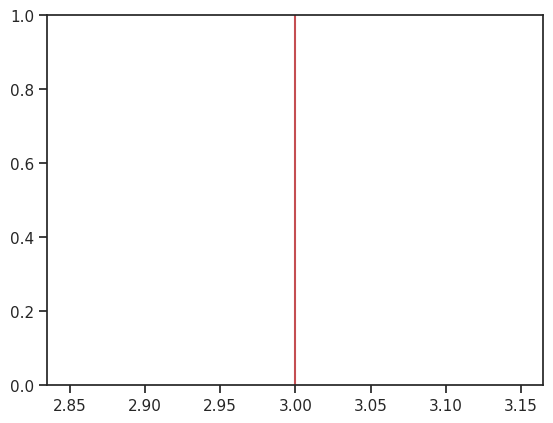

<string>:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `hi

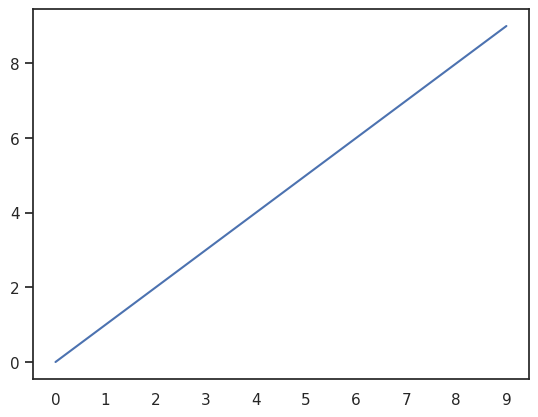

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

  Processed 700/1000 samples


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
<string>:21: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:17: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:17: OptimizeWarning: Covariance of the parameters could not be estimated
<string>:21: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
<string>:5: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
<string>:23: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod(

  Processed 800/1000 samples


<string>:23: SyntaxWarning: invalid escape sequence '\s'
<string>:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
<string>:23: SyntaxWarning: invalid escape sequence '\s'
<string>:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

  Processed 900/1000 samples


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
<string>:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
<string>:61: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.

  Processed 1000/1000 samples
Processing HumanEval: 164 samples
['()', '(())', '(()())']
(0, 1)
(10, 24)
1
5
3
4
[4, 2, 1, 2, 2, 1, 1, 1, 1, 4, 4]
0
3
3
one three five
[2, 5, 6]
[5, 3, 2, 3, 9, 123, 1]
[1, 2, 3]
[2, 6, 3, 4, 8, 9, 5]
0
2
3
[1, 2, 3]
[3, 6, 5, 4]
2
3
5
13
89
[2, 3, 4]
[6, 4, 6, 3, 4, 4, 10, 1, 124]
False
False
False
True
False
22
1000
111
4
8
14
  Processed 50/164 samples
All test cases passed!
['Hi', 'my', 'name', 'is', 'John']
['One', 'two', 'three', 'four', 'five', 'six']
14
12
14
12
0b11
-1
0b1111
0b11010
[1, 15, 33]
[]
['Eight', 'Five', 'Four', 'Three', 'Two', 'Two', 'One', 'One']
[]
['One']
[1, 2, 6, 24, 15]
(1, 2)
(4, 6)
0
3
3
0
3
3
True
True
True
True
YES
NO
('bcd', False)
('acdef', False)
('cdedc', True)
['the number of odd elements 4n the str4ng 4 of the 4nput.']
['the number of odd elements 1n the str1ng 1 of the 1nput.', 'the number of odd elements 8n the str8ng 8 of the 8nput.']
1
-6
[1, 2, 4, 3, 5]
[-4, -2, -6, -5, -3]
[0, 1, 2, 4, 3]
['little']
['Mary', '

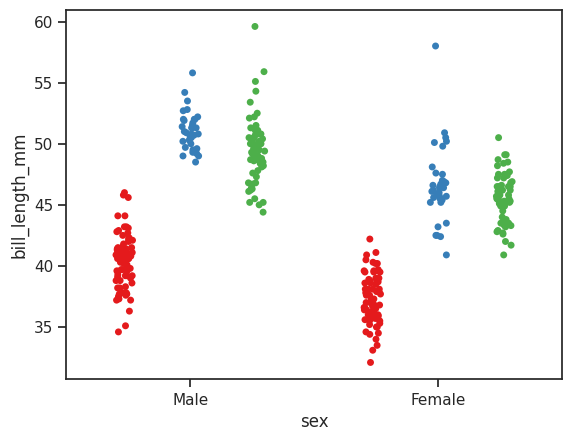

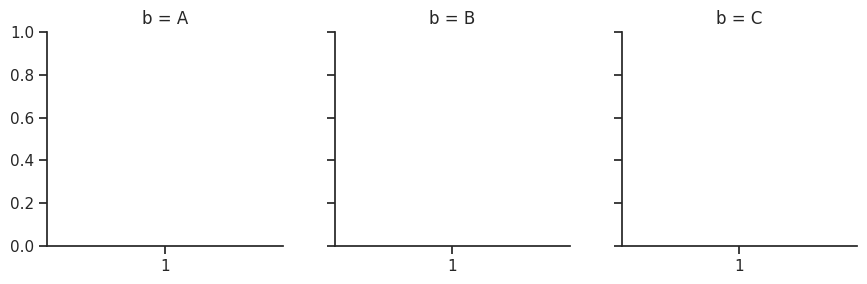

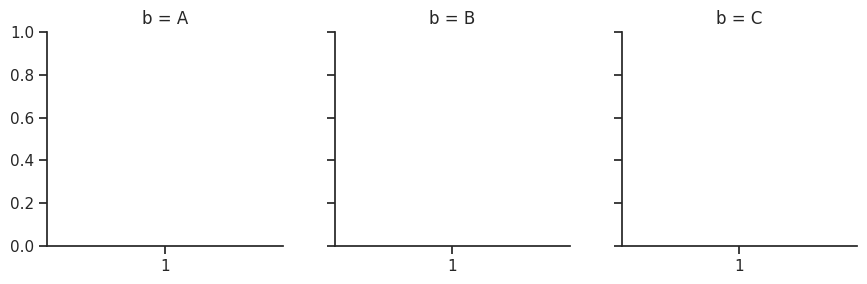

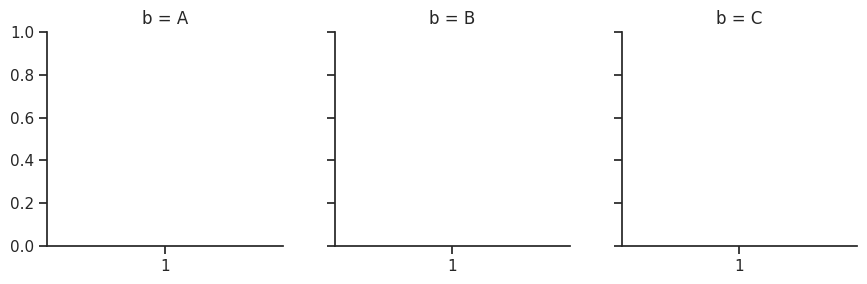

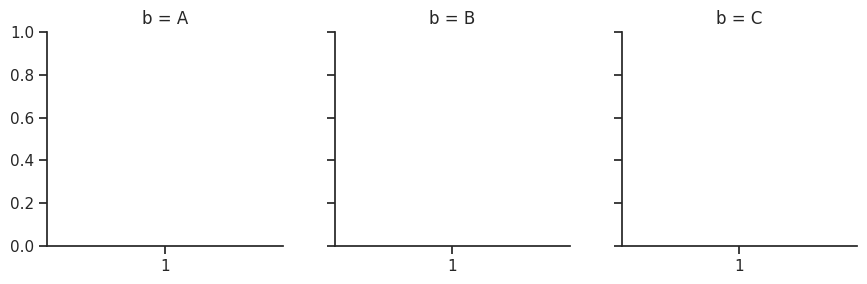

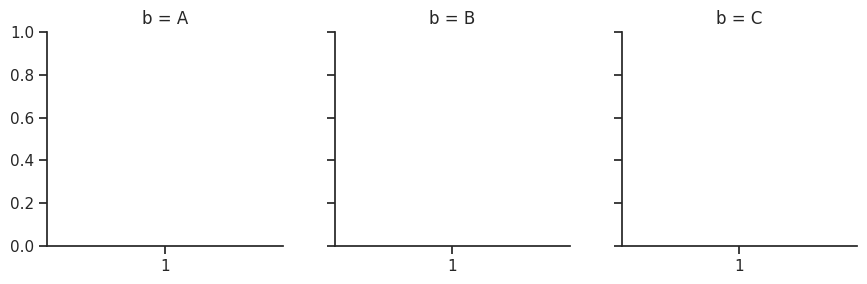

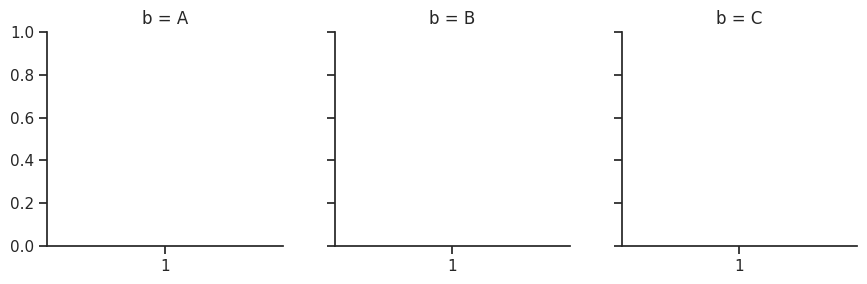

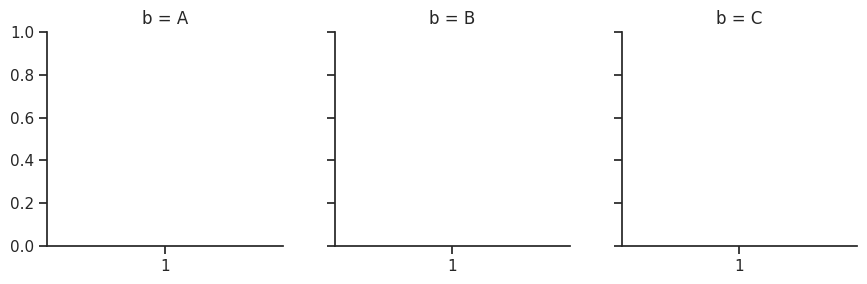

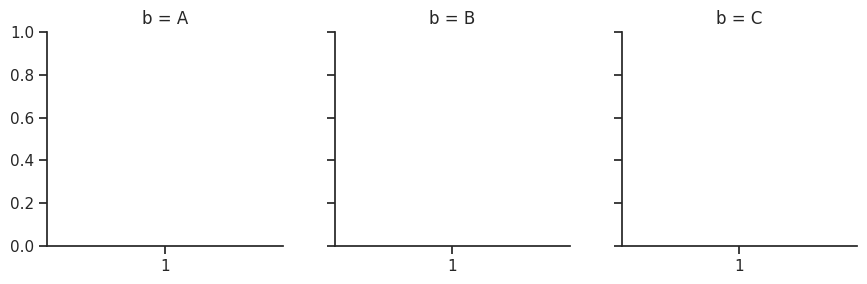

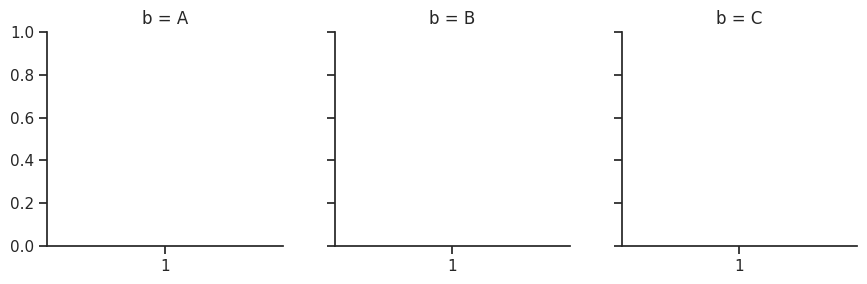

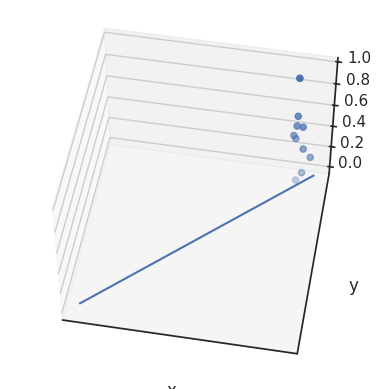

<Figure size 300x300 with 0 Axes>

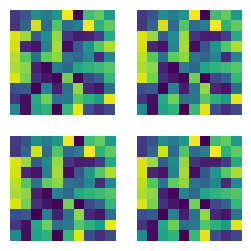

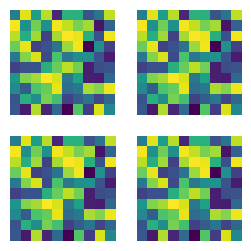

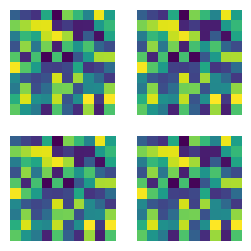

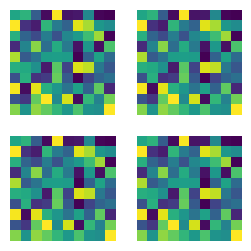

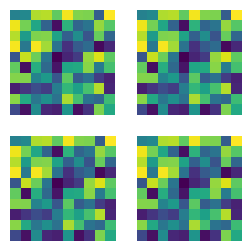

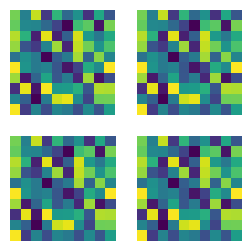

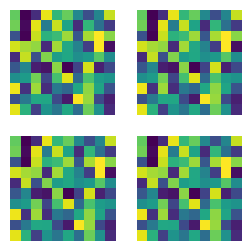

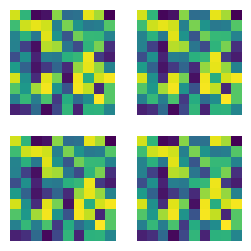

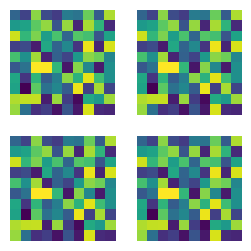

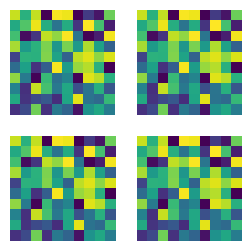

In [ ]:
results_df = run_dynamic_analysis(
    df_ds1k_code,
    df_humaneval_code,
    df_mbpp_code
)

## CROSS-CHECKING

In [ ]:
def build_original_status_map(df_ds1k, df_he, df_mbpp):
    status_map = {}

    # DS1000
    for _, row in df_ds1k.iterrows():
        status_map[("ds1000", row["task_id"])] = row.get("Status", "")

    # HumanEval
    for _, row in df_he.iterrows():
        status_map[("humaneval", row["task_id"])] = row.get("STATUS", "")

    # MBPP
    for _, row in df_mbpp.iterrows():
        status_map[("mbpp", row["task_id"])] = row.get("STATUS", "")

    return status_map

In [ ]:
def attach_original_status(
    dynamic_csv_path: str,
    df_ds1k,
    df_he,
    df_mbpp
):
    print("\n🔄 Attaching original STATUS column...")

    # Load dynamic results
    dyn_df = pd.read_csv(dynamic_csv_path)

    # Build lookup
    status_map = build_original_status_map(df_ds1k, df_he, df_mbpp)

    # Create new column
    original_status_list = []

    for _, row in dyn_df.iterrows():
        key = (row["dataset"], row["task_id"])
        original_status_list.append(status_map.get(key, ""))

    dyn_df.insert(
        dyn_df.columns.get_loc("status") + 1,
        "original_status",
        original_status_list
    )

    # Save updated file
    dyn_df.to_csv("dynamic_v2_.csv", index=False)

    print("✅ original_status column added and CSV updated.")
    return dyn_df

In [ ]:
updated_df = attach_original_status(
    "dynamic_execution_results.csv",
    df_ds1k_code,
    df_humaneval_code,
    df_mbpp_code
)


🔄 Attaching original STATUS column...
✅ original_status column added and CSV updated.


## ANALYSIS

In [ ]:
def compare_status_columns(csv_path: str):
    print("\n🔍 Comparing original_status vs dynamic status...")

    df = pd.read_csv(csv_path)

    # Normalize dynamic status
    df["status"] = df["status"].astype(str).str.lower().str.strip()

    # -----------------------------
    # Normalize original_status
    # -----------------------------
    def normalize_original_status(val):
        val = str(val).lower().strip()

        if val.startswith("pass"):
            return "passed"
        elif val.startswith("fail"):
            return "failed"
        else:
            return "unknown"

    df["original_status_binary"] = df["original_status"].apply(normalize_original_status)

    # -----------------------------
    # Match comparison
    # -----------------------------
    df["status_match"] = df["status"] == df["original_status_binary"]

    # -----------------------------
    # Classification
    # -----------------------------
    def classify(row):
        dyn = row["status"]
        orig = row["original_status_binary"]

        if dyn == "passed" and orig == "passed":
            return "True Positive (Correct Pass)"
        elif dyn == "failed" and orig == "failed":
            return "True Negative (Correct Fail)"
        elif dyn == "failed" and orig == "passed":
            return "Hallucination (False Pass)"
        elif dyn == "passed" and orig == "failed":
            return "Recovery / False Fail"
        else:
            return "Unknown"

    df["comparison_label"] = df.apply(classify, axis=1)

    # Save CSV
    df.to_csv(csv_path, index=False)

    # -----------------------------
    # Print Summary
    # -----------------------------
    total = len(df)
    match_count = df["status_match"].sum()
    mismatch_count = total - match_count

    print("\n==============================")
    print("📊 Comparison Summary")
    print("==============================")
    print(f"Total Samples         : {total}")
    print(f"Status Match          : {match_count} ({match_count/total:.2%})")
    print(f"Status Mismatch       : {mismatch_count} ({mismatch_count/total:.2%})")

    print("\n📊 Detailed Breakdown:")
    breakdown = df["comparison_label"].value_counts()

    for label, count in breakdown.items():
        print(f"{label:35} : {count} ({count/total:.2%})")

    print("==============================\n")

    return df

In [ ]:
updated_df = compare_status_columns("dynamic_v2_.csv")


🔍 Comparing original_status vs dynamic status...

📊 Comparison Summary
Total Samples         : 1491
Status Match          : 312 (20.93%)
Status Mismatch       : 1179 (79.07%)

📊 Detailed Breakdown:
Correct                             : 1037 (69.55%)
wrong                               : 454 (30.45%)

